In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/My Drive/single_cell_isoform_smoothing/

/content/drive/My Drive/single_cell_isoform_smoothing


In [3]:
!pip install --upgrade networkx
!pip install scanpy
!pip install SCORED

In [4]:
import sklearn
import scipy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm.notebook import tqdm
import networkx as nx
from scipy.stats import spearmanr
import numpy as np
import torch
import scanpy as sc
import pandas as pd
from scipy.sparse import csr_matrix
from anndata import AnnData
from typing import Optional, List
from scored import SCORED


In [5]:
if torch.cuda.is_available():
  dev = "cuda:0"
else:
  dev = "cpu"
device = torch.device(dev)

if torch.cuda.is_available():
   print ("Cuda is available")
   device_id = torch.cuda.current_device()
   gpu_properties = torch.cuda.get_device_properties(device_id)
   print("Found %d GPUs available. Using GPU %d (%s) of compute capability %d.%d with "
          "%.1fGb total memory.\n" %
          (torch.cuda.device_count(),
          device_id,
          gpu_properties.name,
          gpu_properties.major,
          gpu_properties.minor,
          gpu_properties.total_memory / 1e9))
else:
   print ("Cuda is not available")

Cuda is available
Found 1 GPUs available. Using GPU 0 (NVIDIA A100-SXM4-80GB) of compute capability 8.0 with 85.2Gb total memory.



# Load data and preprocessing

In [6]:
adata_transcript_1 = sc.read_h5ad('./20230222_new/transcript_raw_8fc.h5ad')

adata_gene_1 = sc.read_h5ad('./20230222_new/gene_raw_8fc.h5ad')


sc.pp.filter_genes(adata_transcript_1, min_cells=3)

# Use the refined transcript matrix for downstream analysis

In [7]:
new_matrix_1 = SCORED(
    adata_tr   = adata_transcript_1,
    adata_g = adata_gene_1,
    rwr_alpha = 0.3
)



/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/local/lib/python3.12/dist-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 3136 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


In [8]:
adata_transcript_list = [adata_transcript_1]
new_matrix_list = [new_matrix_1]

adata_transcript_raw_list = []
adata_transcript_new_list = []

for i in range(len(adata_transcript_list)):
    adata_transcript = adata_transcript_list[i]
    new_matrix = new_matrix_list[i]

    adata_transcript.var["mt"] = adata_transcript.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(
        adata_transcript, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
    )
    sc.pp.normalize_total(adata_transcript, target_sum=1e4)
    adata_transcript_raw = adata_transcript.copy()

    adata_transcript_new = adata_transcript_raw.copy()
    adata_transcript_new.X = new_matrix

    adata_transcript_raw_list.append(adata_transcript_raw)
    adata_transcript_new_list.append(adata_transcript_new)

adata_transcript_raw_1= adata_transcript_raw_list
adata_transcript_new_1= adata_transcript_new_list

In [9]:
adata_transcript_raw_combined = adata_transcript_raw_1[0]

adata_transcript_new_combined = adata_transcript_new_1[0]

# Visualization

## Check correlation

In [10]:
activation = pd.read_csv('./activation_resting_markers/activation_marker.csv')
resting = pd.read_csv('./activation_resting_markers/resting_marker.csv')

matrix_new = adata_transcript_new_combined.X # new_matrix has not been log transformed
matrix_new = np.log1p(matrix_new)
# Extract the normalized and logged gene expression matrix as a numpy array
normalized_matrix = adata_transcript_raw_combined.X.toarray() if hasattr(adata_transcript_raw_combined.X, "toarray") else np.array(adata_transcript_raw_combined.X)
matrix_raw = np.log1p(normalized_matrix)

Activation features: 50
Resting features:    50


/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))


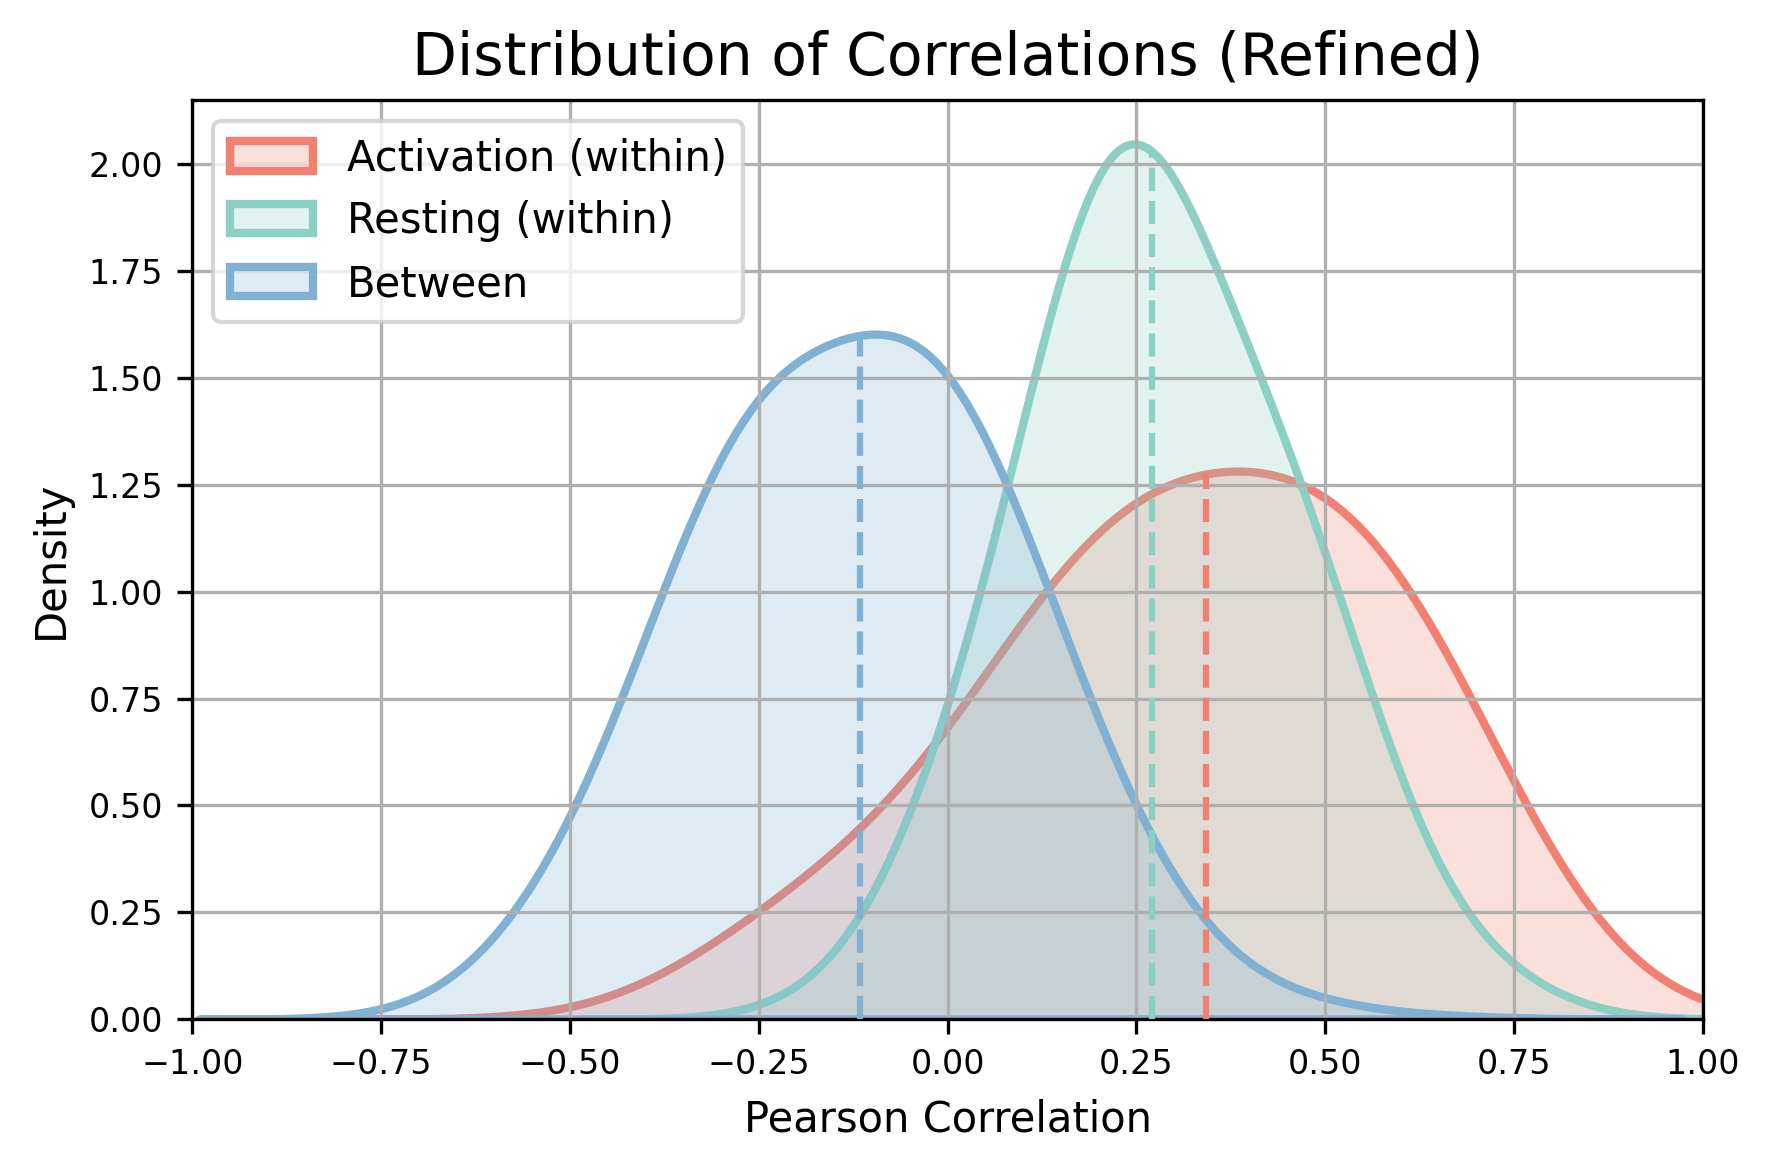

Number of activation indices: 50
Number of resting indices: 50


/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))


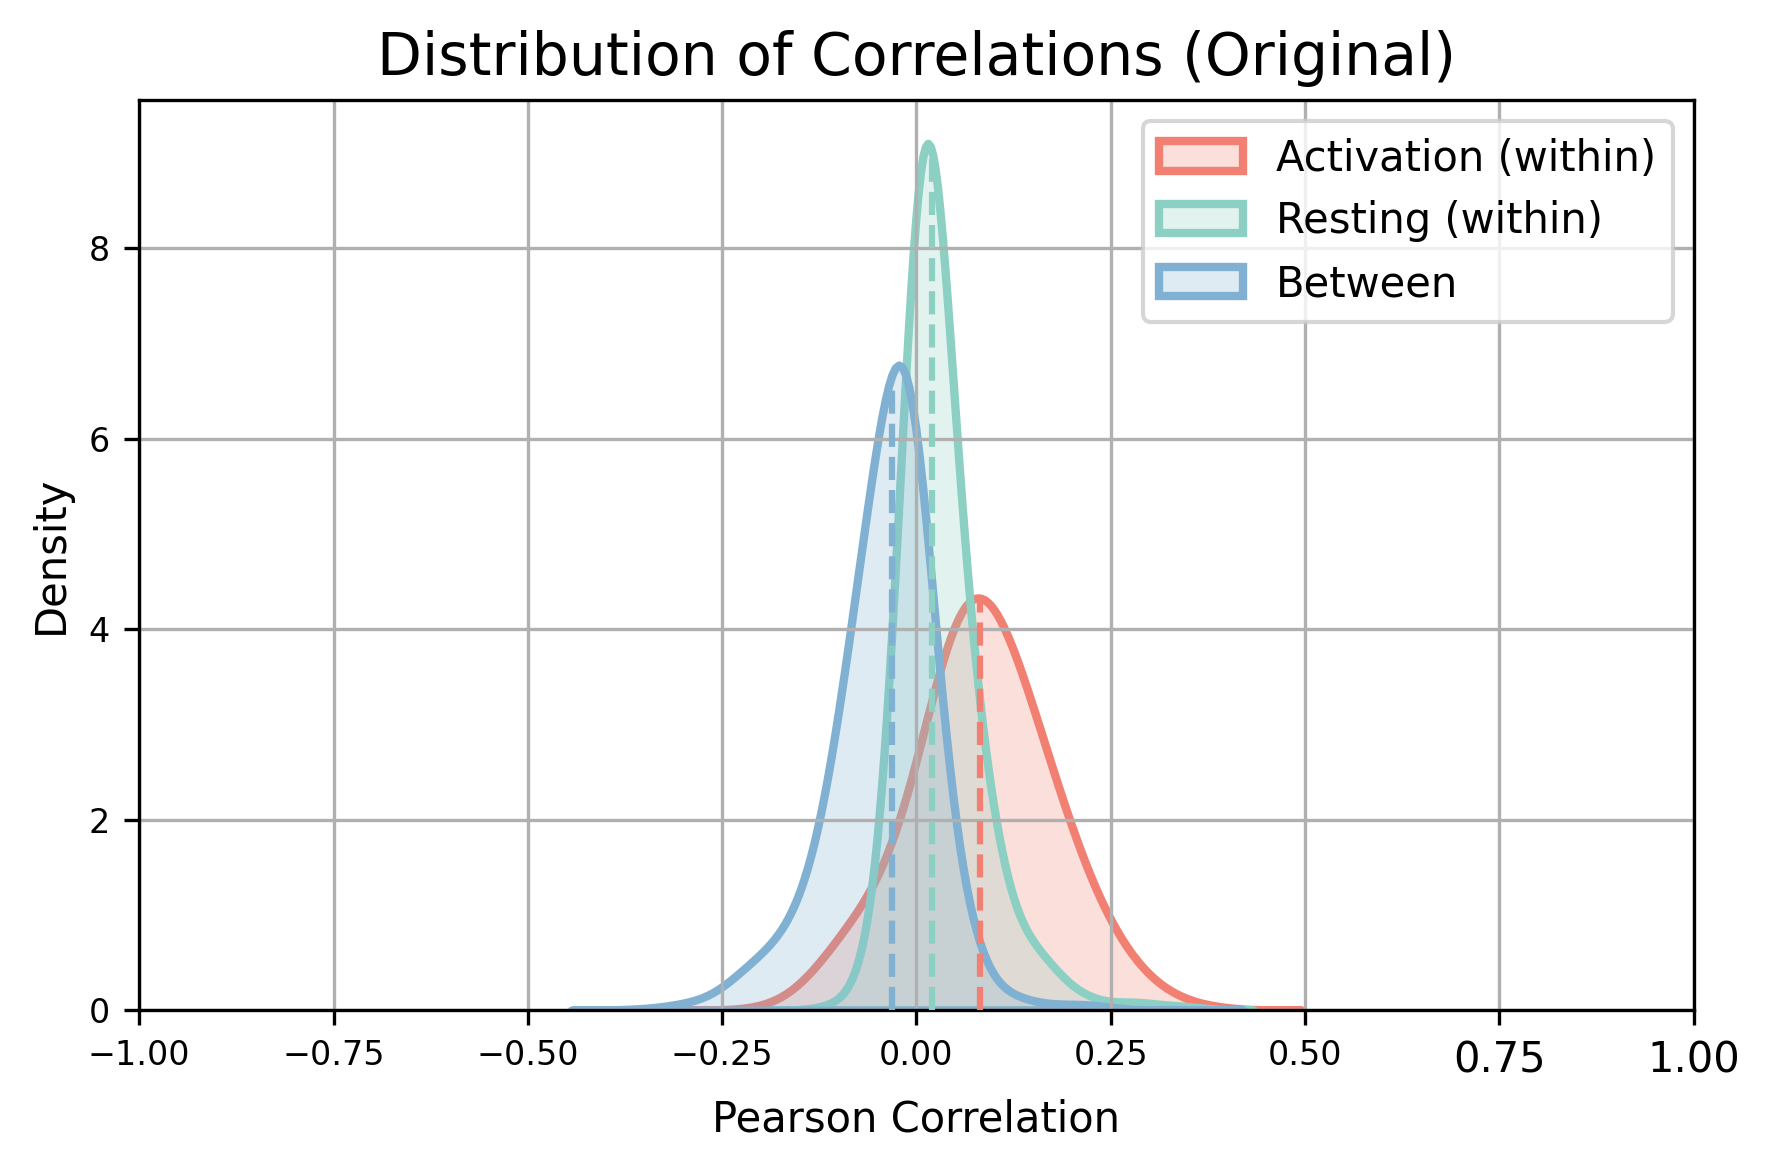

In [11]:
# Prepare the gene list
activation_top50 = activation.head(2000)["gene"].tolist()
resting_top50    = resting.head(2000)["gene"].tolist()

activation_prefixes = [gene + '-' for gene in activation_top50]
resting_prefixes    = [gene + '-' for gene in resting_top50]

# Filter the isoform names based on these prefixes
activation_features = adata_transcript_raw_combined.var_names[
    adata_transcript_raw_combined.var_names.str.startswith(tuple(activation_prefixes))
]
resting_features = adata_transcript_raw_combined.var_names[
    adata_transcript_raw_combined.var_names.str.startswith(tuple(resting_prefixes))
]

activation_indices = [adata_transcript_raw_combined.var_names.get_loc(gene) for gene in activation_features]
resting_indices    = [adata_transcript_raw_combined.var_names.get_loc(gene) for gene in resting_features]

# Filter out isoforms that are expressed in less than 10% of cells in matrix_new
n_cells = matrix_new.shape[0]
expr_threshold = 0.1 * n_cells
activation_indices = [idx for idx in activation_indices if (matrix_raw[:, idx] > 0).sum() >= expr_threshold]
resting_indices    = [idx for idx in resting_indices if (matrix_raw[:, idx] > 0).sum() >= expr_threshold]

# keep the first 50 in each group
activation_indices = activation_indices[:50]
resting_indices    = resting_indices[:50]

print(f"Activation features: {len(activation_indices)}")
print(f"Resting features:    {len(resting_indices)}")

# Subset matrix_new and matrix_raw for each group
matrix1_activation = matrix_new[:, activation_indices]
matrix1_resting    = matrix_new[:, resting_indices]

matrix2_activation = matrix_raw[:, activation_indices]
matrix2_resting    = matrix_raw[:, resting_indices]

# For between-group comparisons, combine the indices
combined_indices = activation_indices + resting_indices

# Define a function to compute the Pearson correlation matrix (columns as variables)
def compute_corr_matrix(matrix):
    return np.corrcoef(matrix, rowvar=False)

corr1_activation = compute_corr_matrix(matrix1_activation)
corr1_resting    = compute_corr_matrix(matrix1_resting)

# For between-group correlations in Matrix 1:
matrix1_combined = matrix_new[:, combined_indices]
corr1_combined = compute_corr_matrix(matrix1_combined)
n_act = len(activation_indices)
n_rest = len(resting_indices)
# Extract the off-diagonal block: activation (rows) vs resting (columns)
between_corr1 = corr1_combined[:n_act, n_act:].flatten()

# For Matrix 2:
corr2_activation = compute_corr_matrix(matrix2_activation)
corr2_resting    = compute_corr_matrix(matrix2_resting)

matrix2_combined = matrix_raw[:, combined_indices]
corr2_combined = compute_corr_matrix(matrix2_combined)
# Use same n_act and n_rest as above
between_corr2 = corr2_combined[:n_act, n_act:].flatten()

# extract unique pairwise correlations (upper triangle, excluding the diagonal)
def get_within_corr(corr_matrix):
    n = corr_matrix.shape[0]
    iu = np.triu_indices(n, k=1)
    return corr_matrix[iu]

within_corr1_activation = get_within_corr(corr1_activation)
within_corr1_resting    = get_within_corr(corr1_resting)

within_corr2_activation = get_within_corr(corr2_activation)
within_corr2_resting    = get_within_corr(corr2_resting)

# calculating median
from scipy.stats import gaussian_kde

def kde_with_capped_median(x, color, label, bw_adjust=1.0):
    ax = plt.gca()
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return

    sns.kdeplot(x, fill=True, lw=2, color=color, label=label, bw_adjust=bw_adjust, ax=ax)

    med = np.median(x)
    try:
        kde = gaussian_kde(x, bw_method=lambda s: s.scotts_factor() * bw_adjust)
        y_med = float(kde.evaluate([med]))
        if not np.isfinite(y_med):  # rare numerical issue
            return
    except Exception:
        return

    ax.vlines(med, 0, y_med, colors=color, linestyles='--', linewidth=1.5, zorder=3)

figsize = (6, 4)
dpi = 300
xlabel_fs = 10
ylabel_fs = 10
title_fs = 14
legend_fs = 10

color_activation = "#F18072"
color_resting    = "#8CD0C3"
color_between    = "#80B1D2"


# Matrix new
plt.figure(figsize=figsize, dpi=dpi)
kde_with_capped_median(within_corr1_activation, color_activation, "Activation (within)", bw_adjust=2)
kde_with_capped_median(within_corr1_resting,    color_resting,    "Resting (within)",  bw_adjust=2)
kde_with_capped_median(between_corr1,           color_between,    "Between",           bw_adjust=2)
plt.xlabel("Pearson Correlation", fontsize=xlabel_fs)
plt.ylabel("Density", fontsize=ylabel_fs)
plt.title("Distribution of Correlations (Refined)", fontsize=title_fs)
plt.legend(fontsize=legend_fs)
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.xlim(-1, 1); plt.grid(True); plt.tight_layout(); plt.show()

print("Number of activation indices:", len(activation_indices))
print("Number of resting indices:", len(resting_indices))

# Matrix raw
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
kde_with_capped_median(within_corr2_activation, color_activation, "Activation (within)", bw_adjust=2)
kde_with_capped_median(within_corr2_resting,    color_resting,    "Resting (within)",  bw_adjust=2)
kde_with_capped_median(between_corr2,           color_between,    "Between",           bw_adjust=2)
plt.xlabel("Pearson Correlation", fontsize=xlabel_fs)
plt.ylabel("Density", fontsize=ylabel_fs)
plt.title("Distribution of Correlations (Original)", fontsize=title_fs)
plt.legend(fontsize=legend_fs)
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.xlim(-1, 1); plt.grid(True); plt.tight_layout(); plt.show()

/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))


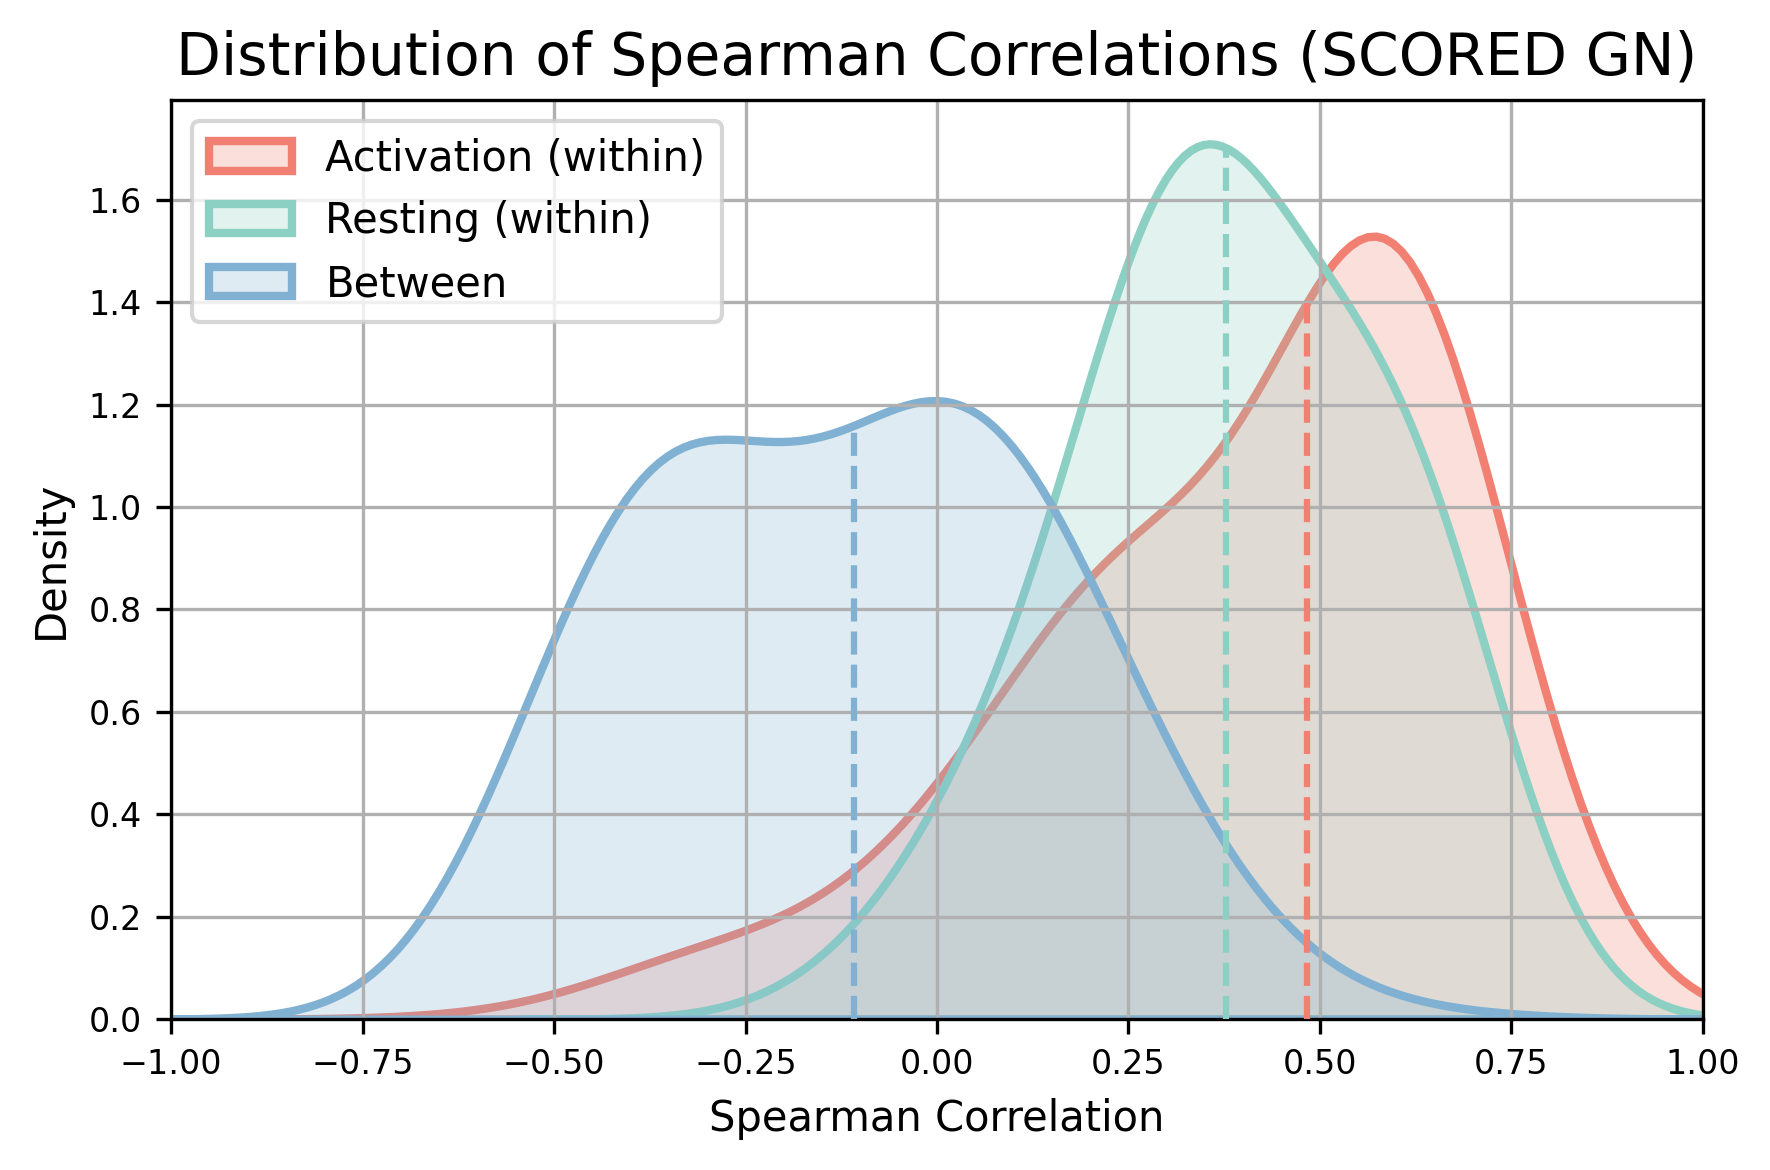

/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))


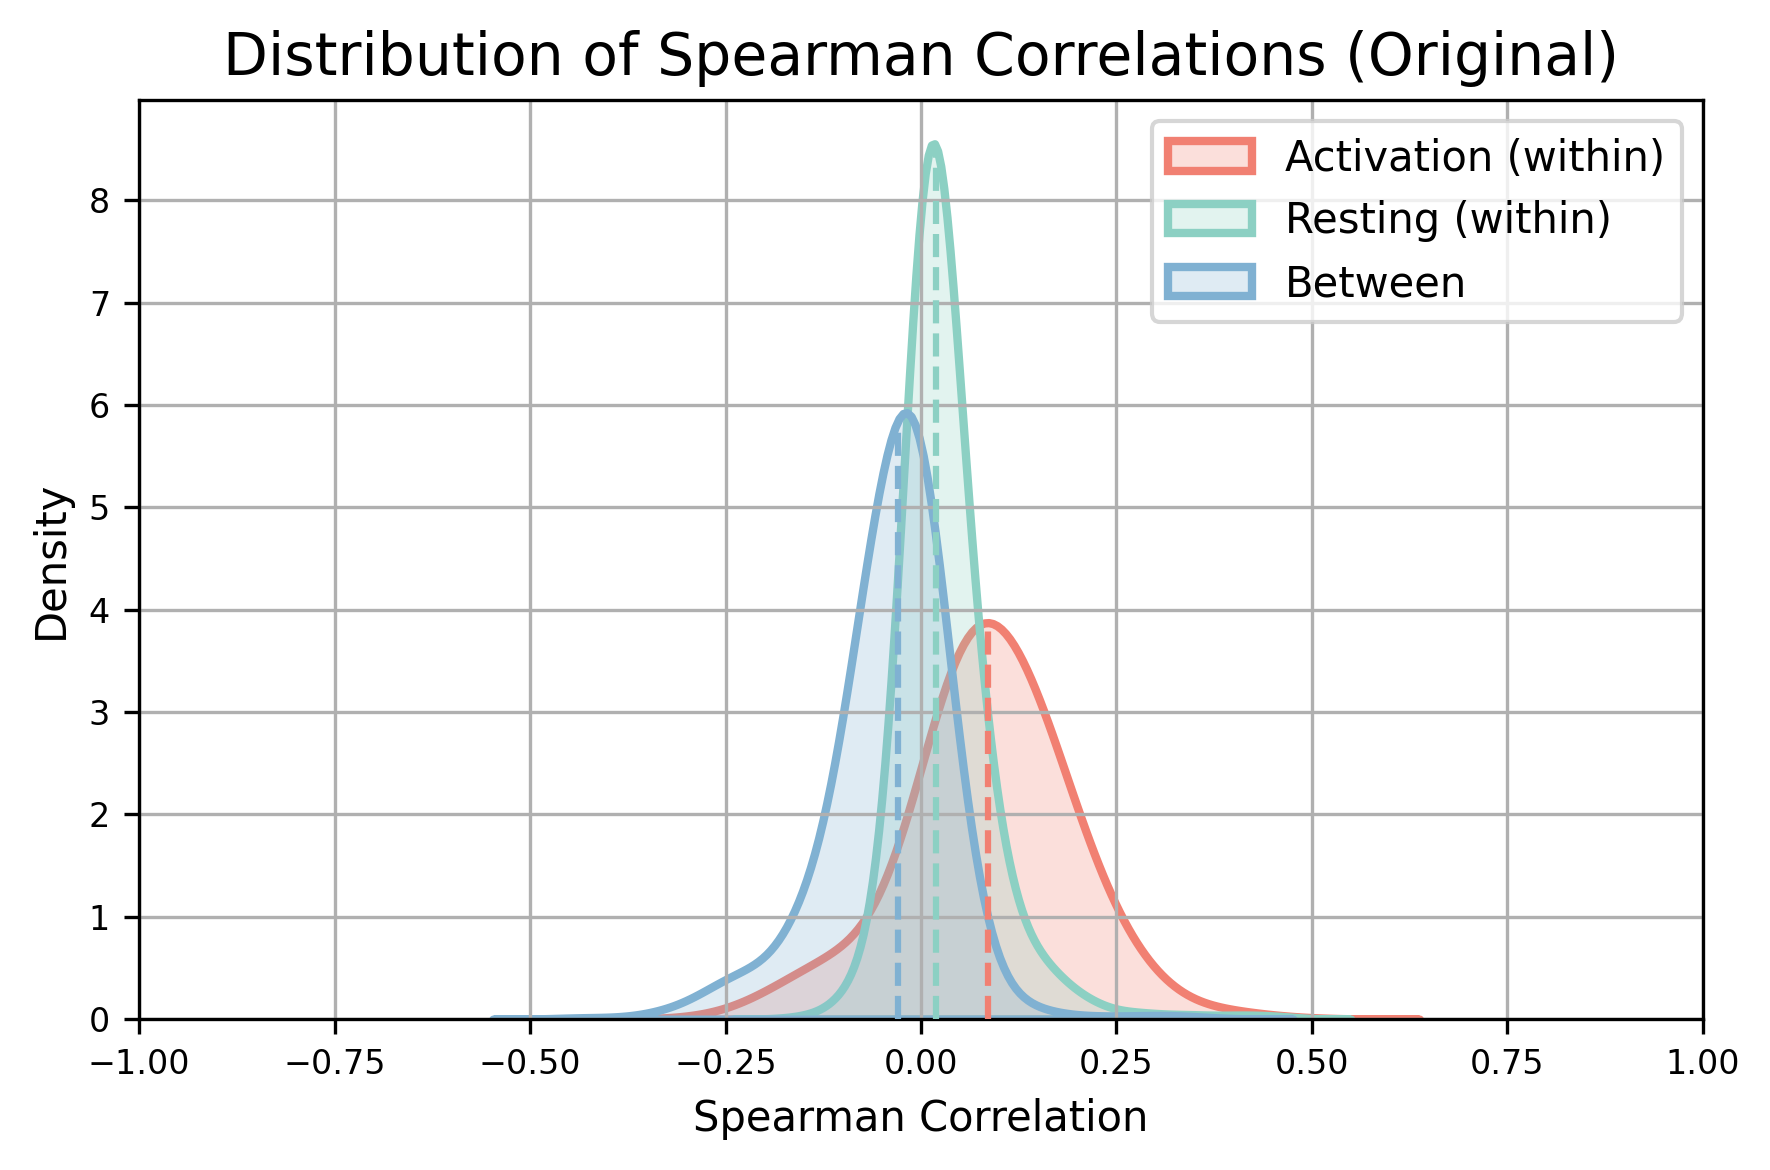

In [12]:
def compute_corr_matrix(matrix):
    # spearmanr
    corr_matrix, _ = spearmanr(matrix, axis=0)
    return corr_matrix

# For Matrix 1:
corr1_activation = compute_corr_matrix(matrix1_activation)
corr1_resting    = compute_corr_matrix(matrix1_resting)

matrix1_combined = matrix_new[:, combined_indices]
corr1_combined   = compute_corr_matrix(matrix1_combined)
n_act = len(activation_indices)
n_rest = len(resting_indices)
between_corr1 = corr1_combined[:n_act, n_act:].flatten()

# For Matrix 2:
corr2_activation = compute_corr_matrix(matrix2_activation)
corr2_resting    = compute_corr_matrix(matrix2_resting)

matrix2_combined = matrix_raw[:, combined_indices]
corr2_combined   = compute_corr_matrix(matrix2_combined)
between_corr2    = corr2_combined[:n_act, n_act:].flatten()

# same helper to extract upper‐triangle
def get_within_corr(corr_matrix):
    iu = np.triu_indices(corr_matrix.shape[0], k=1)
    return corr_matrix[iu]

within_corr1_activation = get_within_corr(corr1_activation)
within_corr1_resting    = get_within_corr(corr1_resting)
within_corr2_activation = get_within_corr(corr2_activation)
within_corr2_resting    = get_within_corr(corr2_resting)


figsize = (6, 4)
dpi = 300
xlabel_fs = 10
ylabel_fs = 10
title_fs = 14
legend_fs = 10

color_activation = "#F18072"
color_resting    = "#8CD0C3"
color_between    = "#80B1D2"

# Plot for Matrix 1
plt.figure(figsize=figsize, dpi=dpi)
kde_with_capped_median(within_corr1_activation, color_activation, "Activation (within)", bw_adjust=2)
kde_with_capped_median(within_corr1_resting,    color_resting,    "Resting (within)",  bw_adjust=2)
kde_with_capped_median(between_corr1,           color_between,    "Between",           bw_adjust=2)
plt.xlabel("Spearman Correlation", fontsize=xlabel_fs)
plt.ylabel("Density",               fontsize=ylabel_fs)
plt.title("Distribution of Spearman Correlations (SCORED GN)", fontsize=title_fs)
plt.legend(fontsize=legend_fs)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlim(-1, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot for Matrix 2
plt.figure(figsize=figsize, dpi=dpi)
kde_with_capped_median(within_corr2_activation, color_activation, "Activation (within)", bw_adjust=2)
kde_with_capped_median(within_corr2_resting,    color_resting,    "Resting (within)",  bw_adjust=2)
kde_with_capped_median(between_corr2,           color_between,    "Between",           bw_adjust=2)
plt.xlabel("Spearman Correlation", fontsize=xlabel_fs)
plt.ylabel("Density",               fontsize=ylabel_fs)
plt.title("Distribution of Spearman Correlations (Original)", fontsize=title_fs)
plt.legend(fontsize=legend_fs)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlim(-1, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

Refined  — ROC-AUC: 0.905 | PR-AUC: 0.917
Original — ROC-AUC: 0.858 | PR-AUC: 0.878


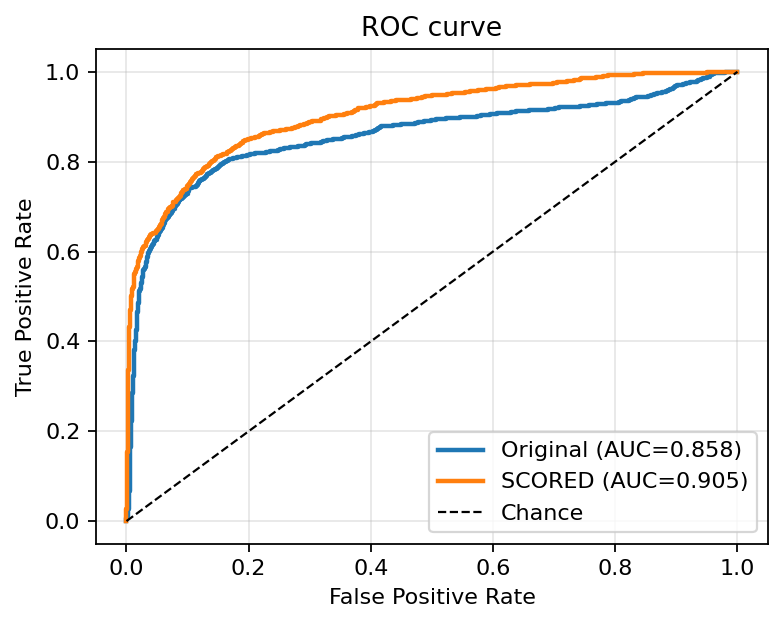

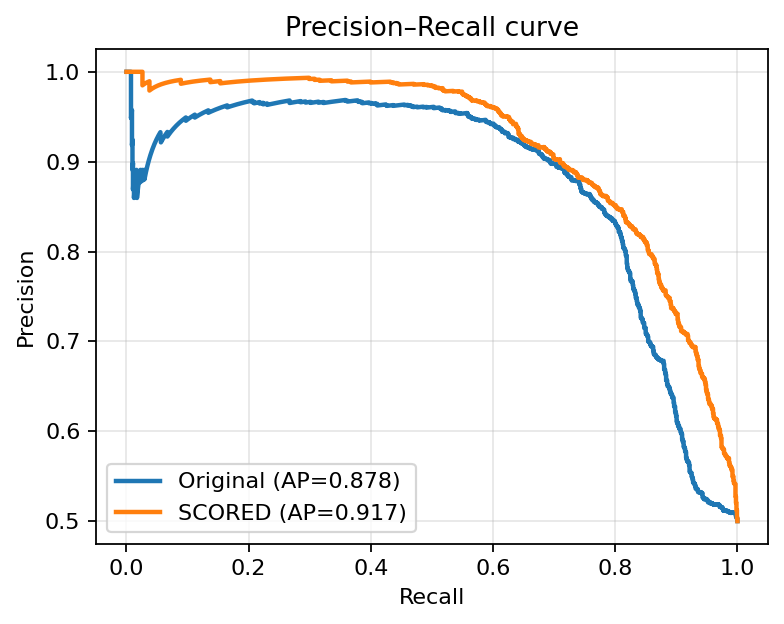

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, f1_score

def build_y_scores(pos, neg):
    y = np.concatenate([np.ones_like(pos), np.zeros_like(neg)])
    s = np.concatenate([pos, neg])
    ok = np.isfinite(s)
    return y[ok], s[ok]

def balanced_weights(y):
    pos = (y == 1)
    neg = ~pos
    w = np.empty_like(y, dtype=float)
    w[pos] = 0.5 / max(pos.sum(), 1)
    w[neg] = 0.5 / max(neg.sum(), 1)
    return w

def get_curves(y, s, w=None):
    fpr, tpr, thr = roc_curve(y, s, sample_weight=w)
    roc_auc = auc(fpr, tpr)
    pr_p, pr_r, _ = precision_recall_curve(y, s, sample_weight=w)
    ap = average_precision_score(y, s, sample_weight=w)
    return {"fpr": fpr, "tpr": tpr, "roc_auc": roc_auc, "pr_p": pr_p, "pr_r": pr_r, "ap": ap}

def f1_at_threshold(y, s, thr=0.0, w=None):
    yhat = (s >= thr).astype(int)
    return f1_score(y, yhat, sample_weight=w, zero_division=0)

# Refined
y1, s1 = build_y_scores(within_corr1_activation, between_corr1)
w1 = balanced_weights(y1)
res1 = get_curves(y1, s1, w1)
f1 = f1_at_threshold(y1, s1, thr=0.0, w=w1)

# Original
y2, s2 = build_y_scores(within_corr2_activation, between_corr2)
w2 = balanced_weights(y2)
res2 = get_curves(y2, s2, w2)
f2 = f1_at_threshold(y2, s2, thr=0.0, w=w2)

print(f"Refined  — ROC-AUC: {res1['roc_auc']:.3f} | PR-AUC: {res1['ap']:.3f}")
print(f"Original — ROC-AUC: {res2['roc_auc']:.3f} | PR-AUC: {res2['ap']:.3f}")

# ROC
plt.figure(figsize=(5,4), dpi=160)
plt.plot(res2["fpr"], res2["tpr"], lw=2, label=f"Original (AUC={res2['roc_auc']:.3f})")
plt.plot(res1["fpr"], res1["tpr"], lw=2, label=f"SCORED (AUC={res1['roc_auc']:.3f})")
plt.plot([0,1], [0,1], "k--", lw=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

# Precision–Recall
plt.figure(figsize=(5,4), dpi=160)
plt.plot(res2["pr_r"], res2["pr_p"], lw=2, label=f"Original (AP={res2['ap']:.3f})")
plt.plot(res1["pr_r"], res1["pr_p"], lw=2, label=f"SCORED (AP={res1['ap']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.legend()
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

Refined  — ROC-AUC: 0.930 | PR-AUC: 0.924
Original — ROC-AUC: 0.802 | PR-AUC: 0.754


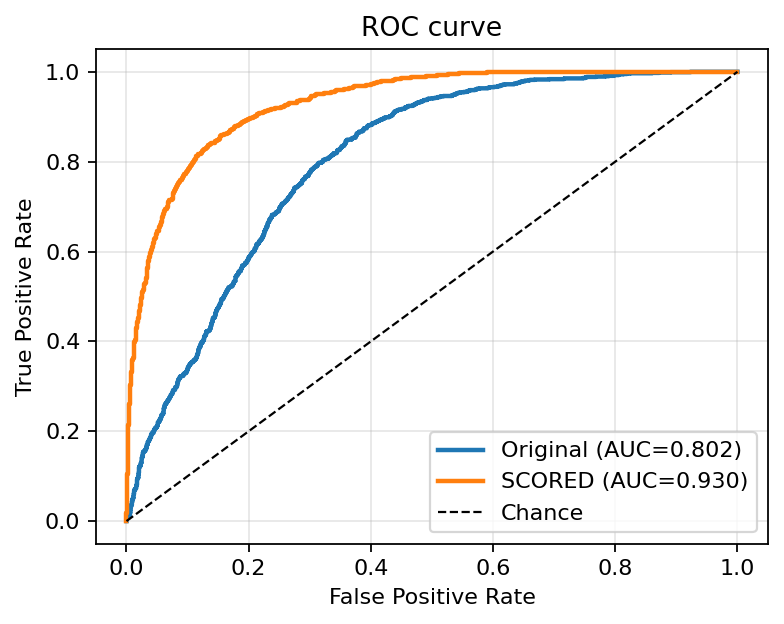

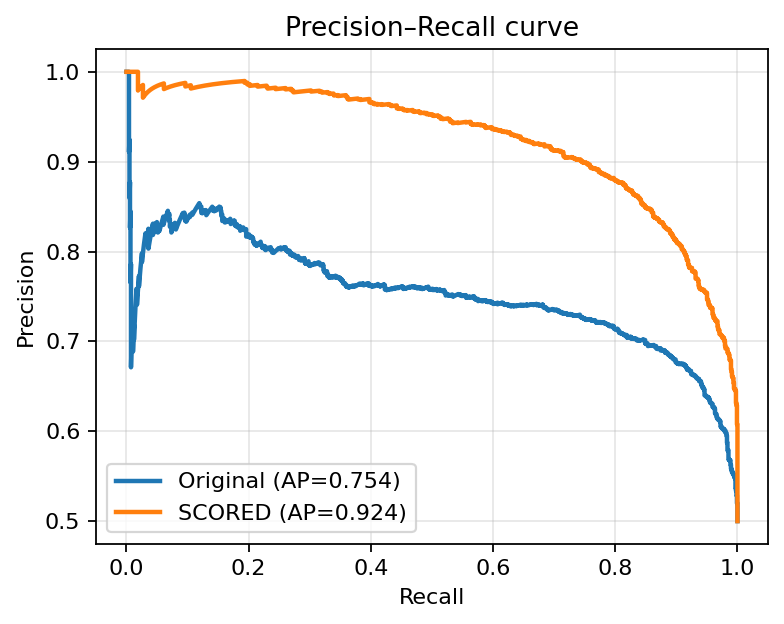

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def build_y_scores(pos, neg):
    y = np.concatenate([np.ones_like(pos), np.zeros_like(neg)])
    s = np.concatenate([pos, neg])
    ok = np.isfinite(s)
    return y[ok], s[ok]

def balanced_weights(y):
    pos = (y == 1)
    neg = ~pos
    w = np.empty_like(y, dtype=float)
    w[pos] = 0.5 / max(pos.sum(), 1)
    w[neg] = 0.5 / max(neg.sum(), 1)
    return w

def get_curves(y, s, w=None):
    fpr, tpr, thr = roc_curve(y, s, sample_weight=w)
    roc_auc = auc(fpr, tpr)
    pr_p, pr_r, _ = precision_recall_curve(y, s, sample_weight=w)
    ap = average_precision_score(y, s, sample_weight=w)
    return {"fpr": fpr, "tpr": tpr, "roc_auc": roc_auc, "pr_p": pr_p, "pr_r": pr_r, "ap": ap}

# Refined
y3, s3 = build_y_scores(within_corr1_resting, between_corr1)
w3 = balanced_weights(y3)
res3 = get_curves(y3, s3, w3)
f3 = f1_at_threshold(y3, s3, thr=0.0, w=w3)


# Original
y4, s4 = build_y_scores(within_corr2_resting, between_corr2)
w4 = balanced_weights(y4)
res4 = get_curves(y4, s4, w4)
f4 = f1_at_threshold(y4, s4, thr=0.0, w=w4)


print(f"Refined  — ROC-AUC: {res3['roc_auc']:.3f} | PR-AUC: {res3['ap']:.3f}")
print(f"Original — ROC-AUC: {res4['roc_auc']:.3f} | PR-AUC: {res4['ap']:.3f}")

# ROC
plt.figure(figsize=(5,4), dpi=160)
plt.plot(res4["fpr"], res4["tpr"], lw=2, label=f"Original (AUC={res4['roc_auc']:.3f})")
plt.plot(res3["fpr"], res3["tpr"], lw=2, label=f"SCORED (AUC={res3['roc_auc']:.3f})")
plt.plot([0,1], [0,1], "k--", lw=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

# Precision–Recall
plt.figure(figsize=(5,4), dpi=160)
plt.plot(res4["pr_r"], res4["pr_p"], lw=2, label=f"Original (AP={res4['ap']:.3f})")
plt.plot(res3["pr_r"], res3["pr_p"], lw=2, label=f"SCORED (AP={res3['ap']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.legend()
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

## SCORED(IN)

In [15]:
adata_transcript_1 = sc.read_h5ad('./20230222_new/transcript_raw_8fc.h5ad')
new_matrix_1 = SCORED(
    adata_tr   = adata_transcript_1
)


/usr/local/lib/python3.12/dist-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 60800 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


In [16]:
adata_transcript_1.X = new_matrix_1
matrix_new = adata_transcript_1.X


/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))


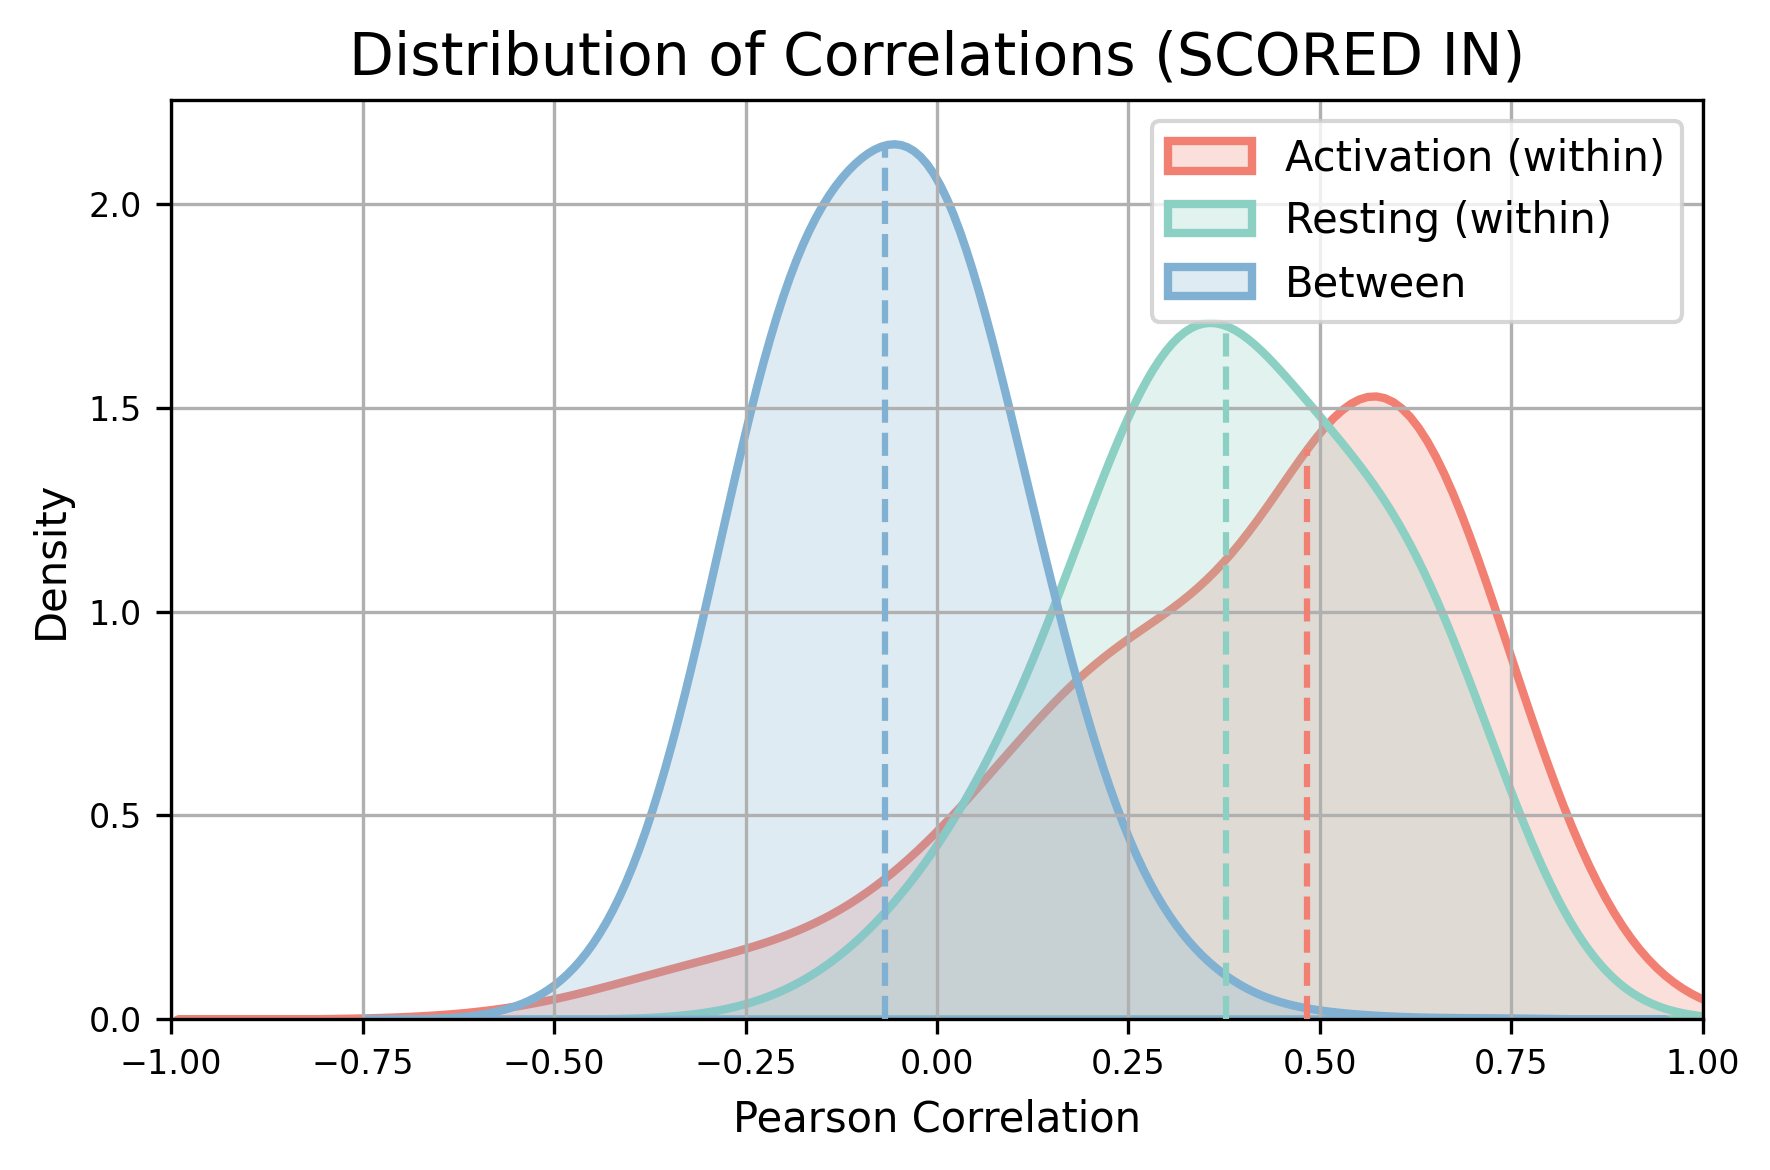

Number of activation indices: 50
Number of resting indices: 50


In [17]:
# Subset matrix_new and matrix_raw for each group
matrix1_activation = matrix_new[:, activation_indices]
matrix1_resting    = matrix_new[:, resting_indices]

# For between-group comparisons, combine the indices
combined_indices = activation_indices + resting_indices

# Define a function to compute the Pearson correlation matrix
def compute_corr_matrix(matrix):
    return np.corrcoef(matrix, rowvar=False)

# For Matrix 1
corr1_activation = compute_corr_matrix(matrix1_activation)
corr1_resting    = compute_corr_matrix(matrix1_resting)

# For between-group correlations in Matrix 1
matrix1_combined = matrix_new[:, combined_indices]
corr1_combined = compute_corr_matrix(matrix1_combined)
n_act = len(activation_indices)
n_rest = len(resting_indices)
# Extract the off-diagonal block
between_corr1 = corr1_combined[:n_act, n_act:].flatten()

figsize = (6, 4)
dpi = 300
xlabel_fs = 10
ylabel_fs = 10
title_fs = 14
legend_fs = 10

color_activation = "#F18072"
color_resting    = "#8CD0C3"
color_between    = "#80B1D2"


# Matrix new
plt.figure(figsize=figsize, dpi=dpi)
kde_with_capped_median(within_corr1_activation, color_activation, "Activation (within)", bw_adjust=2)
kde_with_capped_median(within_corr1_resting,    color_resting,    "Resting (within)",  bw_adjust=2)
kde_with_capped_median(between_corr1,           color_between,    "Between",           bw_adjust=2)
plt.xlabel("Pearson Correlation", fontsize=xlabel_fs)
plt.ylabel("Density", fontsize=ylabel_fs)
plt.title("Distribution of Correlations (SCORED IN)", fontsize=title_fs)
plt.legend(fontsize=legend_fs)
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.xlim(-1, 1); plt.grid(True); plt.tight_layout(); plt.show()

print("Number of activation indices:", len(activation_indices))
print("Number of resting indices:", len(resting_indices))


/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))
/tmp/ipython-input-895673461.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_med = float(kde.evaluate([med]))


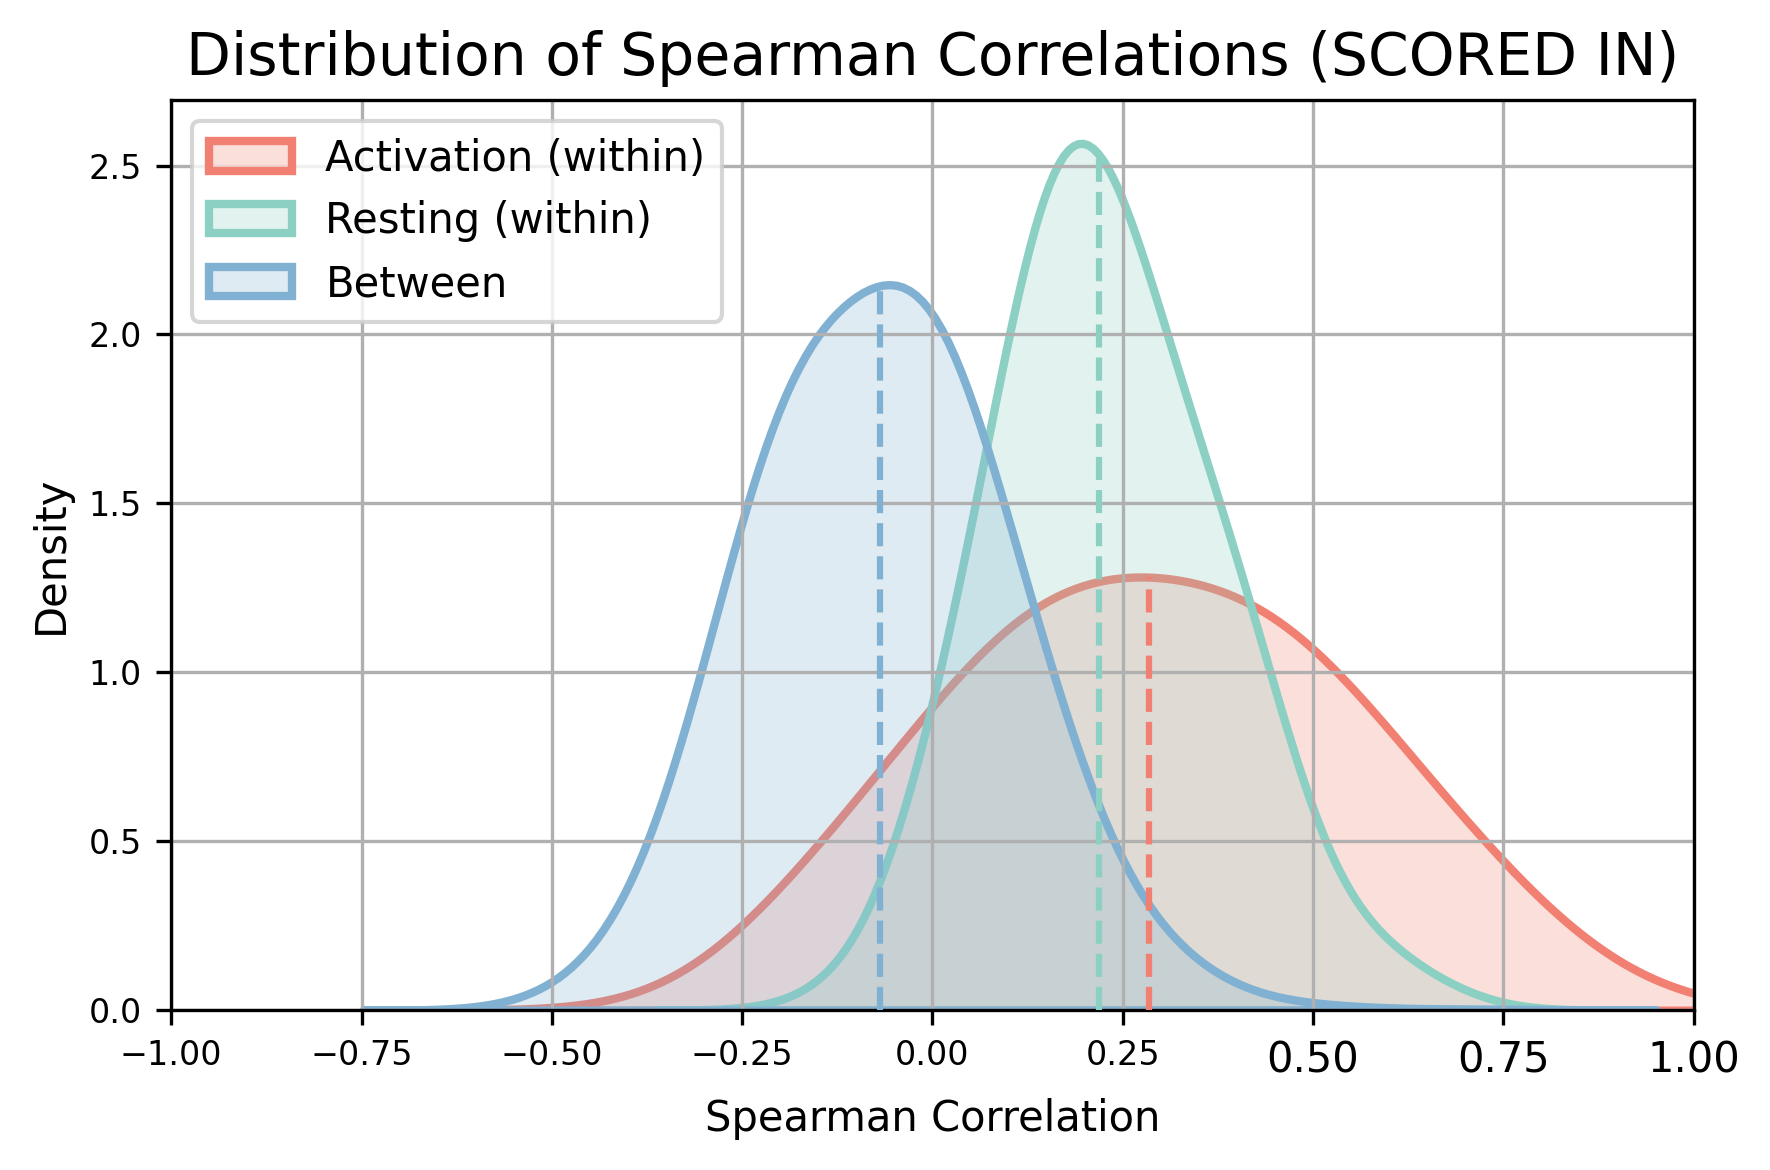

In [18]:
# For Matrix 1:
corr1_activation = compute_corr_matrix(matrix1_activation)
corr1_resting    = compute_corr_matrix(matrix1_resting)

matrix1_combined = matrix_new[:, combined_indices]
corr1_combined   = compute_corr_matrix(matrix1_combined)
n_act = len(activation_indices)
n_rest = len(resting_indices)
between_corr1 = corr1_combined[:n_act, n_act:].flatten()


within_corr1_activation = get_within_corr(corr1_activation)
within_corr1_resting    = get_within_corr(corr1_resting)


figsize = (6, 4)
dpi = 300
xlabel_fs = 10
ylabel_fs = 10
title_fs = 14
legend_fs = 10

color_activation = "#F18072"
color_resting    = "#8CD0C3"
color_between    = "#80B1D2"

plt.figure(figsize=figsize, dpi=dpi)
kde_with_capped_median(within_corr1_activation, color_activation, "Activation (within)", bw_adjust=2)
kde_with_capped_median(within_corr1_resting,    color_resting,    "Resting (within)",  bw_adjust=2)
kde_with_capped_median(between_corr1,           color_between,    "Between",           bw_adjust=2)
plt.xlabel("Spearman Correlation", fontsize=xlabel_fs)
plt.ylabel("Density",               fontsize=ylabel_fs)
plt.title("Distribution of Spearman Correlations (SCORED IN)", fontsize=title_fs)
plt.legend(fontsize=legend_fs)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlim(-1, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
y1_1, s1_1 = build_y_scores(within_corr1_activation, between_corr1)
w1_1 = balanced_weights(y1_1)
res1_1 = get_curves(y1_1, s1_1, w1_1)
f1_1 = f1_at_threshold(y1_1, s1_1, thr=0.0, w=w1_1)


y3_1, s3_1 = build_y_scores(within_corr1_resting, between_corr1)
w3_1 = balanced_weights(y3_1)
res3_1 = get_curves(y3_1, s3_1, w3_1)
f3_1 = f1_at_threshold(y3_1, s3_1, thr=0.0, w=w3_1)



## Heatmaps

In [20]:
adata_transcript_1 = sc.read_h5ad('./20230222_new/transcript_raw_8fc.h5ad')

new_matrix_1 = SCORED(
    adata_tr   = adata_transcript_1,
    adata_g = adata_gene_1
)

adata_transcript_1.X = new_matrix_1
matrix_new = adata_transcript_1.X


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/local/lib/python3.12/dist-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 3706 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


In [21]:
%config InlineBackend.figure_format = 'retina'
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def visualize_correlation_matrix(cor_matrix, arranged_features, title):
    plt.figure(figsize=(8, 6))

    colors = ["#8CD0C3", "#FFFFFF", "#C090C8"]
    cmap = LinearSegmentedColormap.from_list("custom_diverging", colors)

    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    ax = sns.heatmap(
        cor_matrix,
        cmap=cmap,
        norm=norm,
        annot=False,
        fmt=".2f",
        xticklabels=arranged_features,
        yticklabels=arranged_features,
        cbar_kws={
            "shrink": 0.8,
            "ticks": [-1, -0.5, 0, 0.5, 1],
            "label": "Correlation"
        }
    )
    ax.tick_params(
        axis='both',
        which='both',
        length=0,
        labelsize=5
    )
    ax.grid(False)


    plt.title(title)
    plt.xticks(rotation=90, fontsize=5)
    plt.yticks(fontsize=5)
    plt.tight_layout()
    plt.show()




prefixes = ['FOSL1-', 'IL2RA-', 'SLC6A9-', 'DUSP4-', 'IL12RB2-', 'BCL2L1-',
            'MFSD7-', 'NAP1L2-', 'LY9-', 'ITGA10-', 'ZNF845-', 'PHGR1-',
            "FCER1A-", "NAAA", "IL17RC"]

selected_genes = adata_transcript_raw_combined.var_names[
    adata_transcript_raw_combined.var_names.str.startswith(tuple(prefixes))
]

arranged_features = []
for prefix in prefixes:
    arranged_features.extend(selected_genes[selected_genes.str.startswith(prefix)])

arranged_indices = [adata_transcript_raw_combined.var_names.get_loc(gene) for gene in arranged_features]
matrix_1_arranged = matrix_new[:, arranged_indices]
matrix_2_arranged = matrix_raw[:, arranged_indices]

def compute_correlation_matrix(matrix):
    """
    Computes the Pearson correlation matrix for all columns in `matrix`.
    Each column is treated as a variable, and each row is an observation.
    """
    corr_matrix = np.corrcoef(matrix, rowvar=False)
    return corr_matrix

cor_matrix_1_arranged = compute_correlation_matrix(matrix_1_arranged)
cor_matrix_2_arranged = compute_correlation_matrix(matrix_2_arranged)

#visualize_correlation_matrix(cor_matrix_1_arranged, arranged_features,
#                             'Pearson Correlations of Isoform Features in Refined Data')
#visualize_correlation_matrix(cor_matrix_2_arranged, arranged_features,
#                             'Pearson Correlations of Isoform Features in Original Data')

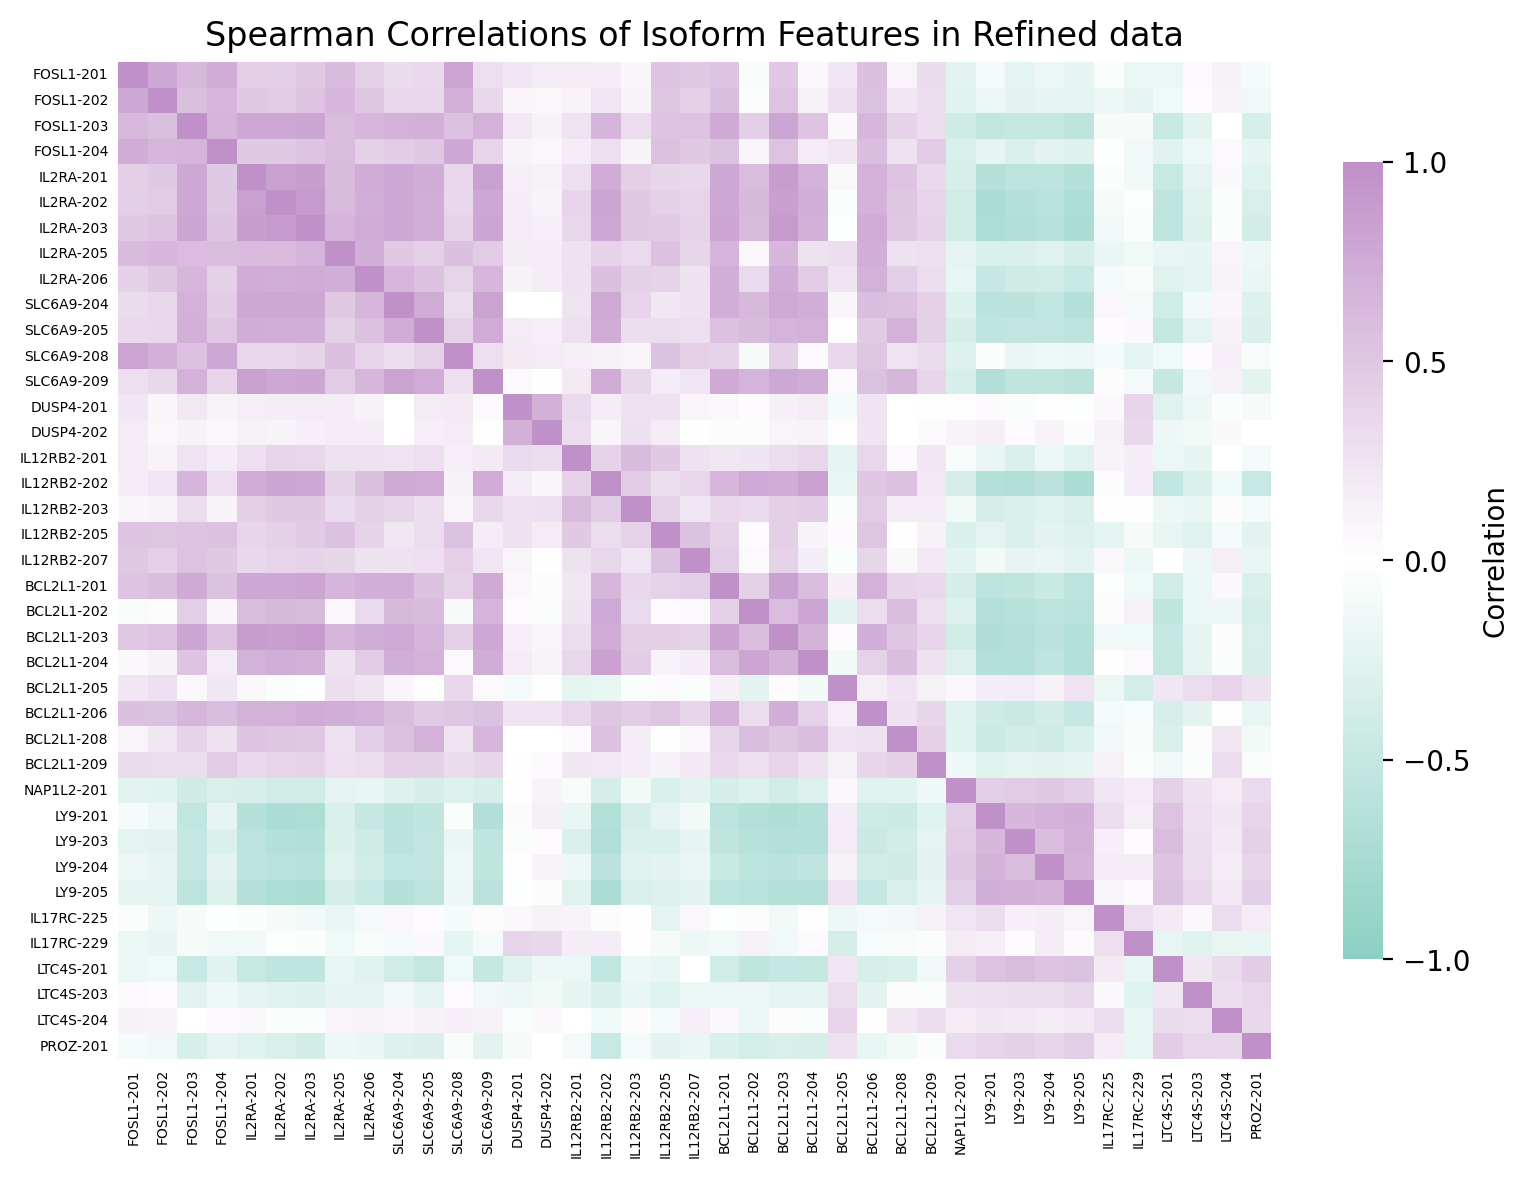

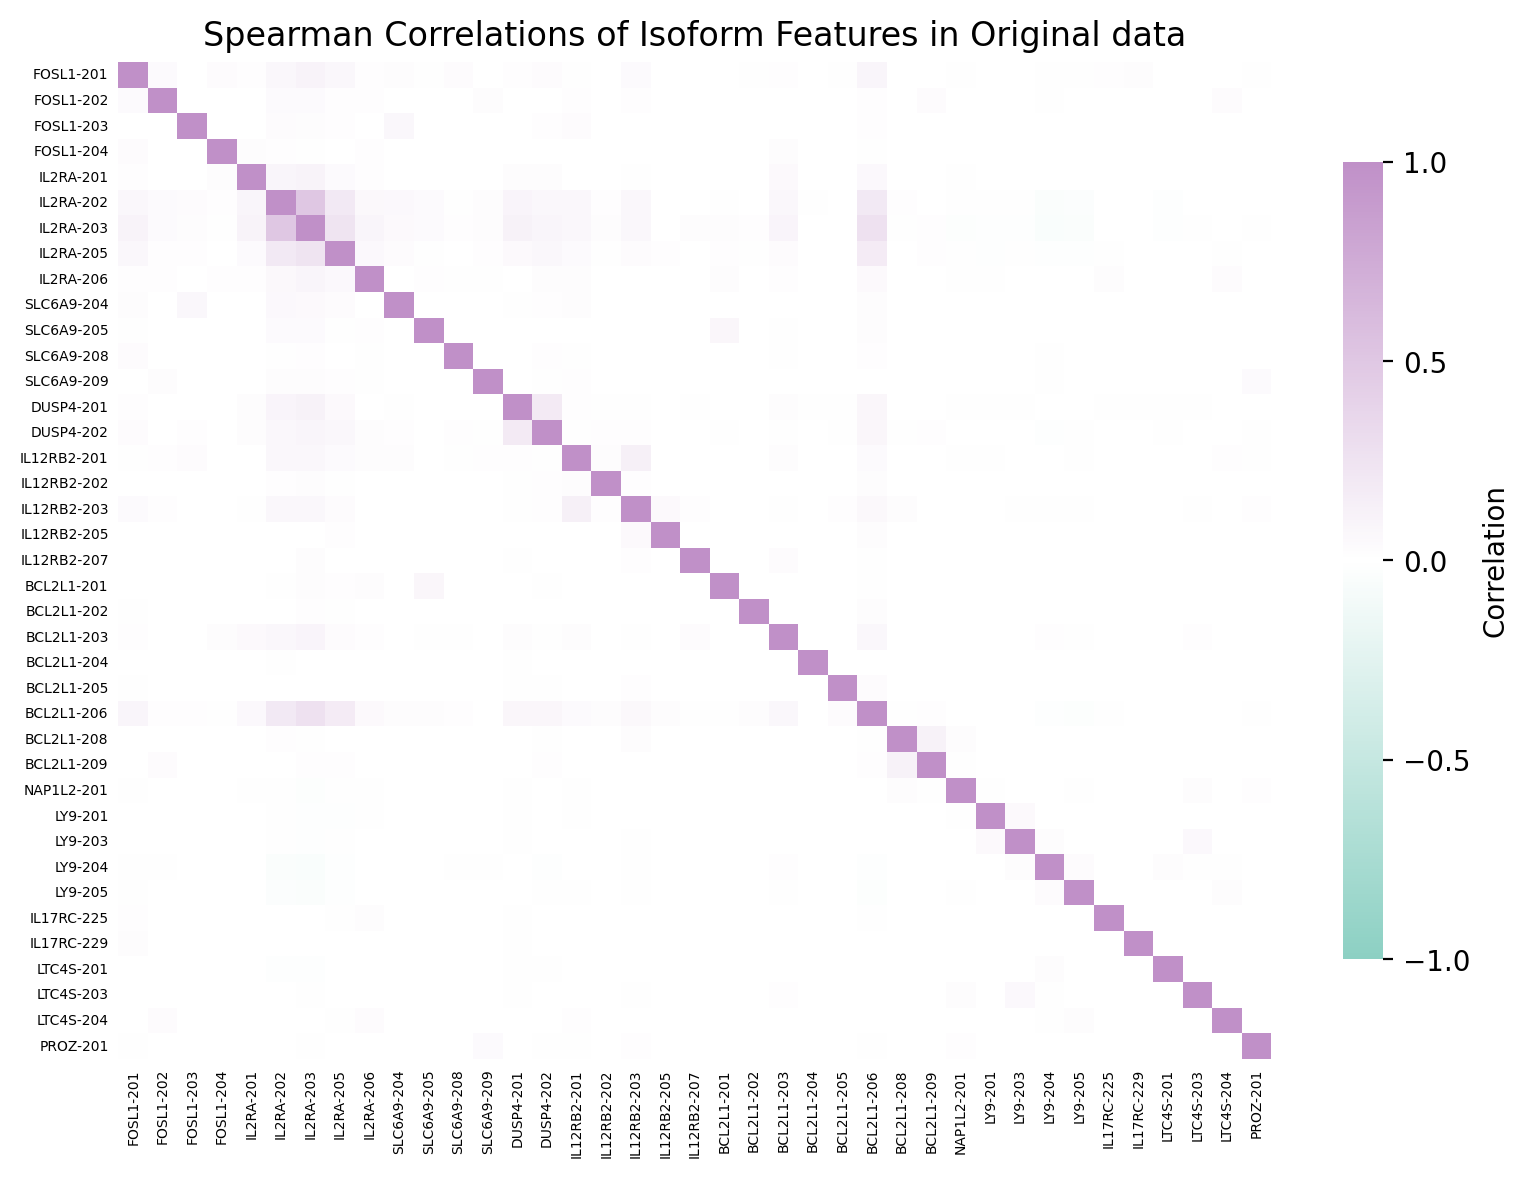

In [22]:
%config InlineBackend.figure_format = 'retina'

prefixes = ['FOSL1-', 'IL2RA-', 'SLC6A9-', 'DUSP4-', 'IL12RB2-', 'BCL2L1-',
            'MFSD7-', 'NAP1L2-', 'LY9-', 'PHGR1-', "FCER1A-", "IL17RC", 'LTC4S-', 'PROZ-']

selected_genes = adata_transcript_raw_combined.var_names[
    adata_transcript_raw_combined.var_names.str.startswith(tuple(prefixes))
]

arranged_features = []
for prefix in prefixes:
    arranged_features.extend(selected_genes[selected_genes.str.startswith(prefix)])

arranged_indices = [adata_transcript_raw_combined.var_names.get_loc(gene) for gene in arranged_features]
matrix_1_arranged = matrix_new[:, arranged_indices]
matrix_2_arranged = matrix_raw[:, arranged_indices]

def compute_correlation_matrix(matrix):
    corr_matrix, _ = spearmanr(matrix, axis=0)
    return corr_matrix

cor_matrix_1_arranged = compute_correlation_matrix(matrix_1_arranged)
cor_matrix_2_arranged = compute_correlation_matrix(matrix_2_arranged)


visualize_correlation_matrix(cor_matrix_1_arranged, arranged_features,
                             'Spearman Correlations of Isoform Features in Refined data')
visualize_correlation_matrix(cor_matrix_2_arranged, arranged_features,
                             'Spearman Correlations of Isoform Features in Original data')


In [23]:
%config InlineBackend.figure_format = 'retina'
top10 = activation['gene'].dropna().astype(str).str.strip().values[1:11].tolist()

prefixes = (
    top10
    + [
        'CREM-204','CREM-210','CREM-211','CREM-212','CREM-218','CREM-229','CREM-240',  # P1
        'CREM-203','CREM-207','CREM-224','CREM-225','CREM-228','CREM-230','CREM-236','CREM-237','CREM-242',  # P2
        'CREM-205','CREM-217','CREM-227','CREM-233','CREM-241'  # NA
      ]
)


selected_genes = adata_transcript_raw_combined.var_names[
    adata_transcript_raw_combined.var_names.str.startswith(tuple(prefixes))
]

arranged_features = []
for prefix in prefixes:
    arranged_features.extend(selected_genes[selected_genes.str.startswith(prefix)])

arranged_indices = [adata_transcript_raw_combined.var_names.get_loc(gene) for gene in arranged_features]
matrix_1_arranged = matrix_new[:, arranged_indices]
matrix_2_arranged = matrix_raw[:, arranged_indices]

def compute_correlation_matrix(matrix):
    """
    Computes the Pearson correlation matrix for all columns in `matrix`.
    Each column is treated as a variable, and each row is an observation.
    """
    corr_matrix = np.corrcoef(matrix, rowvar=False)
    return corr_matrix

cor_matrix_1_arranged = compute_correlation_matrix(matrix_1_arranged)
cor_matrix_2_arranged = compute_correlation_matrix(matrix_2_arranged)


#visualize_correlation_matrix(cor_matrix_1_arranged, arranged_features,
#                             'Pearson Correlations of Isoform Features in Refined Matrix')
#visualize_correlation_matrix(cor_matrix_2_arranged, arranged_features,
#                             'Pearson Correlations of Isoform Features in Original Matrix')

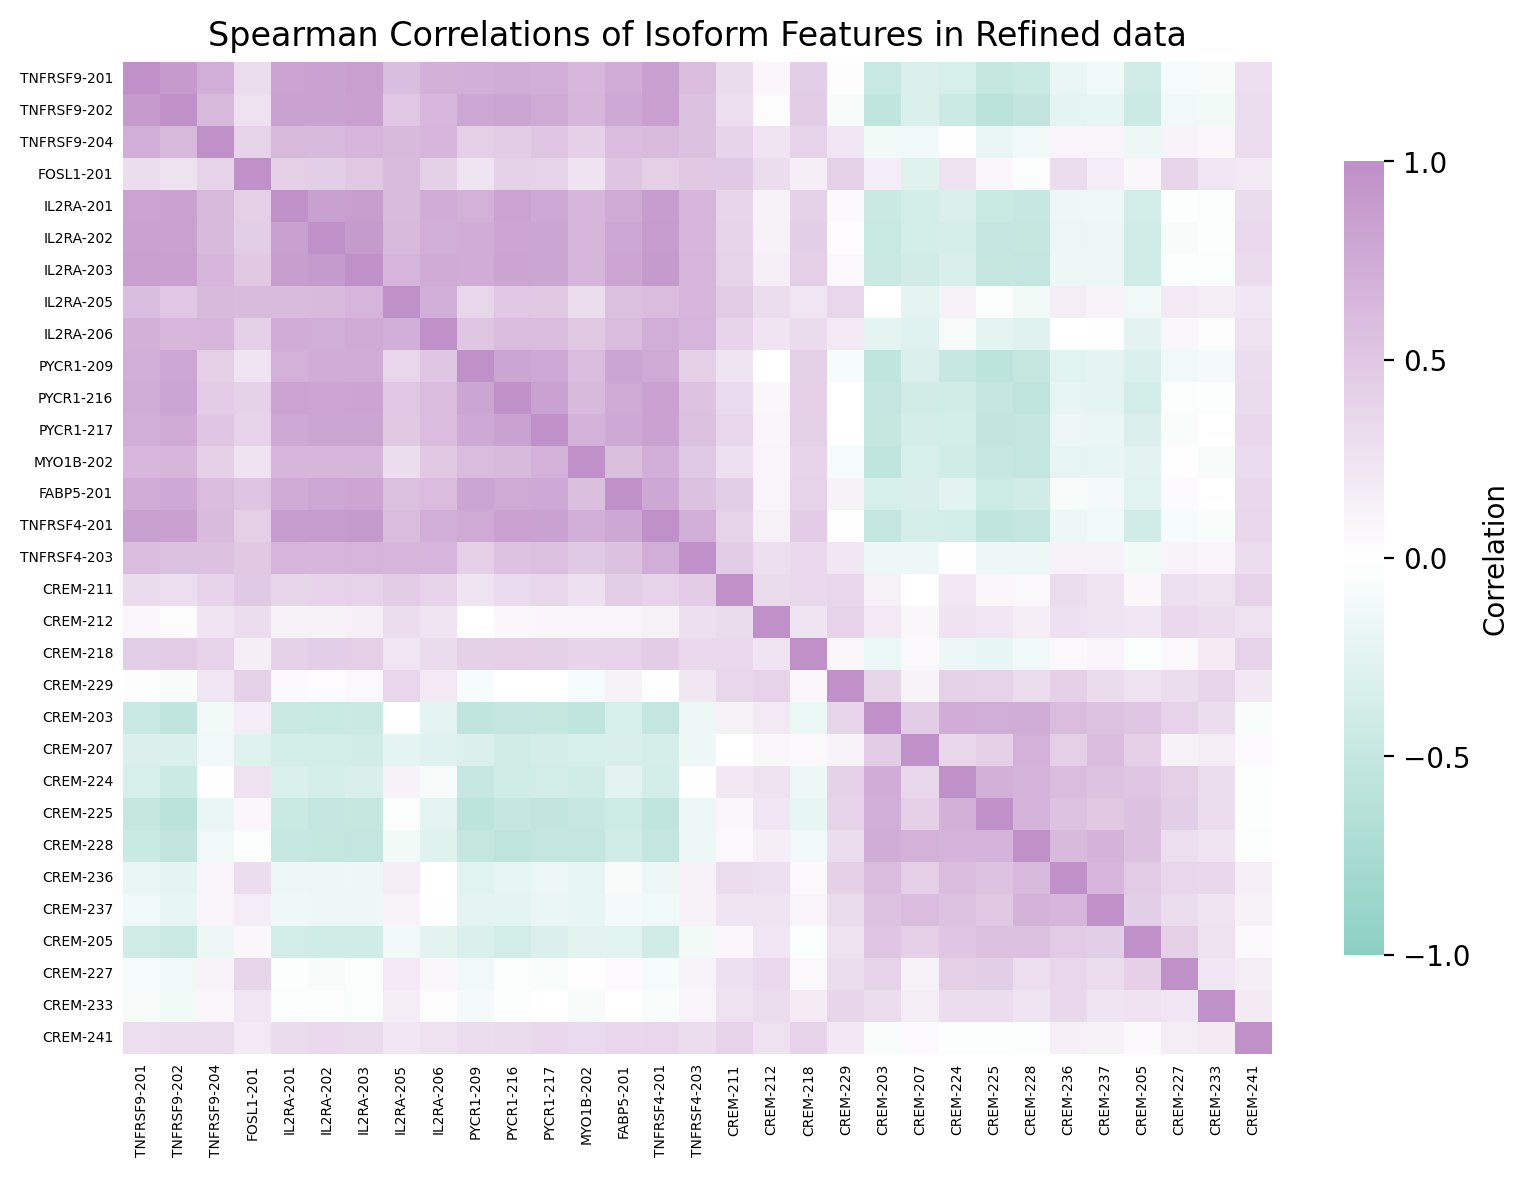

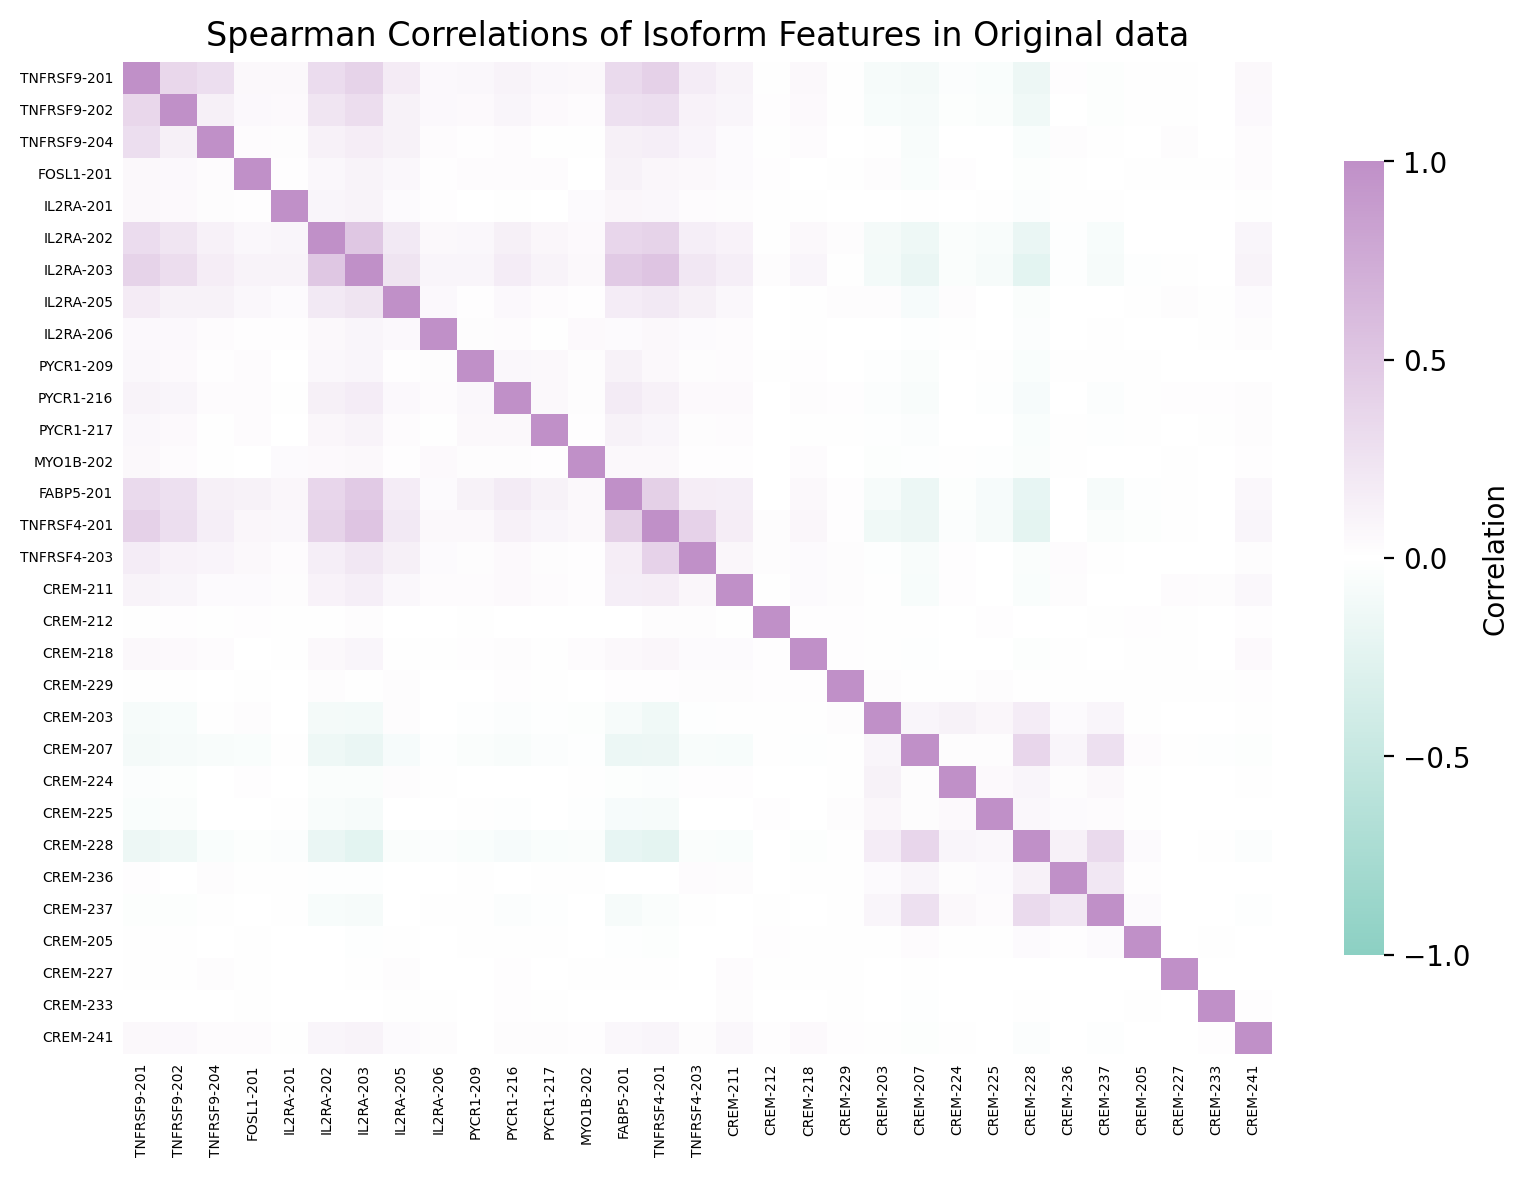

In [24]:
%config InlineBackend.figure_format = 'retina'
top10 = activation['gene'].dropna().astype(str).str.strip().values[1:11].tolist()

prefixes = (
    top10
    + [
        'CREM-204','CREM-210','CREM-211','CREM-212','CREM-218','CREM-229','CREM-240',  # P1
        'CREM-203','CREM-207','CREM-224','CREM-225','CREM-228','CREM-230','CREM-236','CREM-237','CREM-242',  # P2
        'CREM-205','CREM-217','CREM-227','CREM-233','CREM-241'  # NA
      ]
)

sc.pp.calculate_qc_metrics(
    adata_transcript_raw_combined,
    layer='counts' if 'counts' in adata_transcript_raw_combined.layers else None,
    percent_top=None, log1p=False, inplace=True
)

n_cells = adata_transcript_raw_combined.n_obs
keep = adata_transcript_raw_combined.var['n_cells_by_counts'] >= np.ceil(0.005 * n_cells)
expressed_genes = adata_transcript_raw_combined.var_names[keep]

selected_genes = adata_transcript_raw_combined.var_names[
    adata_transcript_raw_combined.var_names.str.startswith(tuple(prefixes))
]
selected_genes = selected_genes[selected_genes.isin(expressed_genes)]

arranged_features = []
for prefix in prefixes:
    arranged_features.extend(selected_genes[selected_genes.str.startswith(prefix)])

arranged_indices = [adata_transcript_raw_combined.var_names.get_loc(gene) for gene in arranged_features]
matrix_1_arranged = matrix_new[:, arranged_indices]
matrix_2_arranged = matrix_raw[:, arranged_indices]

def compute_correlation_matrix(matrix):
    corr_matrix, _ = spearmanr(matrix, axis=0)
    return corr_matrix

cor_matrix_1_arranged = compute_correlation_matrix(matrix_1_arranged)
cor_matrix_2_arranged = compute_correlation_matrix(matrix_2_arranged)


visualize_correlation_matrix(cor_matrix_1_arranged, arranged_features,
                             'Spearman Correlations of Isoform Features in Refined data')
visualize_correlation_matrix(cor_matrix_2_arranged, arranged_features,
                             'Spearman Correlations of Isoform Features in Original data')

In [25]:
prefixes = ['CREM-']

# Filter features by name based on the prefixes using a tuple
selected_genes = adata_transcript_raw_combined.var_names[
    adata_transcript_raw_combined.var_names.str.startswith(tuple(prefixes))
]

arranged_features = []
for prefix in prefixes:
    arranged_features.extend(selected_genes[selected_genes.str.startswith(prefix)])

arranged_indices = [adata_transcript_raw_combined.var_names.get_loc(gene) for gene in arranged_features]
matrix_2_arranged = matrix_raw[:, arranged_indices]


total_expression = np.array(matrix_2_arranged.sum(axis=0)).flatten()

# Calculate fraction for each isoform
total = total_expression.sum()
fractions = total_expression / total



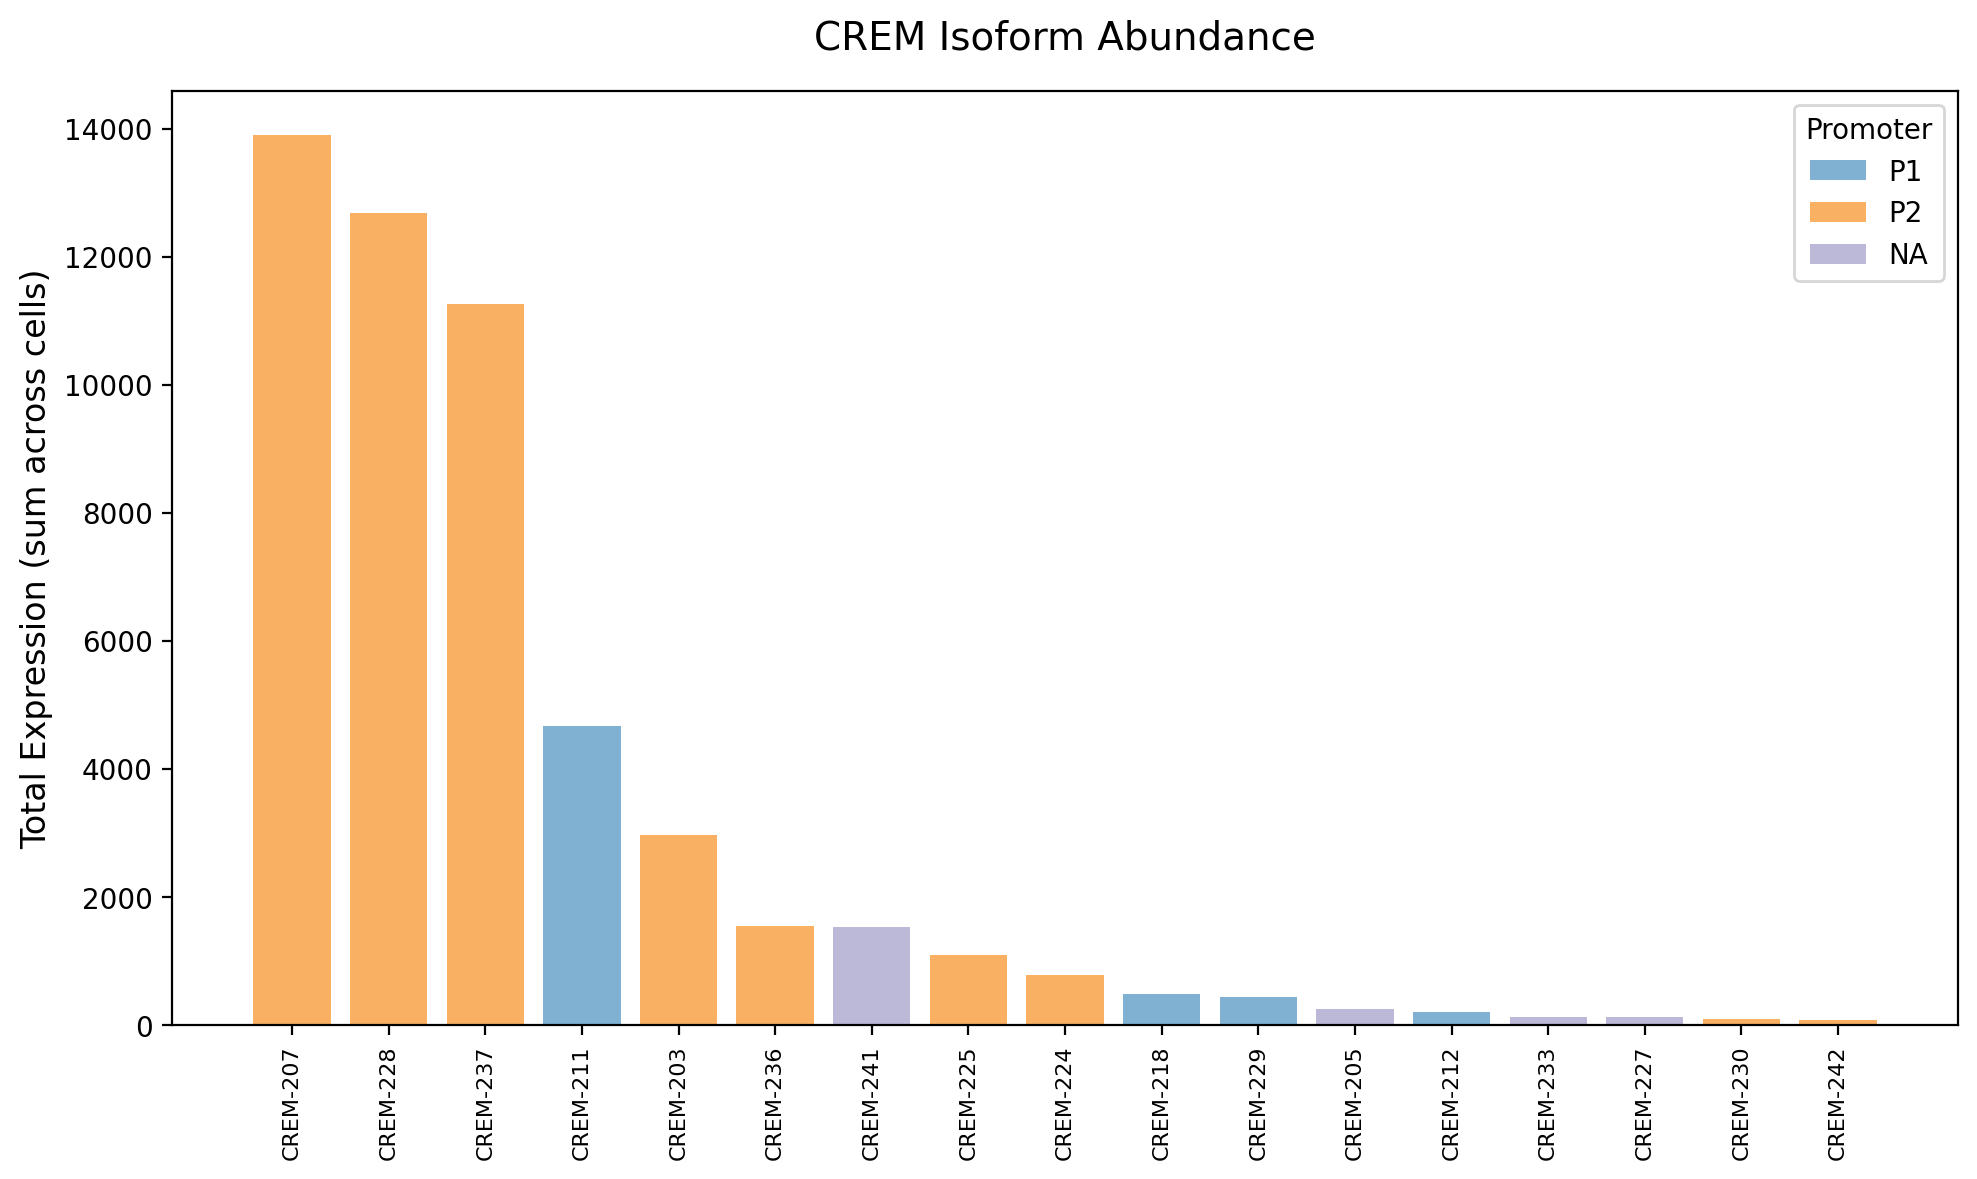

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

group_mapping = {
    # P1 isoforms
    'CREM-211':'P1','CREM-229':'P1','CREM-218':'P1',

    'CREM-204':'P1','CREM-210':'P1','CREM-212':'P1','CREM-240':'P1',
    # P2 isoforms
    'CREM-203':'P2','CREM-207':'P2','CREM-224':'P2','CREM-225':'P2','CREM-228':'P2','CREM-230':'P2','CREM-236':'P2',


    'CREM-237':'P2','CREM-242':'P2',
    # NA isoforms
    'CREM-205':'NA','CREM-217':'NA','CREM-227':'NA','CREM-233':'NA',

    'CREM-241':'NA'
}
color_mapping = {
    'P1': '#80B1D2',
    'P2': '#F9B063',
    'NA': '#BCB9D8'
}

data = list(zip(arranged_features, total_expression))
data = [(name, expr) for name, expr in data if name in group_mapping]


data_sorted = sorted(data, key=lambda x: x[1], reverse=True)
isoforms_sorted, expr_sorted = zip(*data_sorted)

bar_colors = [ color_mapping[group_mapping.get(name, 'NA')] for name in isoforms_sorted ]

plt.figure(figsize=(10, 6))
bars = plt.bar(
    x=np.arange(len(isoforms_sorted)),
    height=expr_sorted,
    color=bar_colors
)

plt.xticks(
    ticks=np.arange(len(isoforms_sorted)),
    labels=isoforms_sorted,
    rotation=90,
    fontsize=8
)

plt.ylabel('Total Expression (sum across cells)', fontsize=12)
plt.title('CREM Isoform Abundance', fontsize=14, pad=15)
plt.tight_layout()

legend_handles = [
    Patch(facecolor=color_mapping[grp], label=grp)
    for grp in ['P1','P2','NA']
]
plt.legend(
    handles=legend_handles,
    title='Promoter',
    loc='upper right'
)

plt.show()

# Time series

In [27]:
adata_transcript_1 = sc.read_h5ad('./20230222_new/transcript_raw_8fc.h5ad')
new_matrix_1 = SCORED(
    adata_tr   = adata_transcript_1,
    adata_g = adata_gene_1,
    condition_key = "condition_time"
)
adata_transcript_1.X = new_matrix_1

adata_transcript_1.obs_names = ["20230222_" + s for s in adata_transcript_1.obs_names]



/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/local/lib/python3.12/dist-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 4241 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


In [28]:
moscot_no_pge2 = pd.read_csv('./moscot/moscot_20230222_no_pge2_only_tcm.csv')
moscot_no_pge2 = moscot_no_pge2[moscot_no_pge2['current'].str.startswith('20230222')]

moscot_pge2 = pd.read_csv('./moscot/moscot_20230222_pge2_only_tcm.csv')
moscot_pge2 = moscot_pge2[moscot_pge2['current'].str.startswith('20230222')]

moscot = pd.concat([moscot_no_pge2, moscot_pge2], ignore_index=True)


In [29]:
# 1. Prepare moscot for merging:
moscot['current'] = moscot['current'].astype(str)

# 2. Filter adata_transcript_1
cells_to_keep = moscot['current'].unique()
adata_transcript_1_filtered = adata_transcript_1[
    adata_transcript_1.obs_names.isin(cells_to_keep)
].copy()


crem_features = [
    feature for feature in adata_transcript_1_filtered.var_names
    if feature.startswith("CREM-")
]

if not crem_features:
    print("Warning: No features starting with 'CREM-' found in adata_transcript_1_filtered.var_names")
else:
    crem_expression_df = adata_transcript_1_filtered[:, crem_features].to_df()

    crem_expression_df.index.name = 'current'

    moscot = pd.merge(
        moscot,
        crem_expression_df,
        left_on='current',  # Column in moscot
        right_index=True,   # Index of crem_expression_df
        how='left'          # Keep all rows from moscot
    )


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _prep_df(moscot, feature, adata=None, dedup_current=False):
    if adata is None:
        df = moscot.copy()
    else:
        meta = adata.obs[['condition_time']].copy()
        meta.index.name = 'current'
        meta = meta.reset_index()
        df = moscot.merge(meta, on='current', how='inner')
    if dedup_current:
        df = df.sort_values('current').drop_duplicates('current', keep='first')
    return df.dropna(subset=[feature]).copy()

def _within_group_percentile_curves(df, feature, q=20, win=5, tcm_label='CD4+ Tcm',
                                    tie_method='first', jitter=None, random_state=0):
    sub = df.dropna(subset=[feature]).copy()
    s = sub[feature].astype(float).copy()

    if jitter is not None and jitter > 0:
        rng = np.random.default_rng(random_state)
        s = s + rng.normal(0, jitter, size=len(s))

    r = s.rank(method=tie_method, pct=True)

    sub['bin'] = pd.cut(r, bins=np.linspace(0, 1, q + 1),
                        labels=False, include_lowest=True, right=True)

    idx = pd.Index(range(q), name='bin')
    mean_by_bin = sub.groupby('bin')[feature].mean().reindex(idx)
    prop_by_bin = ((sub['future_celltype'] != tcm_label)
                   .groupby(sub['bin']).mean().reindex(idx))

    mean_by_bin = mean_by_bin.interpolate(limit_direction='both')
    prop_by_bin = prop_by_bin.interpolate(limit_direction='both')

    mean_sm = mean_by_bin.rolling(win, center=True, min_periods=1).mean()
    prop_sm = prop_by_bin.rolling(win, center=True, min_periods=1).mean()

    scale = 100 / q
    x = np.r_[0, np.arange(1, q + 1) * scale]
    y_blue = np.r_[mean_sm.iloc[0], mean_sm.to_numpy()]
    y_red  = np.r_[prop_sm.iloc[0],  prop_sm.to_numpy()]
    return x, y_blue, y_red

def plot_feature_overall(moscot, feature='CREM-211', q=20, win=1,
                         tcm_label='CD4+ Tcm', adata=None, dedup_current=False, verbose=False):
    df = _prep_df(moscot, feature, adata=adata, dedup_current=dedup_current)
    if verbose:
        print(f"[overall] base non-{tcm_label}: {(df['future_celltype'] != tcm_label).mean():.3f} (n={len(df)})")

    x, y_blue, y_red = _within_group_percentile_curves(df, feature, q, win, tcm_label)

    fig, ax1 = plt.subplots(figsize=(10,6))
    ax1.set_ylim(0, 1)
    (l_red,)  = ax1.plot(x, y_red,  lw=2, color='tab:red',  label='Predicted proportion of 1.5h Tcm cells activating by 12h')
    ax1.set_ylabel('Predicted proportion of 1.5h Tcm cells activating by 12h', color='tab:red'); ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_xlabel(f'{feature} Expression Percentile'); ax1.set_xlim(0, 100)
    ax1.set_xticks(np.arange(0, 101, 5 if q >= 20 else 10)); ax1.grid(True, ls='--', alpha=0.6)

    ax2 = ax1.twinx()
    ax2.set_ylim(0, 10)
    (l_blue,) = ax2.plot(x, y_blue, lw=2, color='tab:blue', label=f'Mean {feature}')
    ax2.set_ylabel(f'Mean {feature}', color='tab:blue'); ax2.tick_params(axis='y', labelcolor='tab:blue')

    ax1.legend(handles=[l_red, l_blue], loc='upper left')
    plt.title(f'Cell Type Composition and Mean {feature} by Percentiles')
    plt.tight_layout(); plt.show()

def plot_feature_split_within(moscot, adata_transcript_1, feature='CREM-211', q=20, win=1,
                              group_regex='PGE2', group_labels=('PGE2+','PGE2-'),
                              tcm_label='CD4+ Tcm', dedup_current=False, verbose=False):
    df = _prep_df(moscot, feature, adata=adata_transcript_1, dedup_current=dedup_current)
    gpos, gneg = group_labels
    df['group'] = np.where(df['condition_time'].str.contains(group_regex, case=False, na=False),
                           gpos, gneg)
    g1, g2 = df['group'].dropna().unique()
    if verbose:
        for g in (g1, g2):
            gbase = (df.loc[df['group']==g, 'future_celltype'] != tcm_label).mean()
            print(f"[{g}] base non-{tcm_label}: {gbase:.3f} (n={len(df[df['group']==g])})")

    x1, yb1, yr1 = _within_group_percentile_curves(df[df['group']==g1], feature, q, win, tcm_label)
    x2, yb2, yr2 = _within_group_percentile_curves(df[df['group']==g2], feature, q, win, tcm_label)

    fig, ax1 = plt.subplots(figsize=(10,6))
    ax1.set_ylim(0, 1)
    l1, = ax1.plot(x1, yr1, lw=2, color='tab:red', label=f'{g1}: Predicted proportion of 1.5h Tcm cells activating by 12h (within-group)')
    l2, = ax1.plot(x2, yr2, lw=2, color='tab:red', ls='--', label=f'{g2}: Predicted proportion of 1.5h Tcm cells activating by 12h (within-group)')
    ax1.set_ylabel('Predicted proportion of 1.5h Tcm cells activating by 12h', color='tab:red'); ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_xlabel('Percentile'); ax1.set_xlim(0, 100)
    ax1.set_xticks(np.arange(0, 101, 5 if q >= 20 else 10)); ax1.grid(True, ls='--', alpha=0.6)

    ax2 = ax1.twinx()
    ax2.set_ylim(0, 10)
    l3, = ax2.plot(x1, yb1, lw=2, color='tab:blue', label=f'{g1}: Mean {feature} (within-group)')
    l4, = ax2.plot(x2, yb2, lw=2, color='tab:blue', ls='--', label=f'{g2}: Mean {feature} (within-group)')
    ax2.set_ylabel(f'Mean {feature}', color='tab:blue'); ax2.tick_params(axis='y', labelcolor='tab:blue')

    ax1.legend(handles=[l1,l2,l3,l4], loc='upper left')
    plt.title(f'Composition and Mean {feature} (both on within-group percentiles)')
    plt.tight_layout(); plt.show()


[overall] base non-CD4+ Tcm: 0.509 (n=2417)


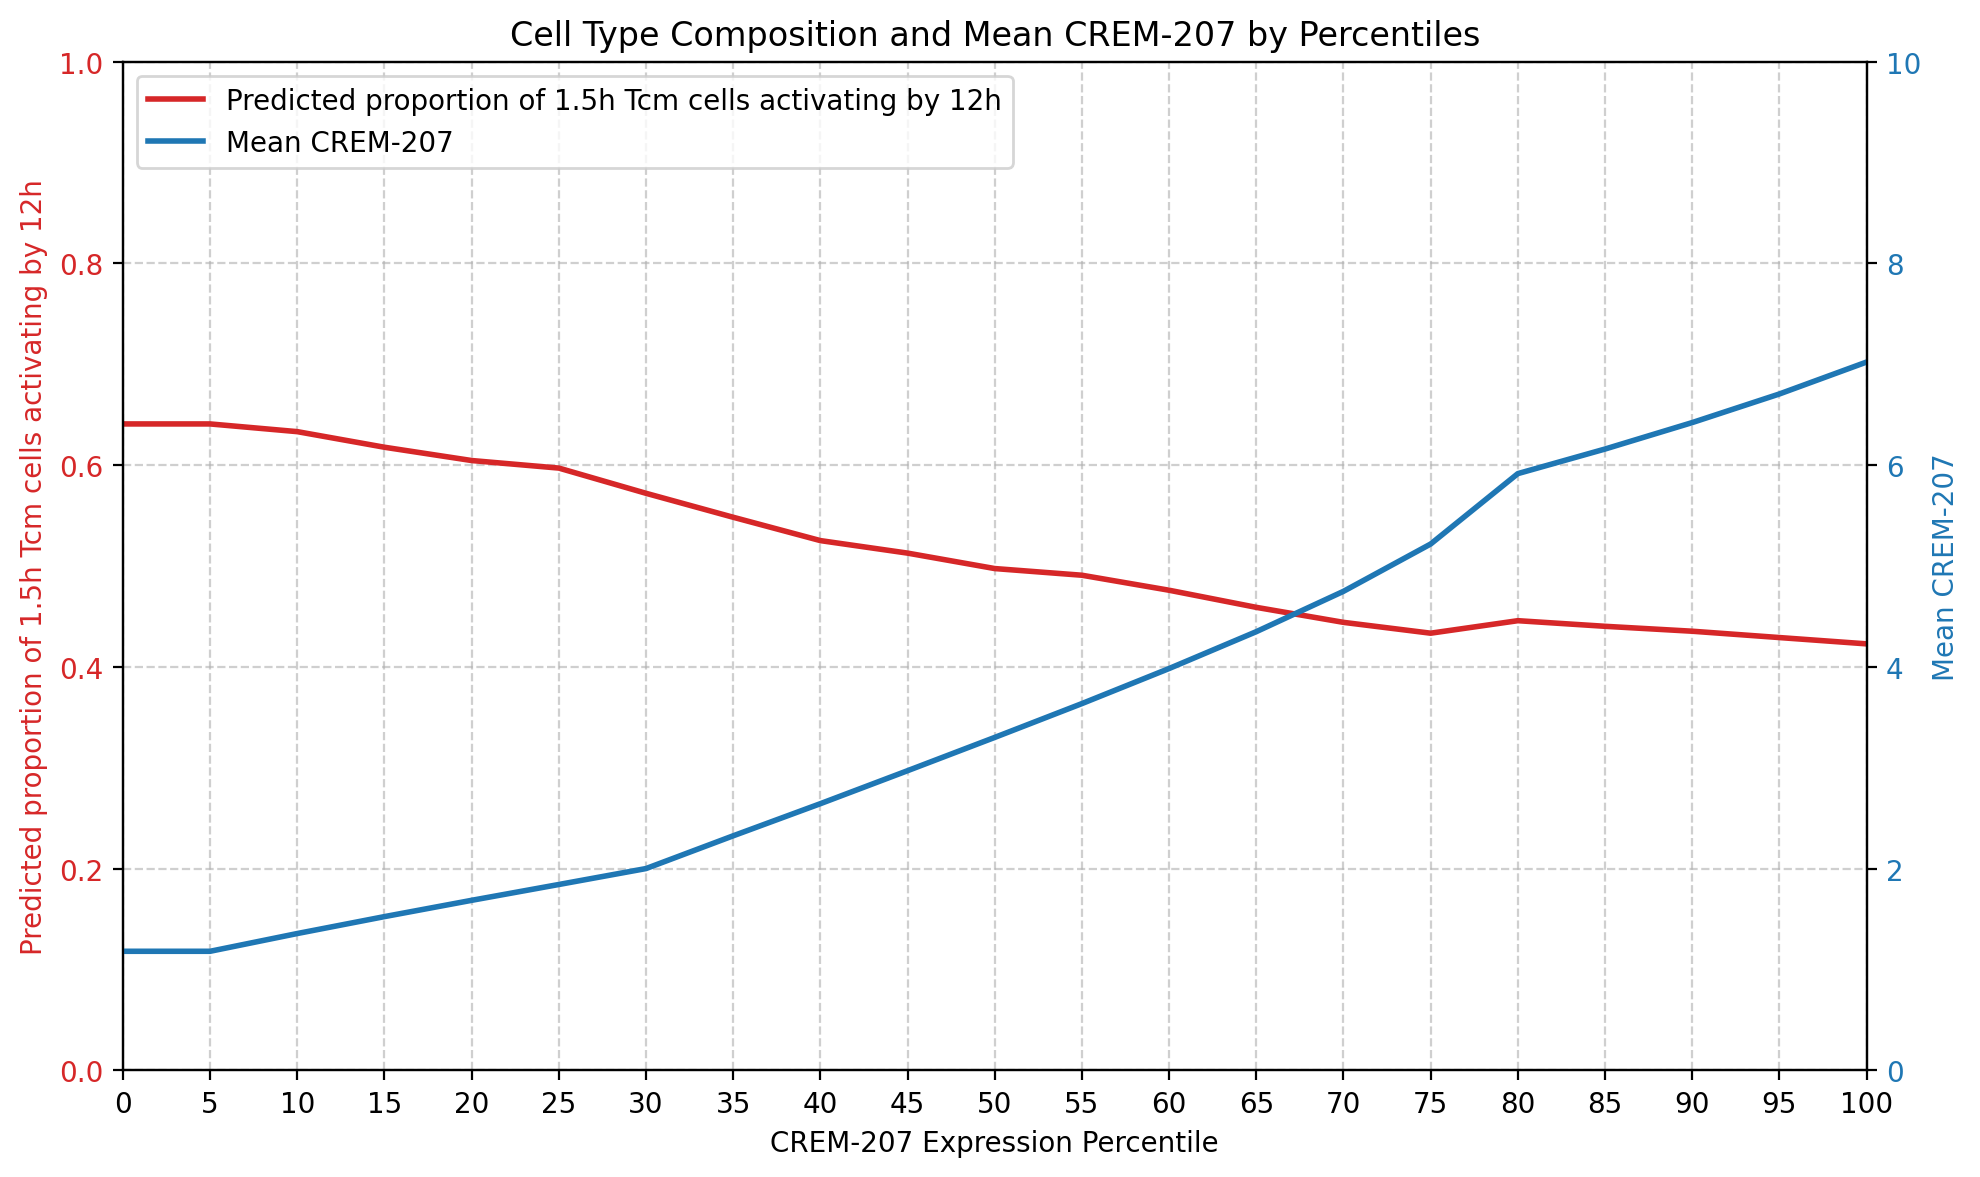

[overall] base non-CD4+ Tcm: 0.509 (n=2417)


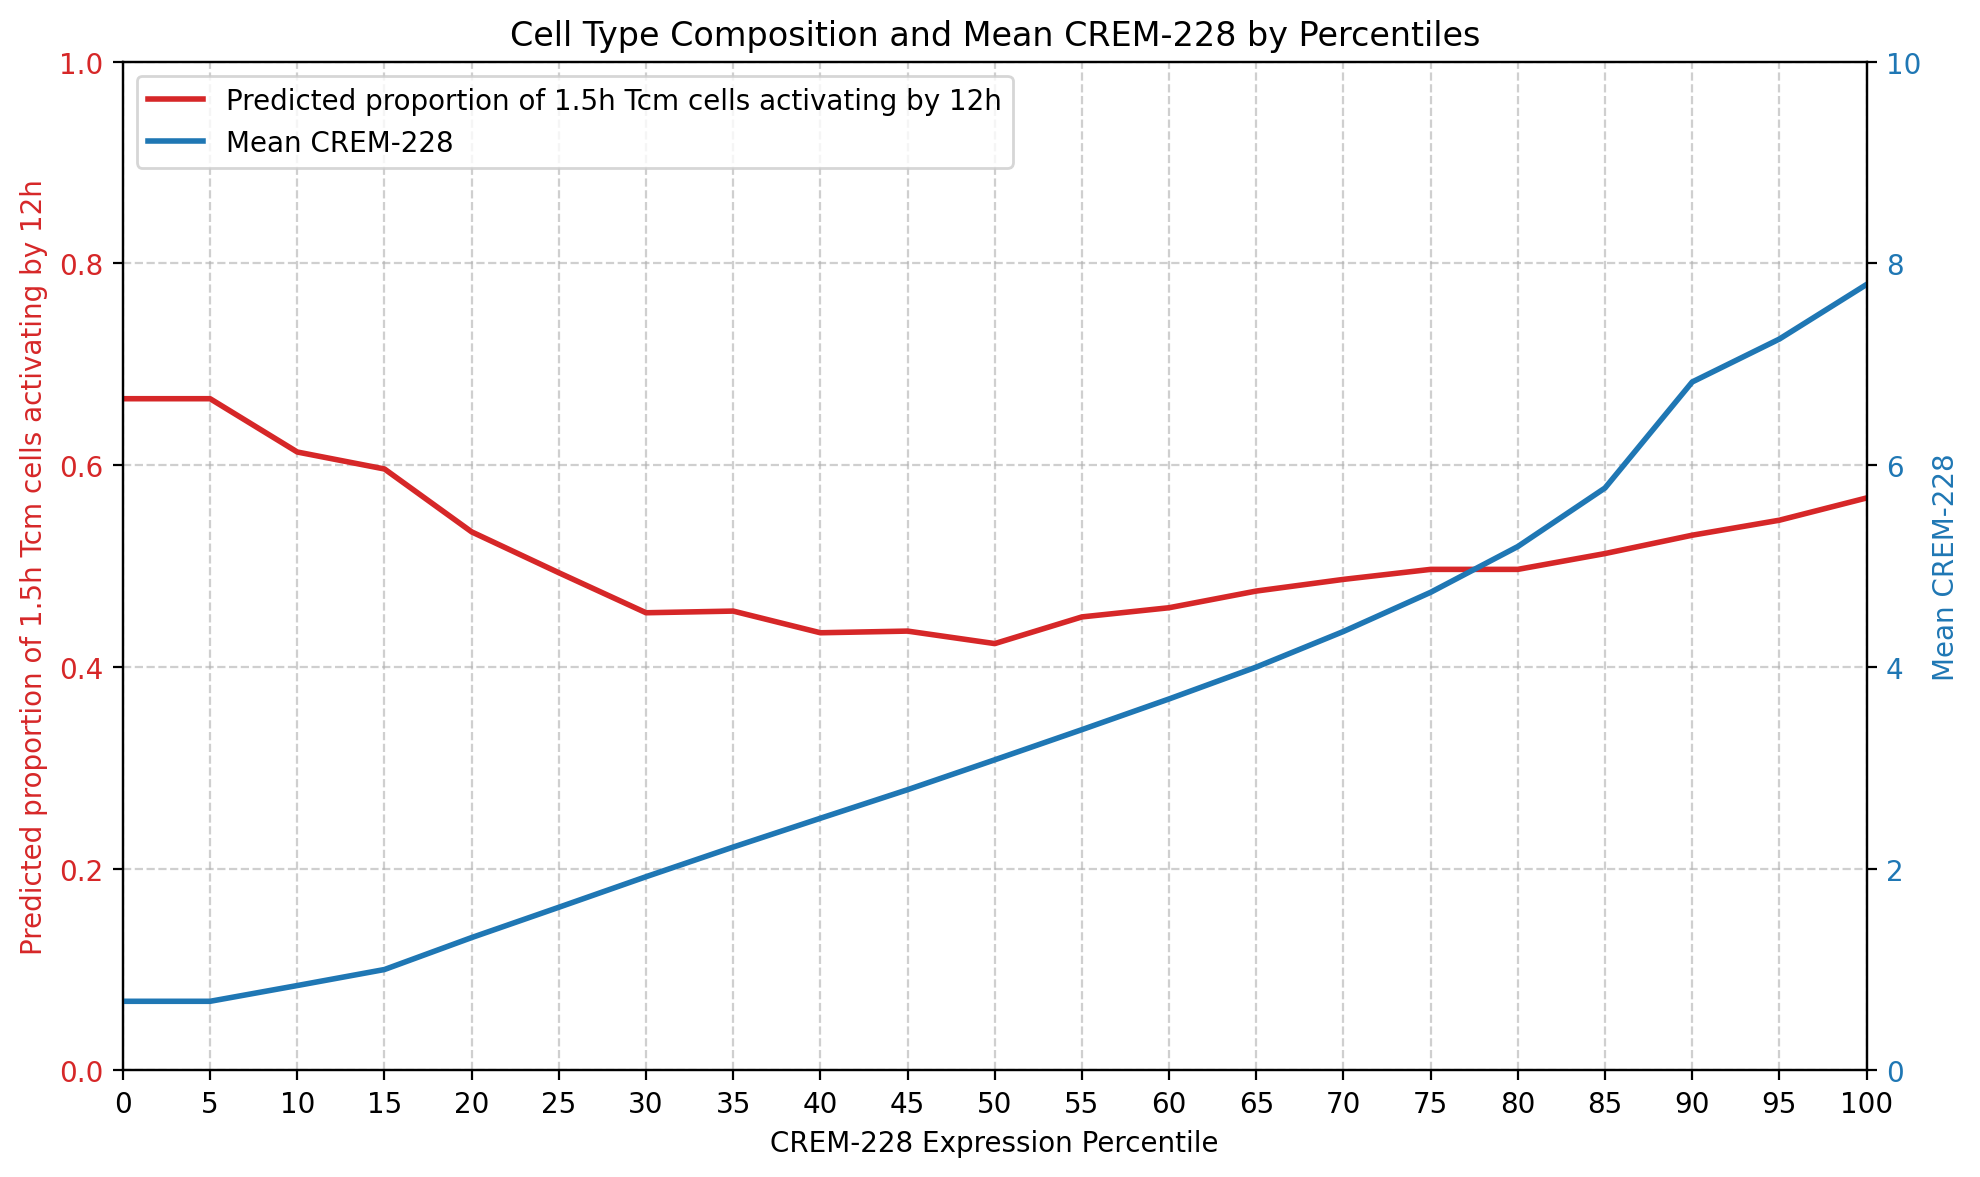

[overall] base non-CD4+ Tcm: 0.509 (n=2417)


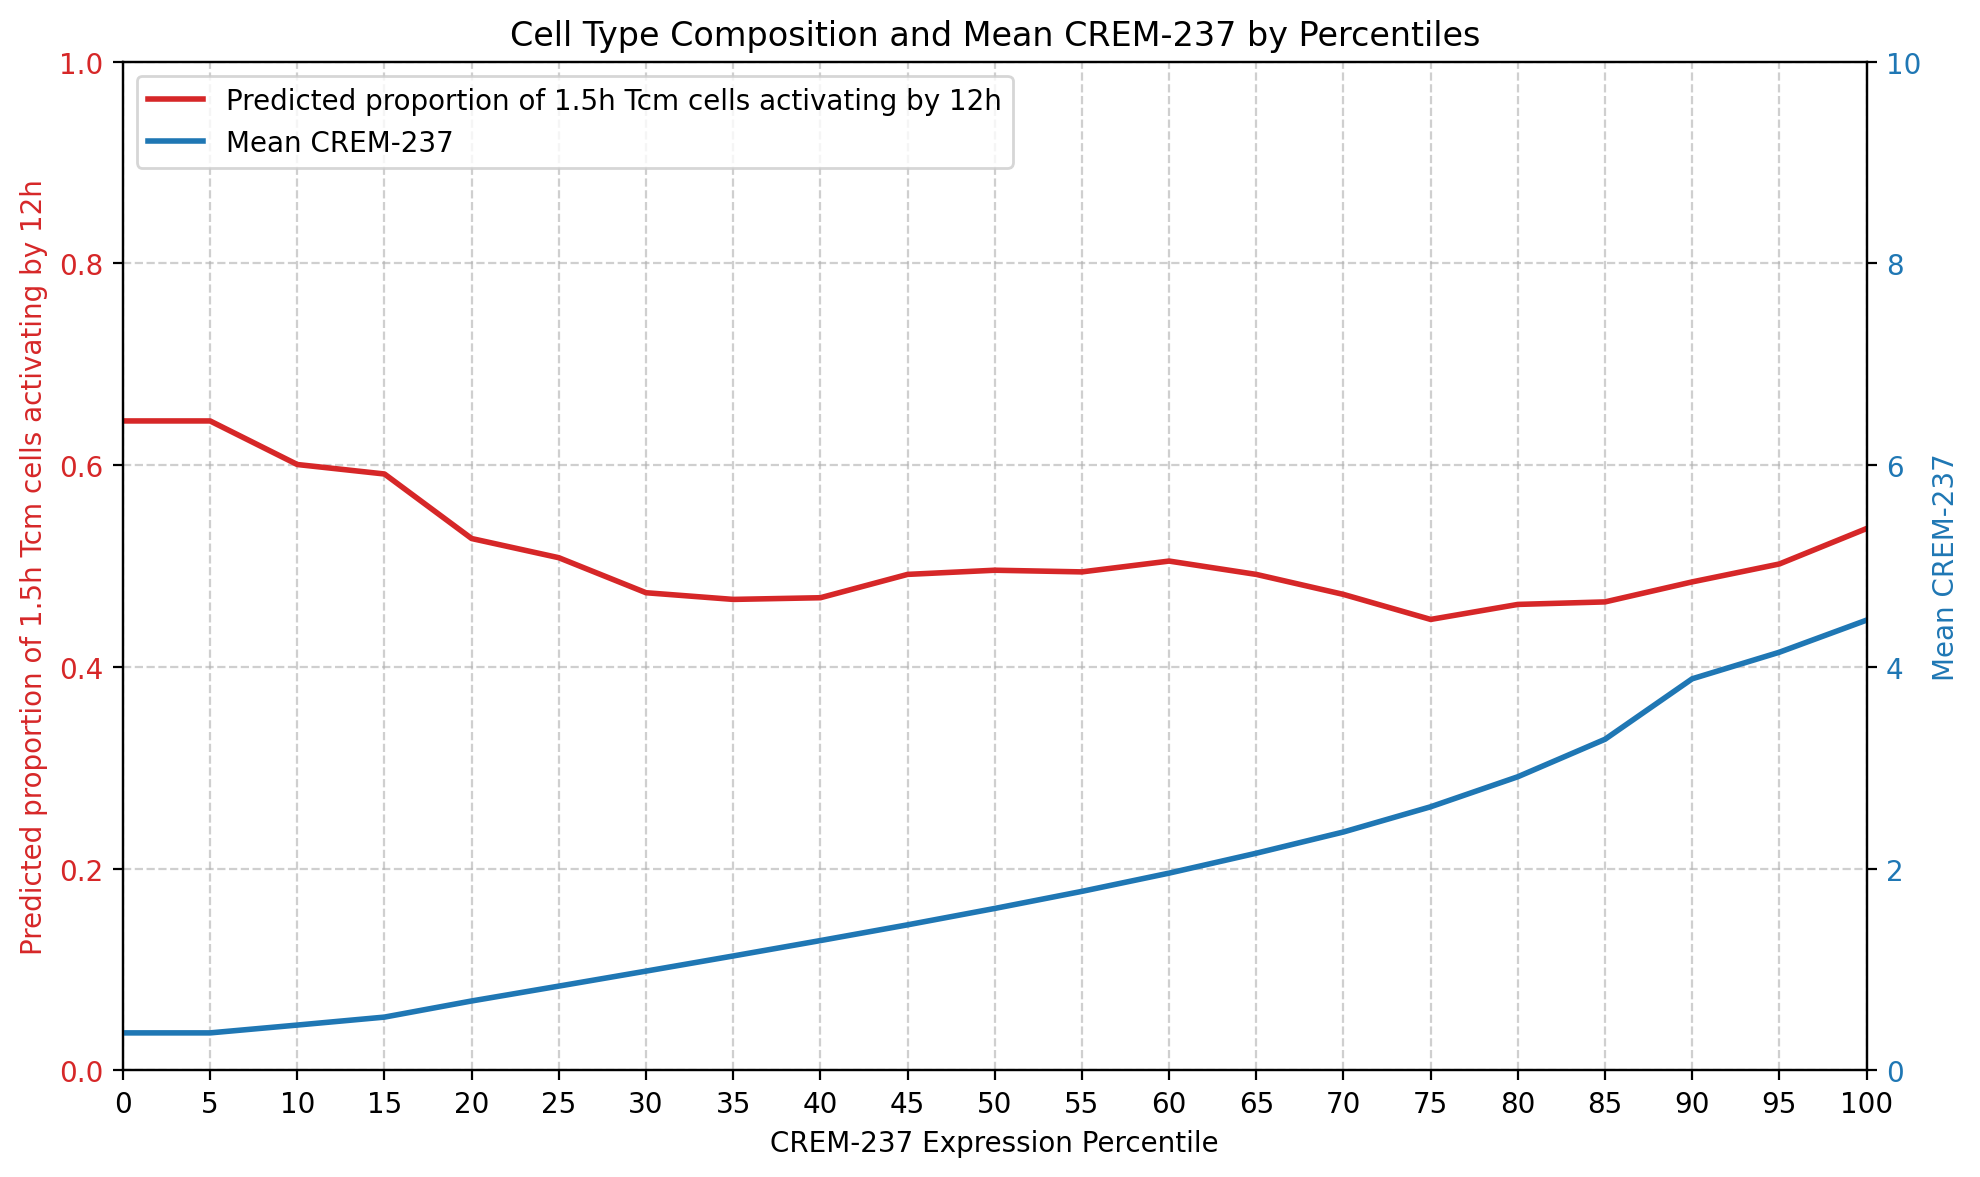

[overall] base non-CD4+ Tcm: 0.509 (n=2417)


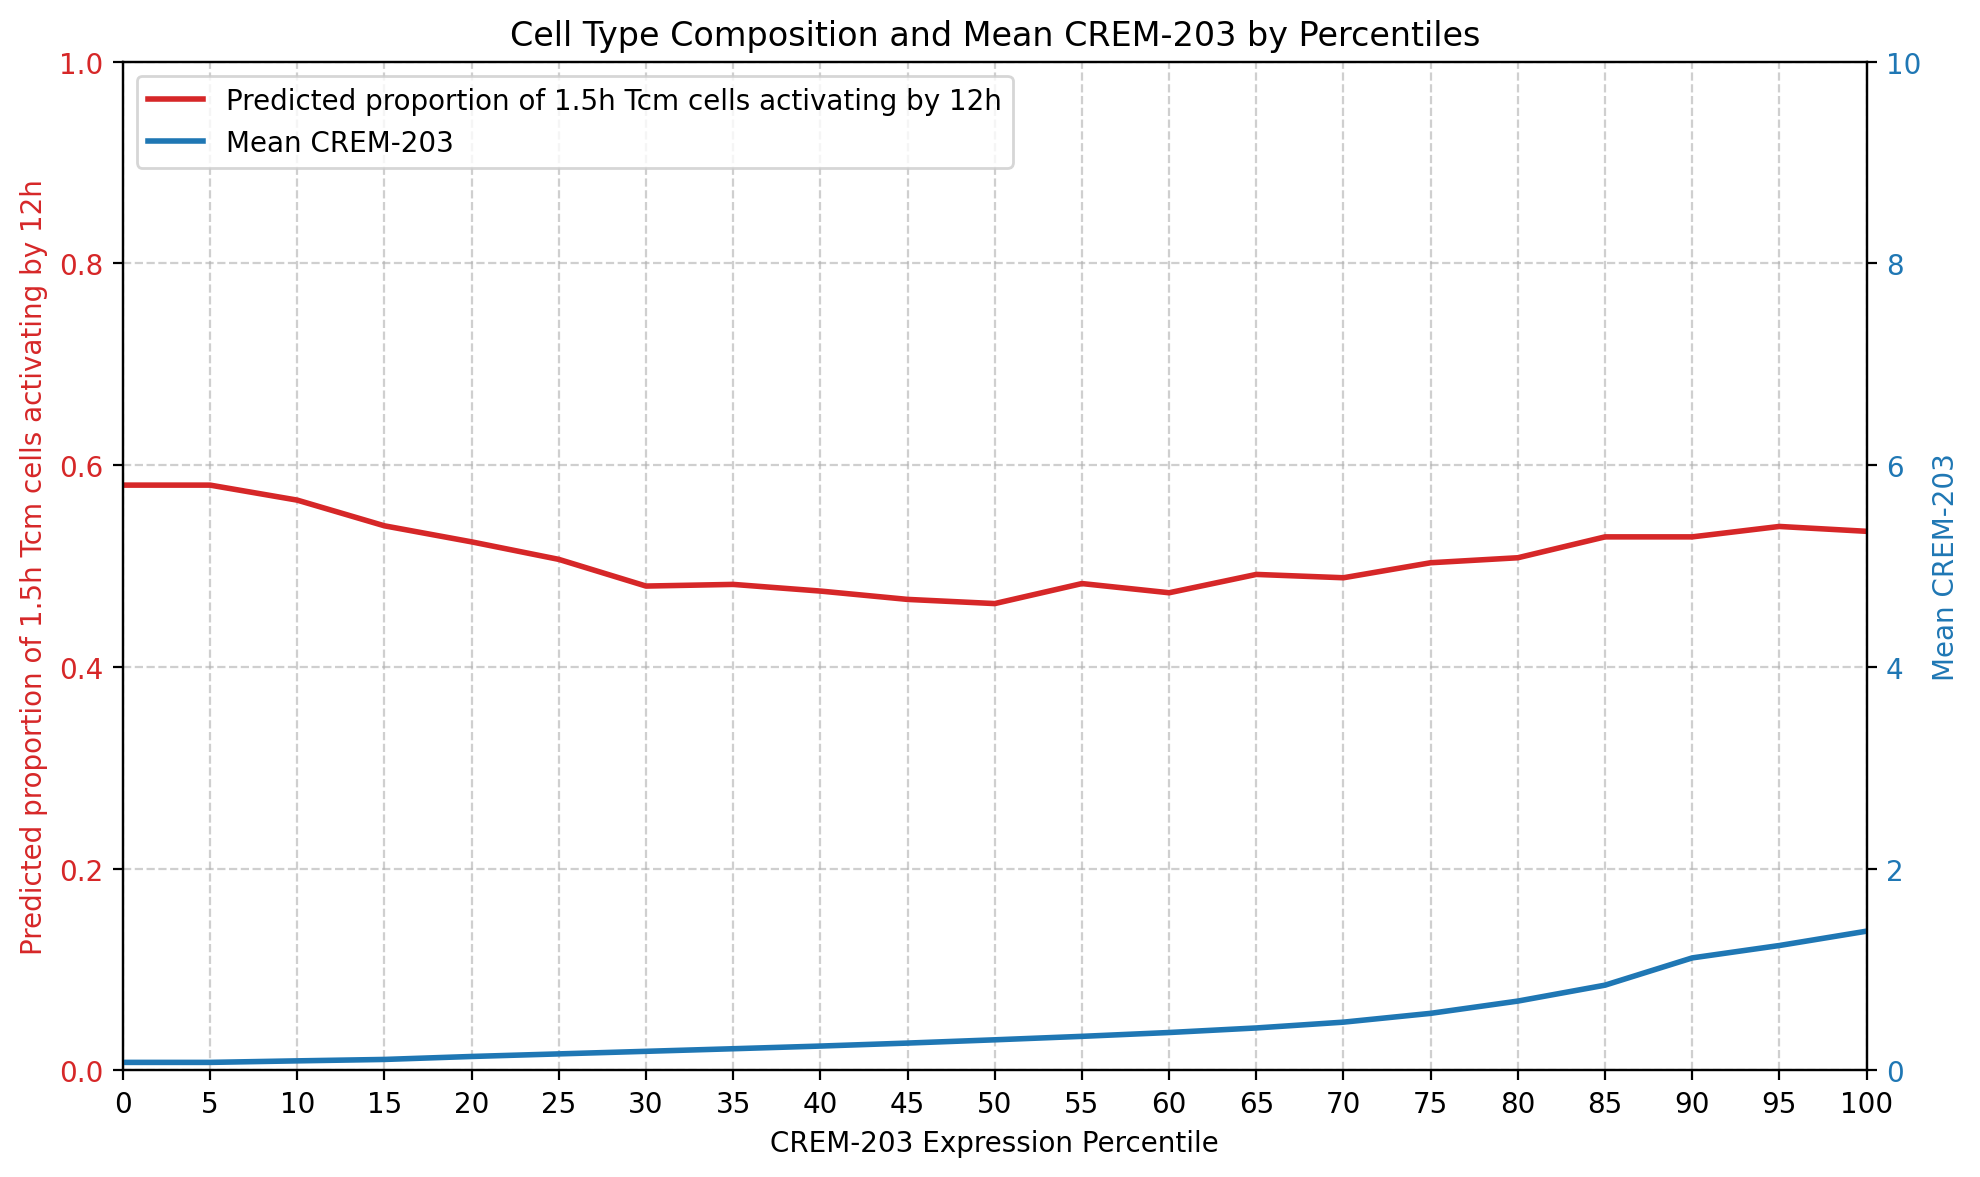

[overall] base non-CD4+ Tcm: 0.509 (n=2417)


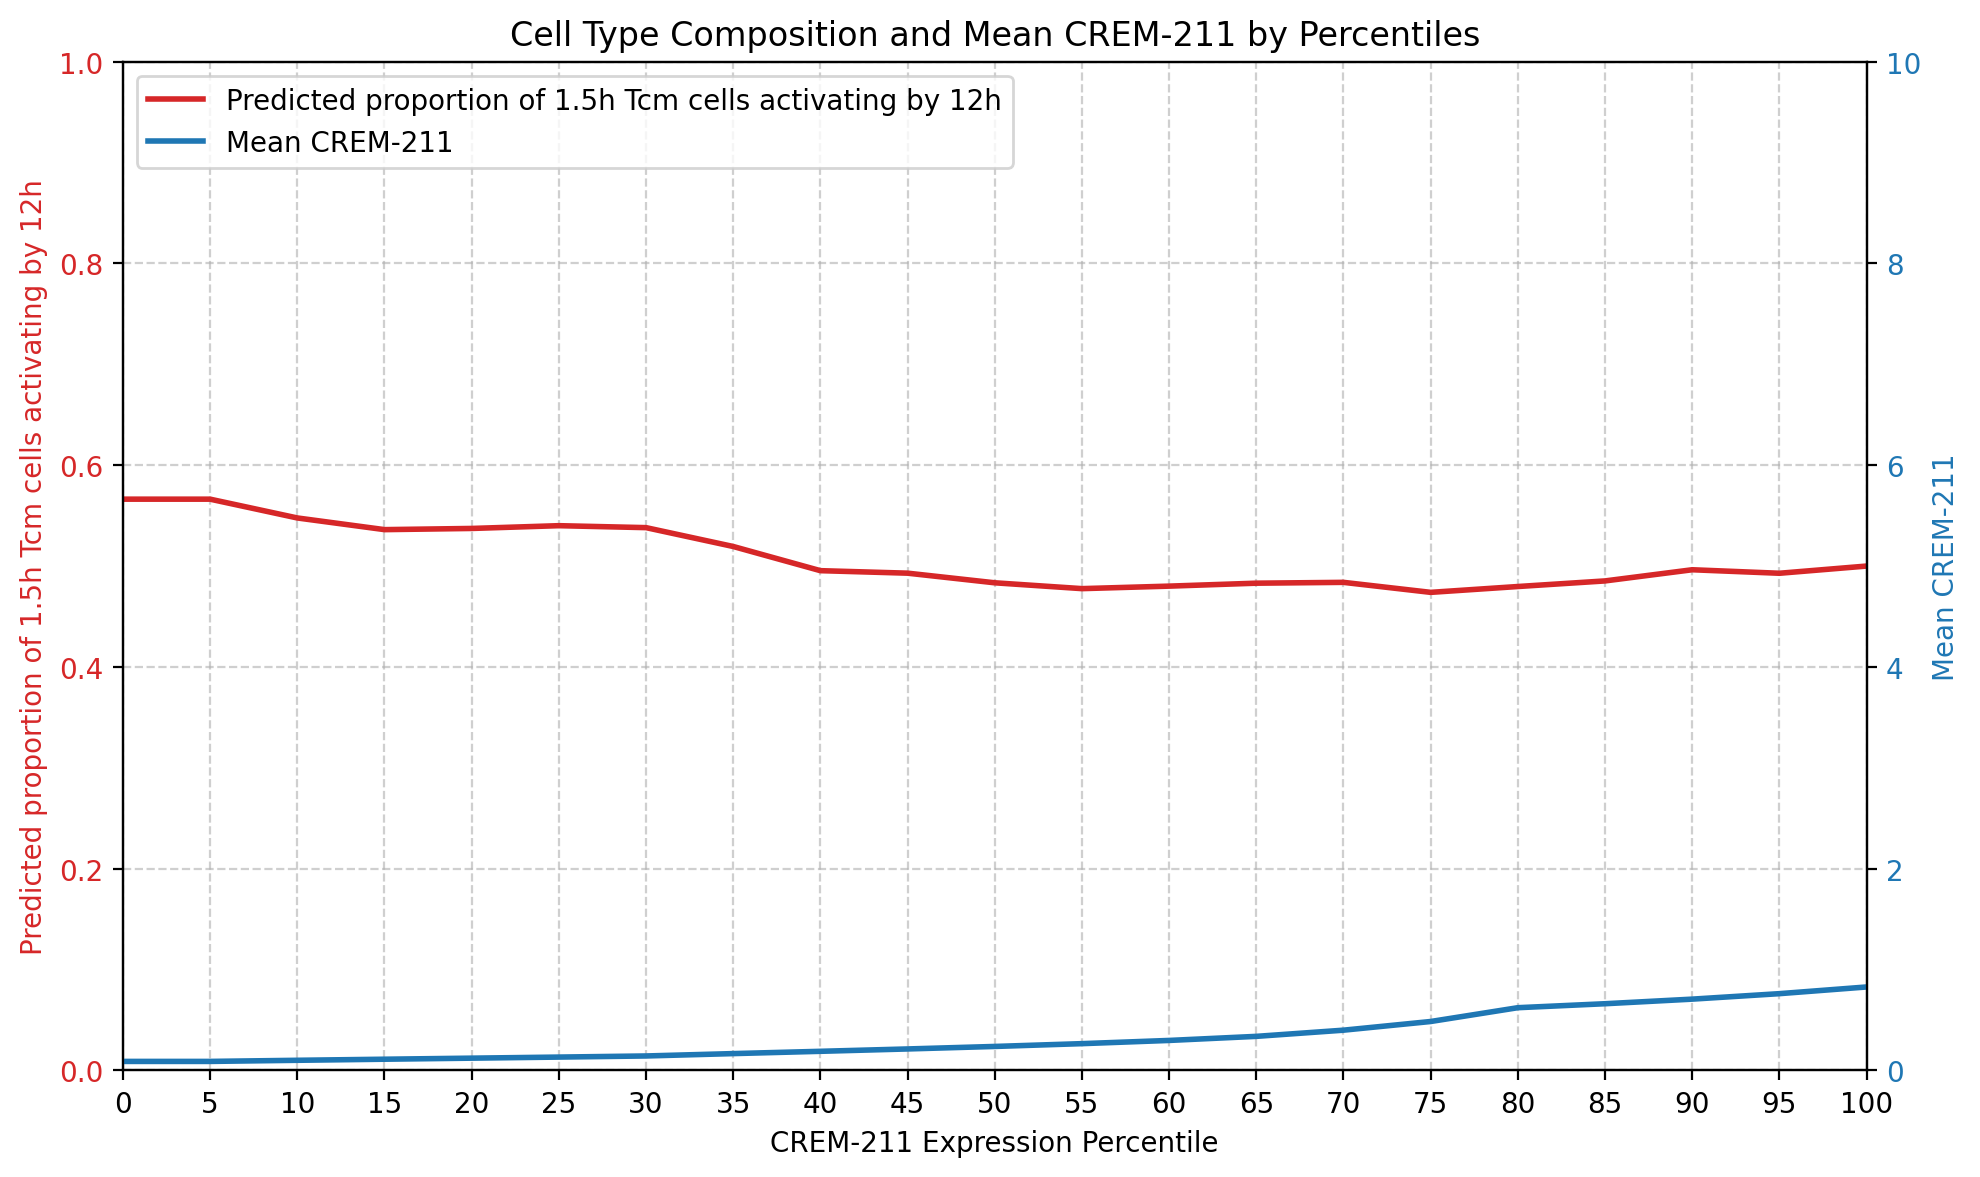

In [31]:
plot_feature_overall(moscot, feature='CREM-207', q=20, win=10, adata=adata_transcript_1,
                      dedup_current=False, verbose=True)


plot_feature_overall(moscot, feature='CREM-228', q=20, win=5, adata=adata_transcript_1,
                      dedup_current=False, verbose=True)


plot_feature_overall(moscot, feature='CREM-237', q=20, win=5, adata=adata_transcript_1,
                      dedup_current=False, verbose=True)


plot_feature_overall(moscot, feature='CREM-203', q=20, win=5, adata=adata_transcript_1,
                      dedup_current=False, verbose=True)


plot_feature_overall(moscot, feature='CREM-211', q=20, win=10, adata=adata_transcript_1,
                      dedup_current=False, verbose=True)


[overall] base non-CD4+ Tcm: 0.509 (n=2417)


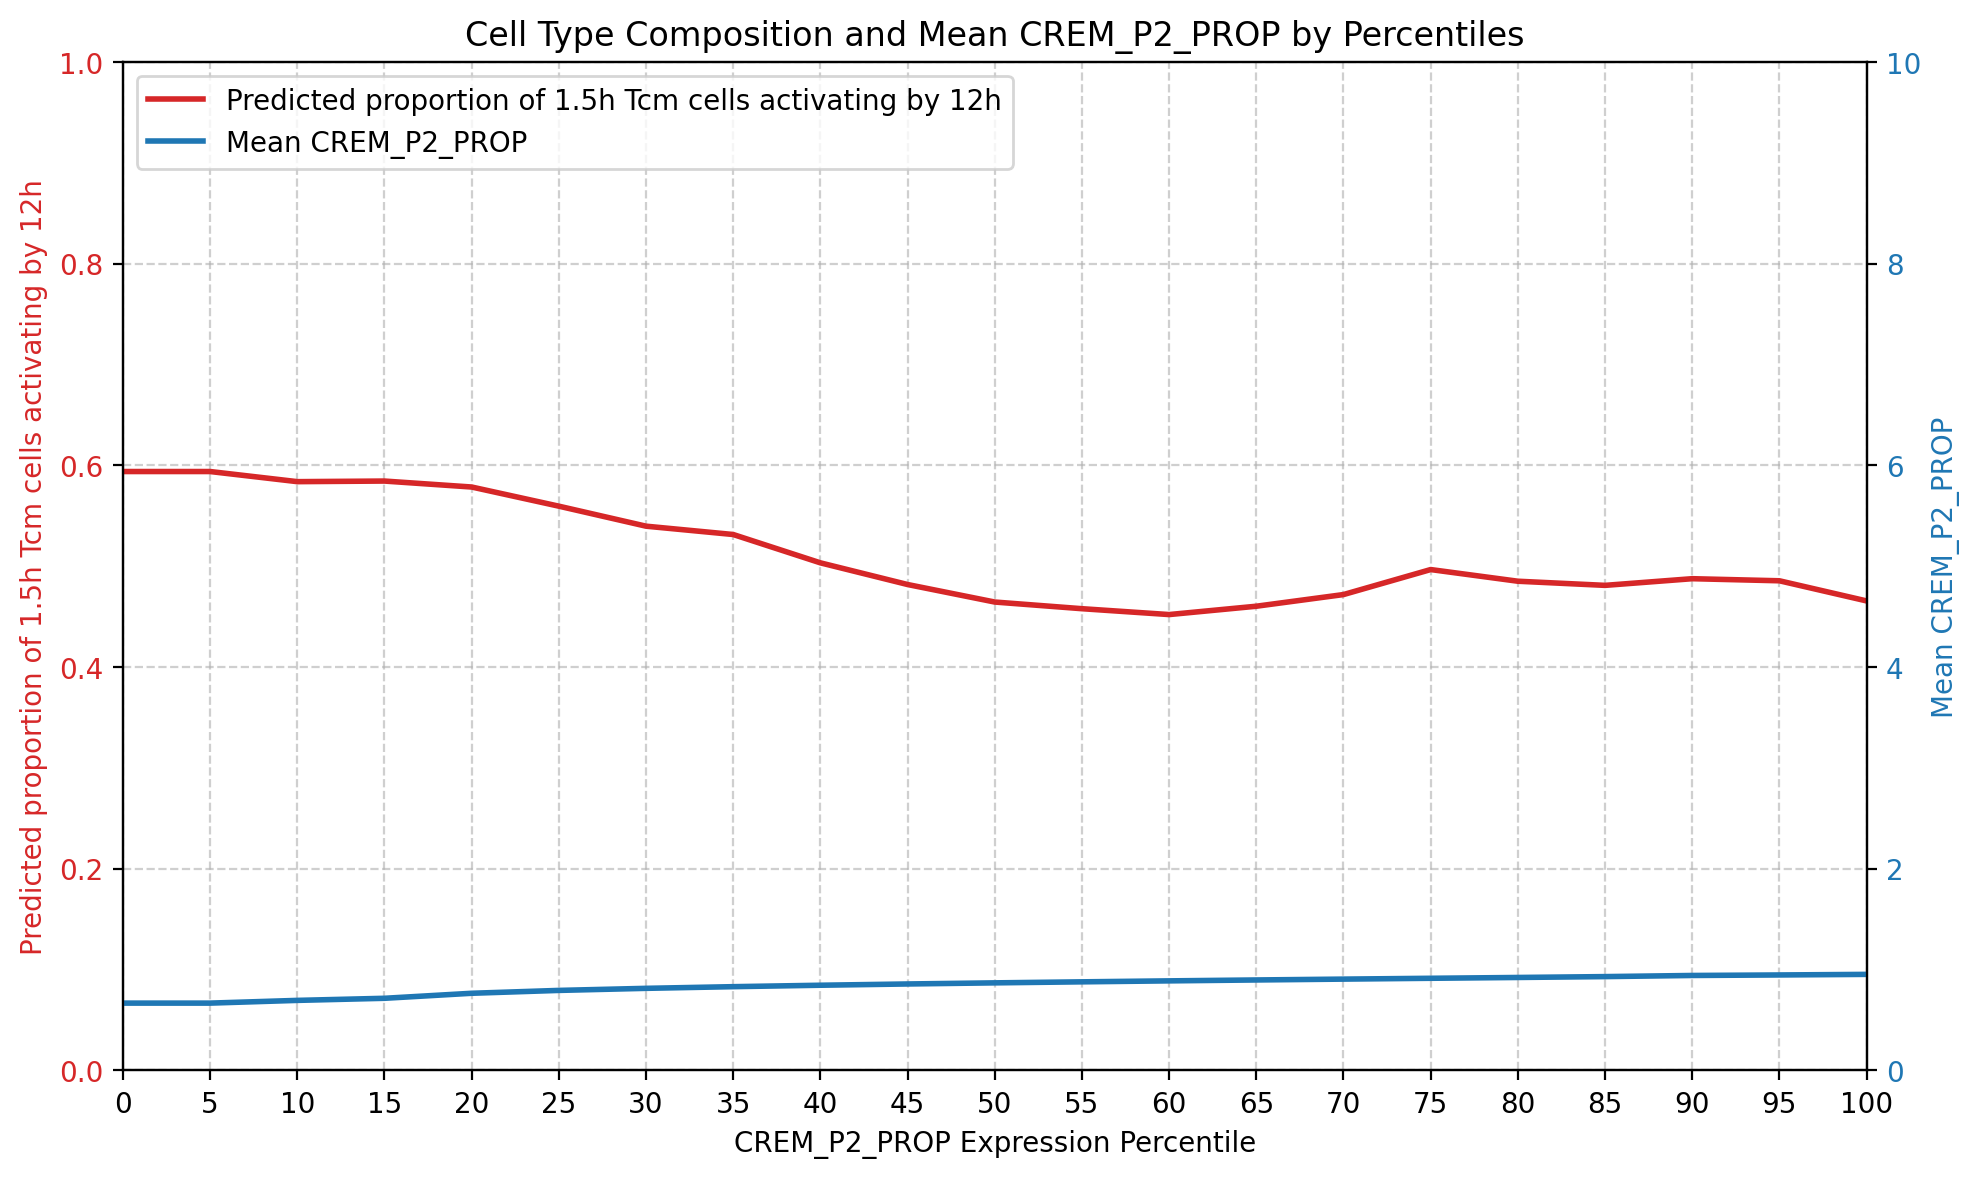

In [32]:
# --- 1) Define CREM isoform groups ---
CREM_P1 = ['CREM-204','CREM-210','CREM-211','CREM-212','CREM-218','CREM-229','CREM-240']  # P1
CREM_P2 = ['CREM-203','CREM-207','CREM-224','CREM-225','CREM-228','CREM-230','CREM-236','CREM-237','CREM-238','CREM-242']  # P2
CREM_NA = ['CREM-205','CREM-208','CREM-209','CREM-217','CREM-226','CREM-227','CREM-233','CREM-239','CREM-241','CREM-247','CREM-248']  # NA

# --- 2) Compute per-cell CREM P2 proportion from AnnData ---
import numpy as np
from scipy import sparse

def _safe_sum_cols(adata, names):
    """Sum expression across a list of feature names; returns 1D np.array of length n_obs."""
    keep = [g for g in names if g in adata.var_names]
    if not keep:
        return np.zeros(adata.n_obs, dtype=float)
    X = adata[:, keep].X
    if sparse.issparse(X):
        return np.asarray(X.sum(axis=1)).ravel()
    return np.asarray(X.sum(axis=1)).ravel()

def compute_crem_p2_prop(adata, p1_names, p2_names, na_names):
    p1 = _safe_sum_cols(adata, p1_names)
    p2 = _safe_sum_cols(adata, p2_names)
    na = _safe_sum_cols(adata, na_names)
    total = p1 + p2 + na
    total_safe = np.where(total == 0, 1.0, total)  # avoid divide-by-zero
    return p2 / total_safe  # np.array, length = n_obs

# Example: adata_transcript_1 is your isoform-level AnnData used in plotting
crem_p2_prop = compute_crem_p2_prop(adata_transcript_1, CREM_P1, CREM_P2, CREM_NA)

# --- 3) Attach as a feature column to `moscot` by merging on cell IDs ---
# Your moscot table typically has a column 'current' with cell IDs.
import pandas as pd

crem_df = pd.DataFrame({
    'current': adata_transcript_1.obs_names,
    'CREM_P2_PROP': crem_p2_prop
})

# Merge into moscot (non-destructive; create a new DataFrame for plotting)
moscot_with_crem = moscot.merge(crem_df, on='current', how='left')

# --- 4) Reuse your existing plotting functions ---
# Overall curve of mean per-cell CREM P2 proportion across pseudotime
plot_feature_overall(
    moscot_with_crem,
    feature='CREM_P2_PROP',
    q=20,           # keep your binning as before (adjust if you like)
    win=5,          # smoothing window as you used
    adata=adata_transcript_1,
    dedup_current=False,
    verbose=True
)




# Benchmarking

## MAGIC

In [33]:
adata_transcript_magic = sc.read_h5ad('./20230222_new/transcript_magic_8fc_default.h5ad')
matrix_magic = adata_transcript_magic.X

In [ ]:

activation_top50 = activation.head(2000)["gene"].tolist()
resting_top50    = resting.head(2000)["gene"].tolist()


activation_prefixes = [gene + '-' for gene in activation_top50]
resting_prefixes    = [gene + '-' for gene in resting_top50]


activation_features = adata_transcript_raw_combined.var_names[
    adata_transcript_raw_combined.var_names.str.startswith(tuple(activation_prefixes))
]
resting_features = adata_transcript_raw_combined.var_names[
    adata_transcript_raw_combined.var_names.str.startswith(tuple(resting_prefixes))
]


activation_indices = [adata_transcript_magic.var_names.get_loc(gene) for gene in activation_features]
resting_indices    = [adata_transcript_magic.var_names.get_loc(gene) for gene in resting_features]

n_cells = matrix_new.shape[0]
expr_threshold = 0.1 * n_cells
activation_indices = [idx for idx in activation_indices if (matrix_raw[:, idx] > 0).sum() >= expr_threshold]
resting_indices    = [idx for idx in resting_indices if (matrix_raw[:, idx] > 0).sum() >= expr_threshold]

activation_indices = activation_indices[:50]
resting_indices    = resting_indices[:50]

print(f"Number of Activation features: {len(activation_indices)}")
print(f"Number of Resting features:    {len(resting_indices)}")

matrix1_activation = matrix_magic[:, activation_indices]
matrix1_resting    = matrix_magic[:, resting_indices]


combined_indices = activation_indices + resting_indices

def compute_corr_matrix(matrix):
    return np.corrcoef(matrix, rowvar=False)

corr1_activation = compute_corr_matrix(matrix1_activation)
corr1_resting    = compute_corr_matrix(matrix1_resting)

matrix1_combined = matrix_magic[:, combined_indices]  # FIX: was matrix_new (SCORED), should be matrix_magic for the MAGIC, Pearson benchmark
corr1_combined = compute_corr_matrix(matrix1_combined)
n_act = len(activation_indices)
n_rest = len(resting_indices)
between_corr1 = corr1_combined[:n_act, n_act:].flatten()


def get_within_corr(corr_matrix):
    n = corr_matrix.shape[0]
    iu = np.triu_indices(n, k=1)
    return corr_matrix[iu]

within_corr1_activation = get_within_corr(corr1_activation)
within_corr1_resting    = get_within_corr(corr1_resting)



from scipy.stats import gaussian_kde

def kde_with_capped_median(x, color, label, bw_adjust=1.0):
    ax = plt.gca()
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return

    sns.kdeplot(x, fill=True, lw=2, color=color, label=label, bw_adjust=bw_adjust, ax=ax)

    med = np.median(x)
    try:
        kde = gaussian_kde(x, bw_method=lambda s: s.scotts_factor() * bw_adjust)
        y_med = float(kde.evaluate([med]))
        if not np.isfinite(y_med):
            return
    except Exception:
        return

    ax.vlines(med, 0, y_med, colors=color, linestyles='--', linewidth=1.5, zorder=3)

figsize = (6, 4)
dpi = 300
xlabel_fs = 10
ylabel_fs = 10
title_fs = 14
legend_fs = 10

color_activation = "#F18072"
color_resting    = "#8CD0C3"
color_between    = "#80B1D2"


plt.figure(figsize=figsize, dpi=dpi)
kde_with_capped_median(within_corr1_activation, color_activation, "Activation (within)", bw_adjust=2)
kde_with_capped_median(within_corr1_resting,    color_resting,    "Resting (within)",  bw_adjust=2)
kde_with_capped_median(between_corr1,           color_between,    "Between",           bw_adjust=2)
plt.xlabel("Pearson Correlation", fontsize=xlabel_fs)
plt.ylabel("Density", fontsize=ylabel_fs)
plt.title("Distribution of Pearson Correlations (MAGIC)", fontsize=title_fs)
plt.legend(fontsize=legend_fs)
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.xlim(-1, 1); plt.grid(True); plt.tight_layout(); plt.show()

In [ ]:
def compute_corr_matrix(matrix):
    """
    Computes the Spearman correlation matrix for all columns in `matrix`.
    Each column is treated as a variable, and each row is an observation.
    """
    corr_matrix, _ = spearmanr(matrix, axis=0)
    return corr_matrix

corr1_activation = compute_corr_matrix(matrix1_activation)
corr1_resting    = compute_corr_matrix(matrix1_resting)

matrix1_combined = matrix_magic[:, combined_indices]  # FIX: was matrix_new (SCORED), should be matrix_magic for the MAGIC, Spearman benchmark
corr1_combined   = compute_corr_matrix(matrix1_combined)
n_act = len(activation_indices)
n_rest = len(resting_indices)
between_corr1 = corr1_combined[:n_act, n_act:].flatten()


def get_within_corr(corr_matrix):
    iu = np.triu_indices(corr_matrix.shape[0], k=1)
    return corr_matrix[iu]

within_corr1_activation = get_within_corr(corr1_activation)
within_corr1_resting    = get_within_corr(corr1_resting)
within_corr2_activation = get_within_corr(corr2_activation)
within_corr2_resting    = get_within_corr(corr2_resting)


figsize = (6, 4)
dpi = 300
xlabel_fs = 10
ylabel_fs = 10
title_fs = 14
legend_fs = 10

color_activation = "#F18072"
color_resting    = "#8CD0C3"
color_between    = "#80B1D2"

plt.figure(figsize=figsize, dpi=dpi)
kde_with_capped_median(within_corr1_activation, color_activation, "Activation (within)", bw_adjust=2)
kde_with_capped_median(within_corr1_resting,    color_resting,    "Resting (within)",  bw_adjust=2)
kde_with_capped_median(between_corr1,           color_between,    "Between",           bw_adjust=2)
plt.xlabel("Spearman Correlation", fontsize=xlabel_fs)
plt.ylabel("Density",               fontsize=ylabel_fs)
plt.title("Distribution of Spearman Correlations (MAGIC)", fontsize=title_fs)
plt.legend(fontsize=legend_fs)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlim(-1, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


MAGIC  — ROC-AUC: 0.896 | PR-AUC: 0.929


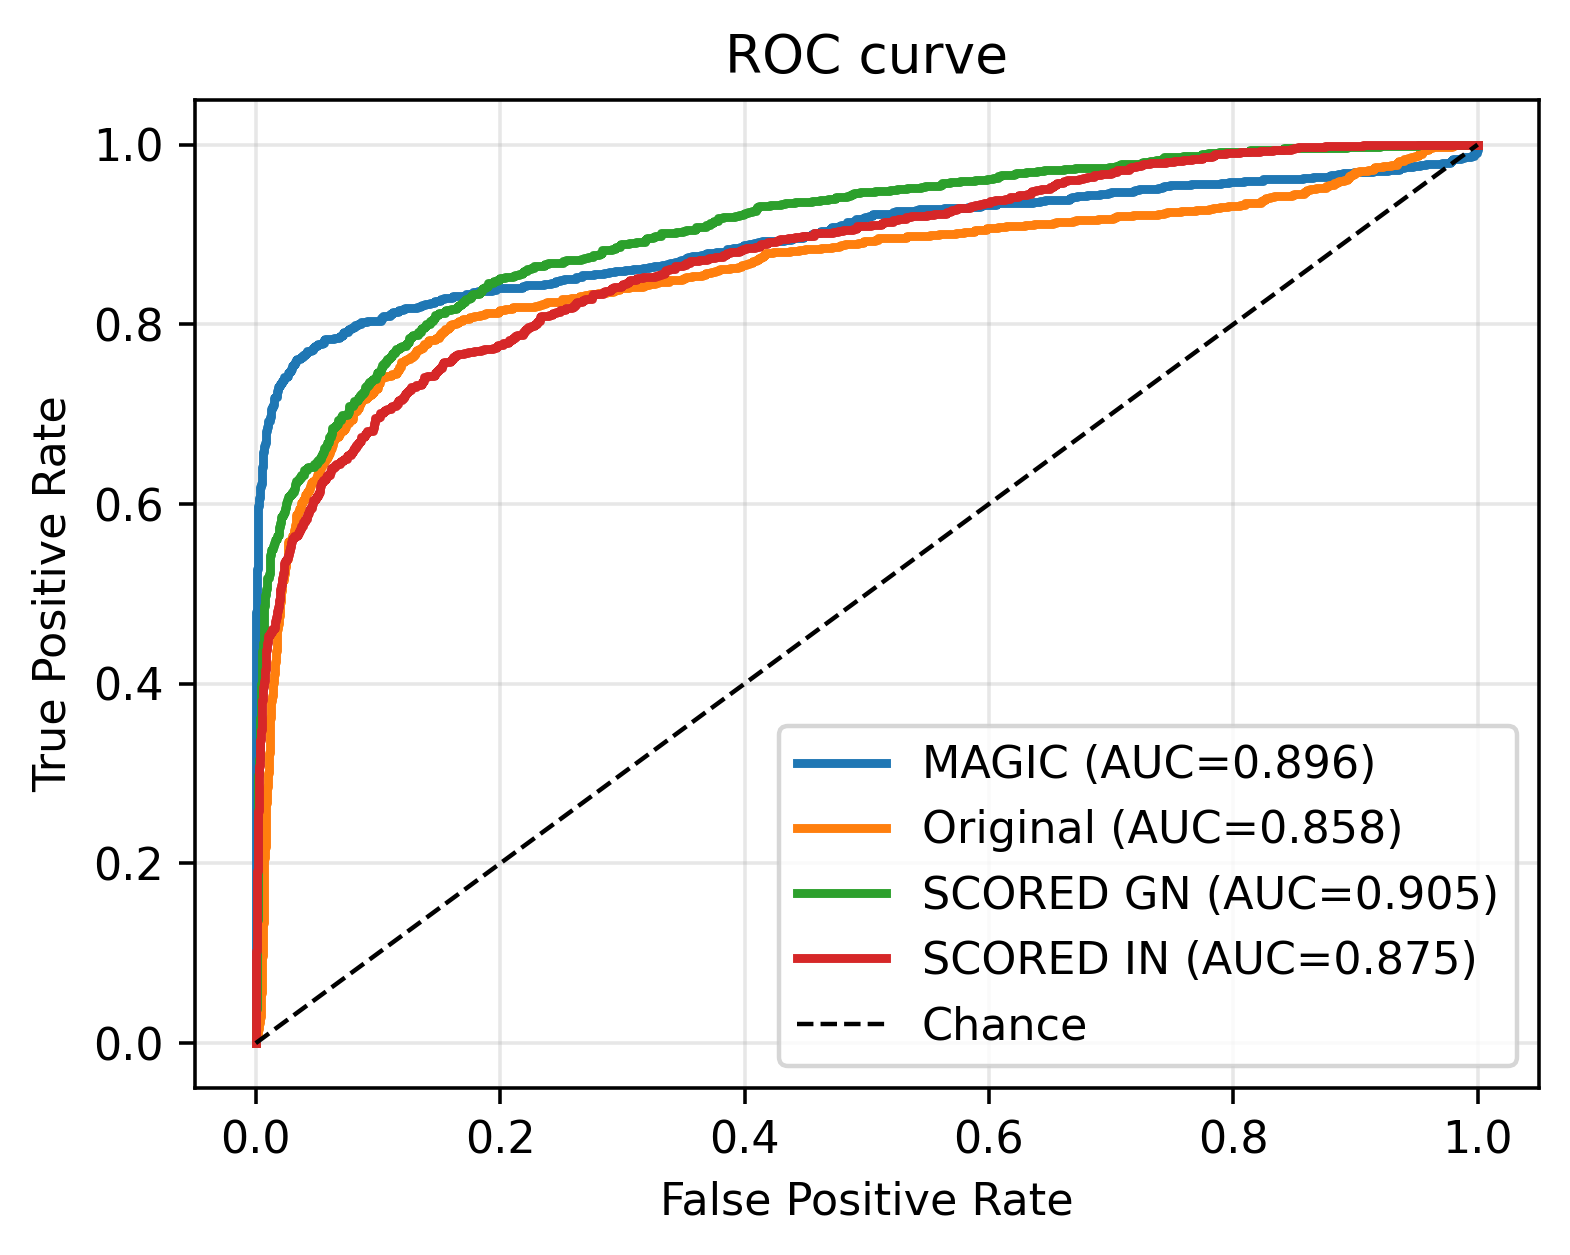

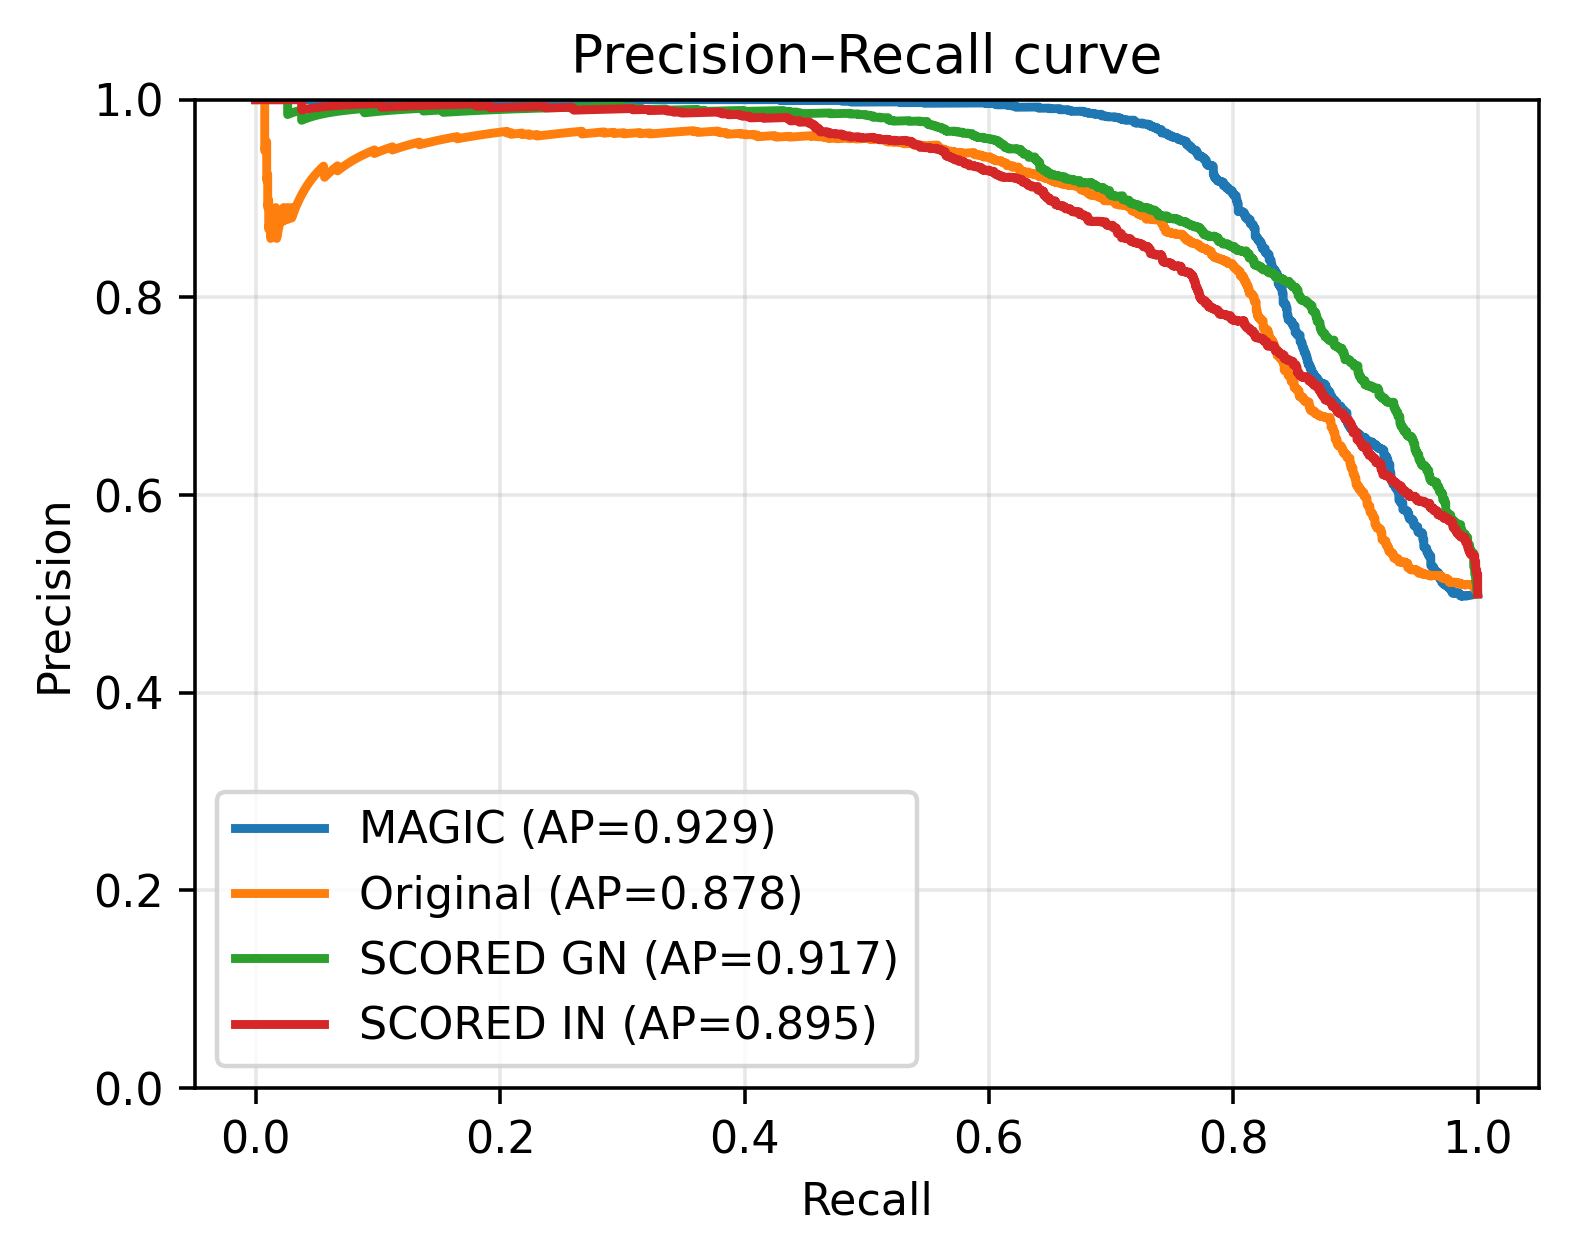

In [36]:

y5, s5 = build_y_scores(within_corr1_activation, between_corr1)
w5 = balanced_weights(y5)
res5 = get_curves(y5, s5, w5)
f5 = f1_at_threshold(y5, s5, thr=0.0, w=w5)




print(f"MAGIC  — ROC-AUC: {res5['roc_auc']:.3f} | PR-AUC: {res5['ap']:.3f}")

plt.figure(figsize=(5,4), dpi=160)
plt.plot(res5["fpr"], res5["tpr"], lw=2, label=f"MAGIC (AUC={res5['roc_auc']:.3f})")
plt.plot(res2["fpr"], res2["tpr"], lw=2, label=f"Original (AUC={res2['roc_auc']:.3f})")
plt.plot(res1["fpr"], res1["tpr"], lw=2, label=f"SCORED GN (AUC={res1['roc_auc']:.3f})")
plt.plot(res1_1["fpr"], res1_1["tpr"], lw=2, label=f"SCORED IN (AUC={res1_1['roc_auc']:.3f})")
plt.plot([0,1], [0,1], "k--", lw=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4), dpi=160)
plt.plot(res5["pr_r"], res5["pr_p"], lw=2, label=f"MAGIC (AP={res5['ap']:.3f})")
plt.plot(res2["pr_r"], res2["pr_p"], lw=2, label=f"Original (AP={res2['ap']:.3f})")
plt.plot(res1["pr_r"], res1["pr_p"], lw=2, label=f"SCORED GN (AP={res1['ap']:.3f})")
plt.plot(res1_1["pr_r"], res1_1["pr_p"], lw=2, label=f"SCORED IN (AP={res1_1['ap']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.legend()
plt.grid(True, alpha=.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

MAGIC  — ROC-AUC: 0.815 | PR-AUC: 0.870


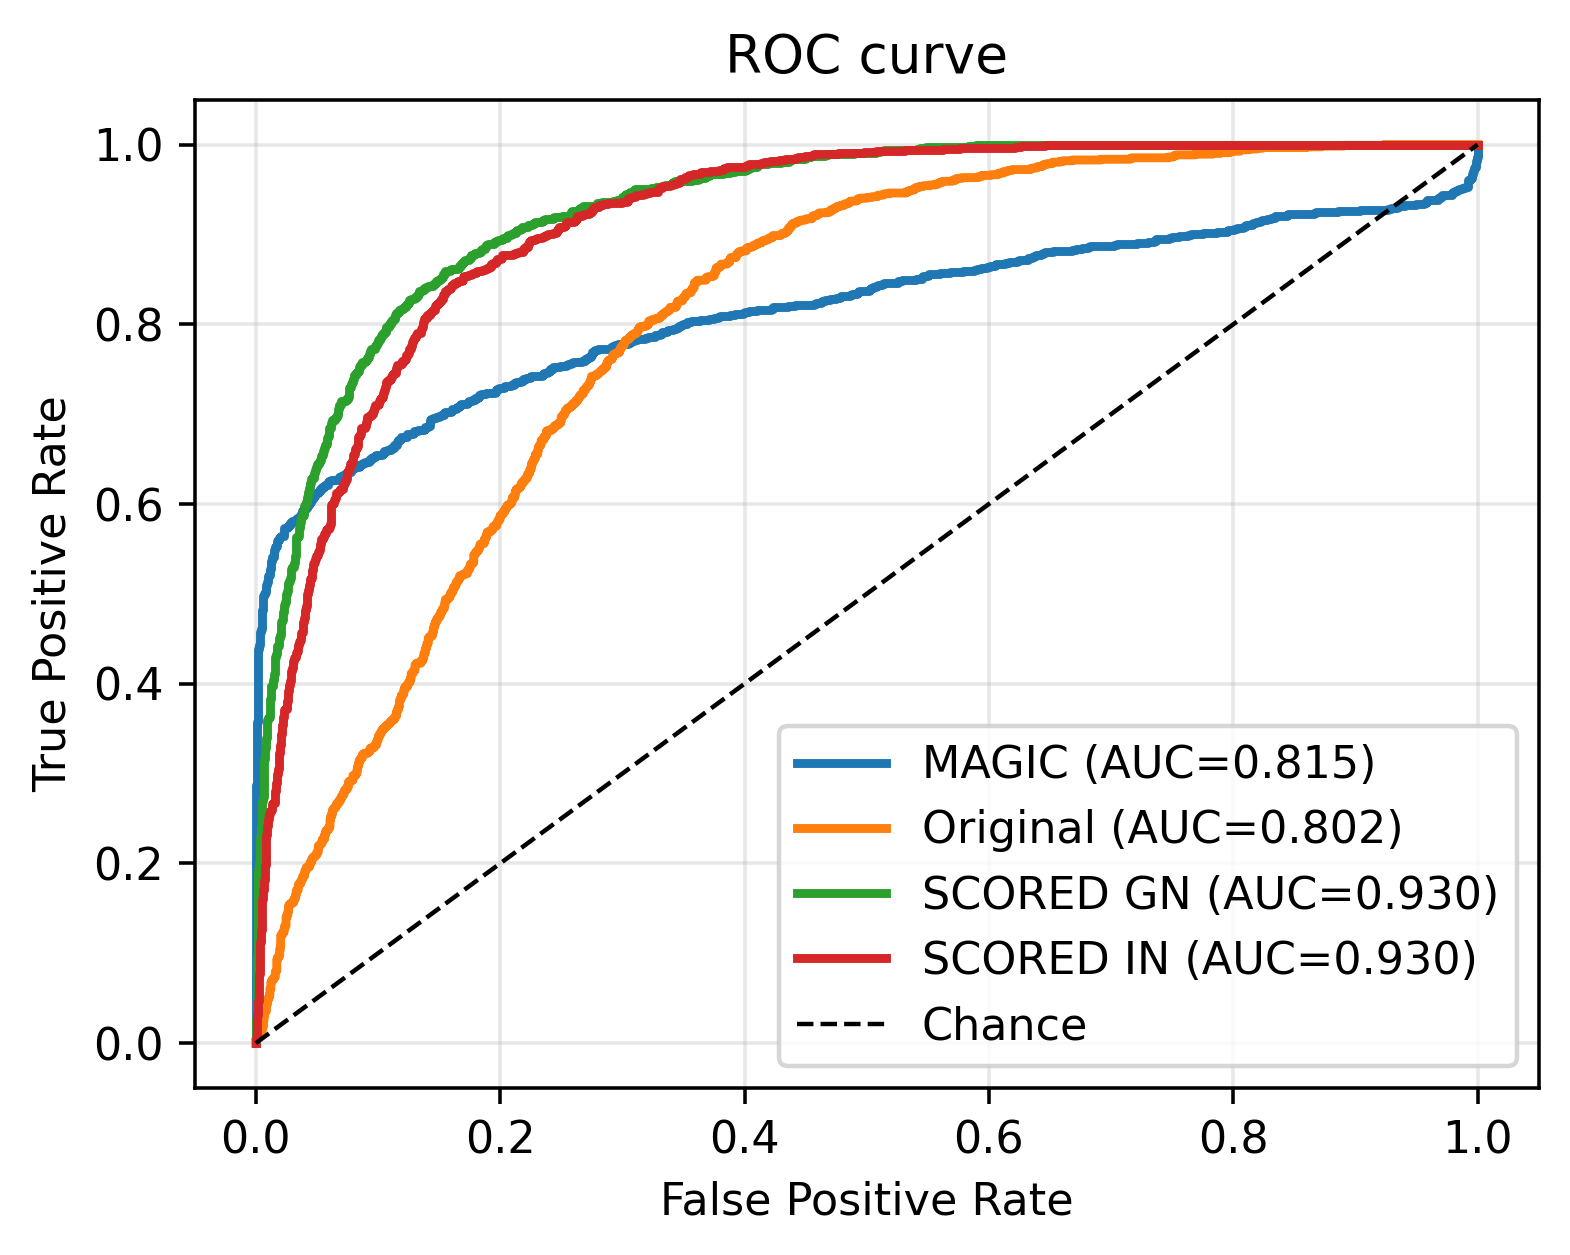

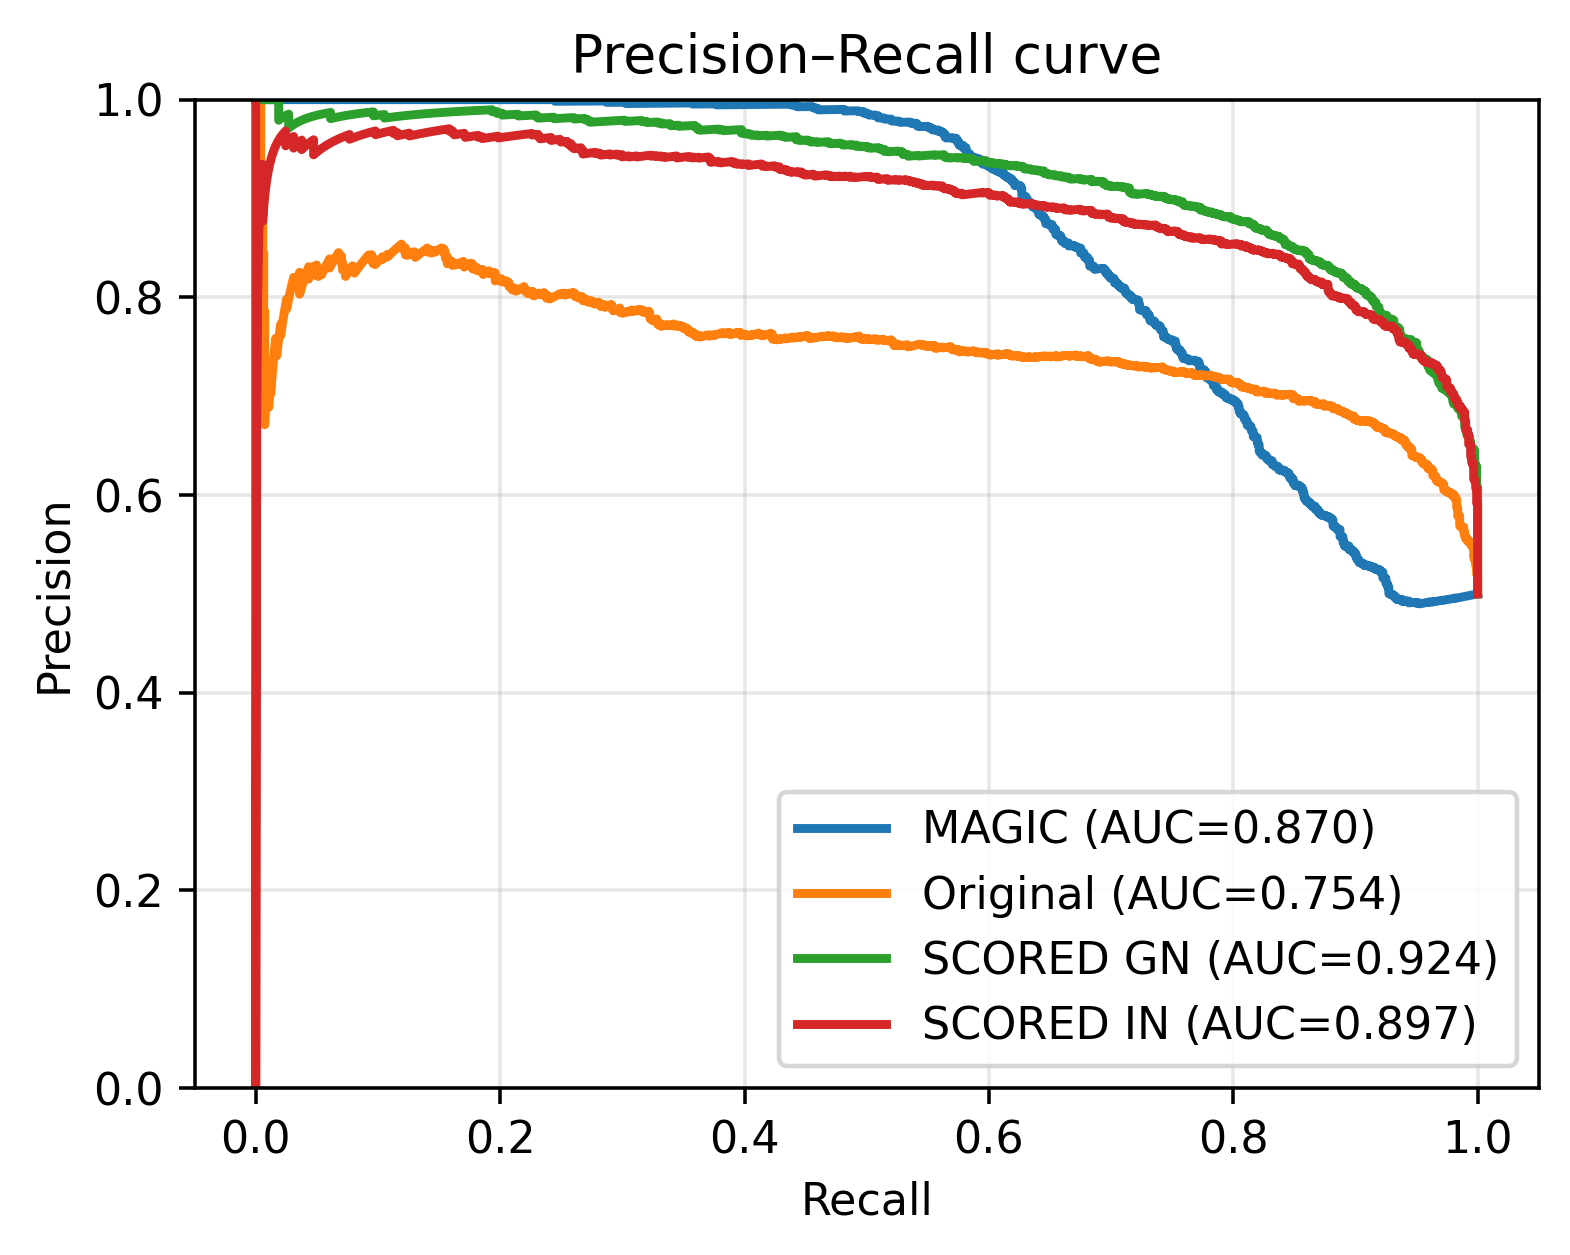

In [37]:

y6, s6 = build_y_scores(within_corr1_resting, between_corr1)
w6 = balanced_weights(y6)
res6 = get_curves(y6, s6, w6)
f6 = f1_at_threshold(y6, s6, thr=0.0, w=w6)




print(f"MAGIC  — ROC-AUC: {res6['roc_auc']:.3f} | PR-AUC: {res6['ap']:.3f}")

plt.figure(figsize=(5,4), dpi=160)
plt.plot(res6["fpr"], res6["tpr"], lw=2, label=f"MAGIC (AUC={res6['roc_auc']:.3f})")
plt.plot(res4["fpr"], res4["tpr"], lw=2, label=f"Original (AUC={res4['roc_auc']:.3f})")
plt.plot(res3["fpr"], res3["tpr"], lw=2, label=f"SCORED GN (AUC={res3['roc_auc']:.3f})")
plt.plot(res3_1["fpr"], res3_1["tpr"], lw=2, label=f"SCORED IN (AUC={res3['roc_auc']:.3f})")
plt.plot([0,1], [0,1], "k--", lw=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4), dpi=160)
plt.plot(res6["pr_r"], res6["pr_p"], lw=2, label=f"MAGIC (AUC={res6['ap']:.3f})")
plt.plot(res4["pr_r"], res4["pr_p"], lw=2, label=f"Original (AUC={res4['ap']:.3f})")
plt.plot(res3["pr_r"], res3["pr_p"], lw=2, label=f"SCORED GN (AUC={res3['ap']:.3f})")
plt.plot(res3_1["pr_r"], res3_1["pr_p"], lw=2, label=f"SCORED IN (AUC={res3_1['ap']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.legend()
plt.grid(True, alpha=.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# KNN

In [38]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc

adata_transcript_1 = sc.read_h5ad('./20230222_new/transcript_raw_8fc.h5ad')

adata_gene_1 = sc.read_h5ad('./20230222_new/gene_raw_8fc.h5ad')


sc.pp.filter_genes(adata_transcript_1, min_cells=3)

adata = adata_transcript_1

if "counts" not in adata.layers:
    adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)
sc.pp.log1p(adata)
adata.raw = adata.copy()

sc.pp.pca(adata, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=50, metric="cosine")  # -> adata.obsp['connectivities']

# kNN smoothing and replace .X in place
def knn_smooth_inplace(
    adata,
    include_self=True,
    n_iter=1,
    chunk_size=2048,     # features per block to limit memory
    use_gpu=False,
    dev="cuda:0"
):
    A = adata.obsp.get("connectivities", None)
    if A is None:
        raise ValueError("Neighbor graph not found. Run sc.pp.neighbors() first.")
    A = A.tocsr().astype(np.float32)
    if include_self:
        A = A + sp.eye(A.shape[0], dtype=np.float32, format="csr")

    rowsum = np.array(A.sum(axis=1)).ravel()
    rowsum[rowsum == 0.0] = 1.0
    Dinv = sp.diags(1.0 / rowsum, format="csr", dtype=np.float32)
    W = Dinv @ A

    X = adata.X
    if sp.issparse(X):
        X = X.tocsr()
    else:
        X = np.asarray(X, dtype=np.float32)

    X_cur = X
    if use_gpu:
        import re, cupy as cp
        from cupyx.scipy.sparse import csr_matrix as cu_csr

        m = re.match(r"cuda:(\d+)", str(dev))
        device_id = int(m.group(1)) if m else 0
        with cp.cuda.Device(device_id):
            W_cu = cu_csr(W)  # move graph to GPU once
            for _ in range(n_iter):
                outs = []
                for j0 in range(0, X_cur.shape[1], chunk_size):
                    j1 = min(j0 + chunk_size, X_cur.shape[1])
                    chunk = X_cur[:, j0:j1]
                    if sp.issparse(chunk):
                        chunk = chunk.toarray()
                    sm_cu = W_cu @ cp.asarray(chunk, dtype=cp.float32)
                    outs.append(cp.asnumpy(sm_cu))
                X_cur = np.hstack(outs)
    else:
        for _ in range(n_iter):
            outs = []
            for j0 in range(0, X_cur.shape[1], chunk_size):
                j1 = min(j0 + chunk_size, X_cur.shape[1])
                chunk = X_cur[:, j0:j1]
                if sp.issparse(chunk):
                    chunk = chunk.toarray()
                outs.append(W @ chunk)
            X_cur = np.hstack(outs)

    adata.X = X_cur.astype(np.float32)

knn_smooth_inplace(adata, include_self=True, n_iter=1, use_gpu=True, dev="cuda:0")  # GPU


In [ ]:
matrix_knn = adata.X
activation_top50 = activation.head(2000)["gene"].tolist()
resting_top50    = resting.head(2000)["gene"].tolist()

activation_prefixes = [gene + '-' for gene in activation_top50]
resting_prefixes    = [gene + '-' for gene in resting_top50]

activation_features = adata_transcript_raw_combined.var_names[
    adata_transcript_raw_combined.var_names.str.startswith(tuple(activation_prefixes))
]
resting_features = adata_transcript_raw_combined.var_names[
    adata_transcript_raw_combined.var_names.str.startswith(tuple(resting_prefixes))
]

activation_indices = [adata.var_names.get_loc(gene) for gene in activation_features]
resting_indices    = [adata.var_names.get_loc(gene) for gene in resting_features]

n_cells = matrix_new.shape[0]
expr_threshold = 0.1 * n_cells
activation_indices = [idx for idx in activation_indices if (matrix_raw[:, idx] > 0).sum() >= expr_threshold]
resting_indices    = [idx for idx in resting_indices if (matrix_raw[:, idx] > 0).sum() >= expr_threshold]

activation_indices = activation_indices[:50]
resting_indices    = resting_indices[:50]

print(f"Number of activation features: {len(activation_indices)}")
print(f"Number of resting features:    {len(resting_indices)}")

# Subset matrix_magic for each group
matrix1_activation = matrix_knn[:, activation_indices]
matrix1_resting    = matrix_knn[:, resting_indices]


# For between-group comparisons, combine the indices
combined_indices = activation_indices + resting_indices

# ----------------------------- Step 5 -----------------------------
# Define a function to compute the Pearson correlation matrix (columns as variables)
def compute_corr_matrix(matrix):
    return np.corrcoef(matrix, rowvar=False)

# For Matrix 1:
corr1_activation = compute_corr_matrix(matrix1_activation)
corr1_resting    = compute_corr_matrix(matrix1_resting)

# For between-group correlations in Matrix 1:
matrix1_combined = matrix_knn[:, combined_indices]  # FIX: was matrix_new (SCORED), should be matrix_knn for the KNN, Pearson benchmark
corr1_combined = compute_corr_matrix(matrix1_combined)
n_act = len(activation_indices)
n_rest = len(resting_indices)
# Extract the off-diagonal block: activation (rows) vs resting (columns)
between_corr1 = corr1_combined[:n_act, n_act:].flatten()


# Define a helper function to extract unique pairwise correlations (upper triangle, excluding the diagonal)
def get_within_corr(corr_matrix):
    n = corr_matrix.shape[0]
    iu = np.triu_indices(n, k=1)
    return corr_matrix[iu]

within_corr1_activation = get_within_corr(corr1_activation)
within_corr1_resting    = get_within_corr(corr1_resting)



# helper function for calculating median
from scipy.stats import gaussian_kde

def kde_with_capped_median(x, color, label, bw_adjust=1.0):
    ax = plt.gca()
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return

    # 1) KDE curve (for visuals)
    sns.kdeplot(x, fill=True, lw=2, color=color, label=label, bw_adjust=bw_adjust, ax=ax)

    # 2) KDE value at the median (robust, version‑independent)
    med = np.median(x)
    try:
        kde = gaussian_kde(x, bw_method=lambda s: s.scotts_factor() * bw_adjust)
        y_med = float(kde.evaluate([med]))
        if not np.isfinite(y_med):  # rare numerical issue
            return
    except Exception:
        return

    # 3) short dashed median segment
    ax.vlines(med, 0, y_med, colors=color, linestyles='--', linewidth=1.5, zorder=3)
    # optional numeric label:
    # ax.text(med, y_med, f"{med:.2f}", ha="center", va="bottom", fontsize=9)
# ----------------------------- Step 6: Plotting -----------------------------
# Define common plotting parameters
figsize = (6, 4)
dpi = 300
xlabel_fs = 10
ylabel_fs = 10
title_fs = 14
legend_fs = 10

# Colors for the curves
color_activation = "#F18072"
color_resting    = "#8CD0C3"
color_between    = "#80B1D2"


# matrix_magic
plt.figure(figsize=figsize, dpi=dpi)
kde_with_capped_median(within_corr1_activation, color_activation, "Activation (within)", bw_adjust=2)
kde_with_capped_median(within_corr1_resting,    color_resting,    "Resting (within)",  bw_adjust=2)
kde_with_capped_median(between_corr1,           color_between,    "Between",           bw_adjust=2)
plt.xlabel("Pearson Correlation", fontsize=xlabel_fs)
plt.ylabel("Density", fontsize=ylabel_fs)
plt.title("Distribution of Pearson Correlations (KNN)", fontsize=title_fs)
plt.legend(fontsize=legend_fs)
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.xlim(-1, 1); plt.grid(True); plt.tight_layout(); plt.show()

In [ ]:
def compute_corr_matrix(matrix):

    corr_matrix, _ = spearmanr(matrix, axis=0)
    return corr_matrix

corr1_activation = compute_corr_matrix(matrix1_activation)
corr1_resting    = compute_corr_matrix(matrix1_resting)

matrix1_combined = matrix_knn[:, combined_indices]  # FIX: was matrix_new (SCORED), should be matrix_knn for the KNN, Spearman benchmark
corr1_combined   = compute_corr_matrix(matrix1_combined)
n_act = len(activation_indices)
n_rest = len(resting_indices)
between_corr1 = corr1_combined[:n_act, n_act:].flatten()


def get_within_corr(corr_matrix):
    iu = np.triu_indices(corr_matrix.shape[0], k=1)
    return corr_matrix[iu]

within_corr1_activation = get_within_corr(corr1_activation)
within_corr1_resting    = get_within_corr(corr1_resting)
within_corr2_activation = get_within_corr(corr2_activation)
within_corr2_resting    = get_within_corr(corr2_resting)


figsize = (6, 4)
dpi = 300
xlabel_fs = 10
ylabel_fs = 10
title_fs = 14
legend_fs = 10

color_activation = "#F18072"
color_resting    = "#8CD0C3"
color_between    = "#80B1D2"

plt.figure(figsize=figsize, dpi=dpi)
kde_with_capped_median(within_corr1_activation, color_activation, "Activation (within)", bw_adjust=2)
kde_with_capped_median(within_corr1_resting,    color_resting,    "Resting (within)",  bw_adjust=2)
kde_with_capped_median(between_corr1,           color_between,    "Between",           bw_adjust=2)
plt.xlabel("Spearman Correlation", fontsize=xlabel_fs)
plt.ylabel("Density",               fontsize=ylabel_fs)
plt.title("Distribution of Spearman Correlations (KNN)", fontsize=title_fs)
plt.legend(fontsize=legend_fs)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlim(-1, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


In [41]:
# KNN
y7, s7 = build_y_scores(within_corr1_activation, between_corr1)
w7 = balanced_weights(y7)
res7 = get_curves(y7, s7, w7)
f7 = f1_at_threshold(y7, s7, thr=0.0, w=w7)


print(f"KNN  — ROC-AUC: {res7['roc_auc']:.3f} | PR-AUC: {res7['ap']:.3f}")



KNN  — ROC-AUC: 0.888 | PR-AUC: 0.903


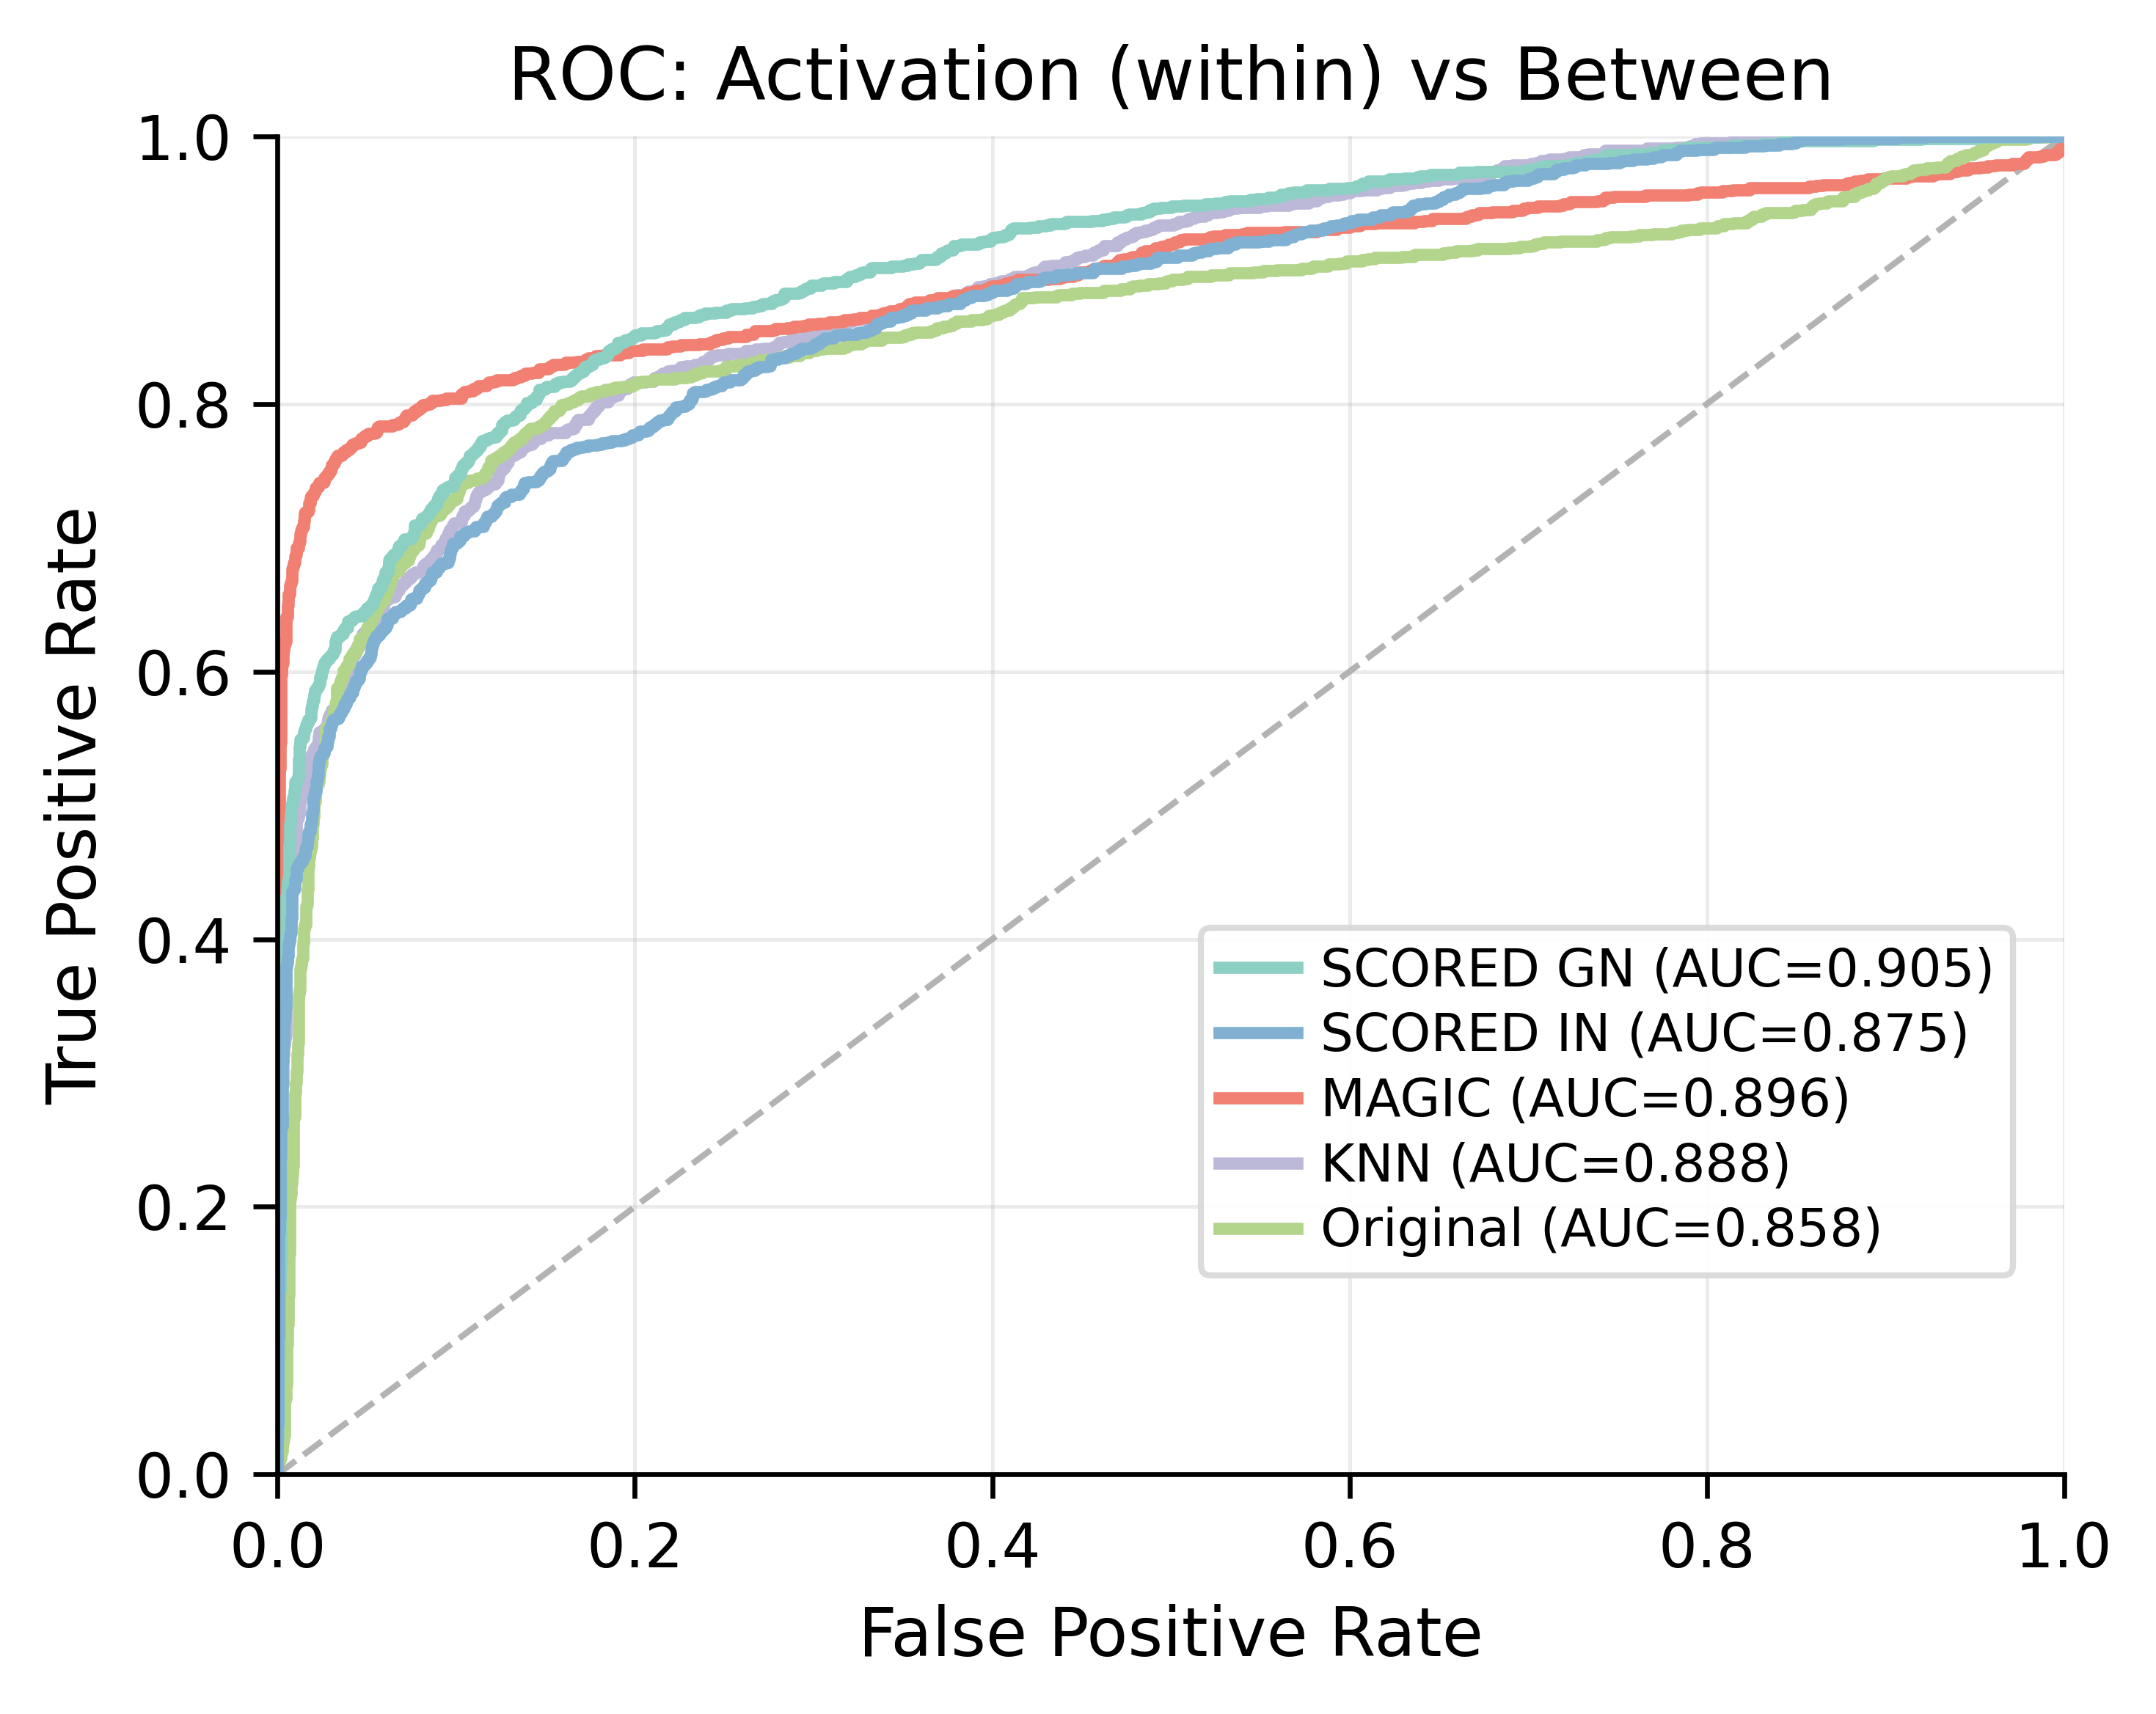

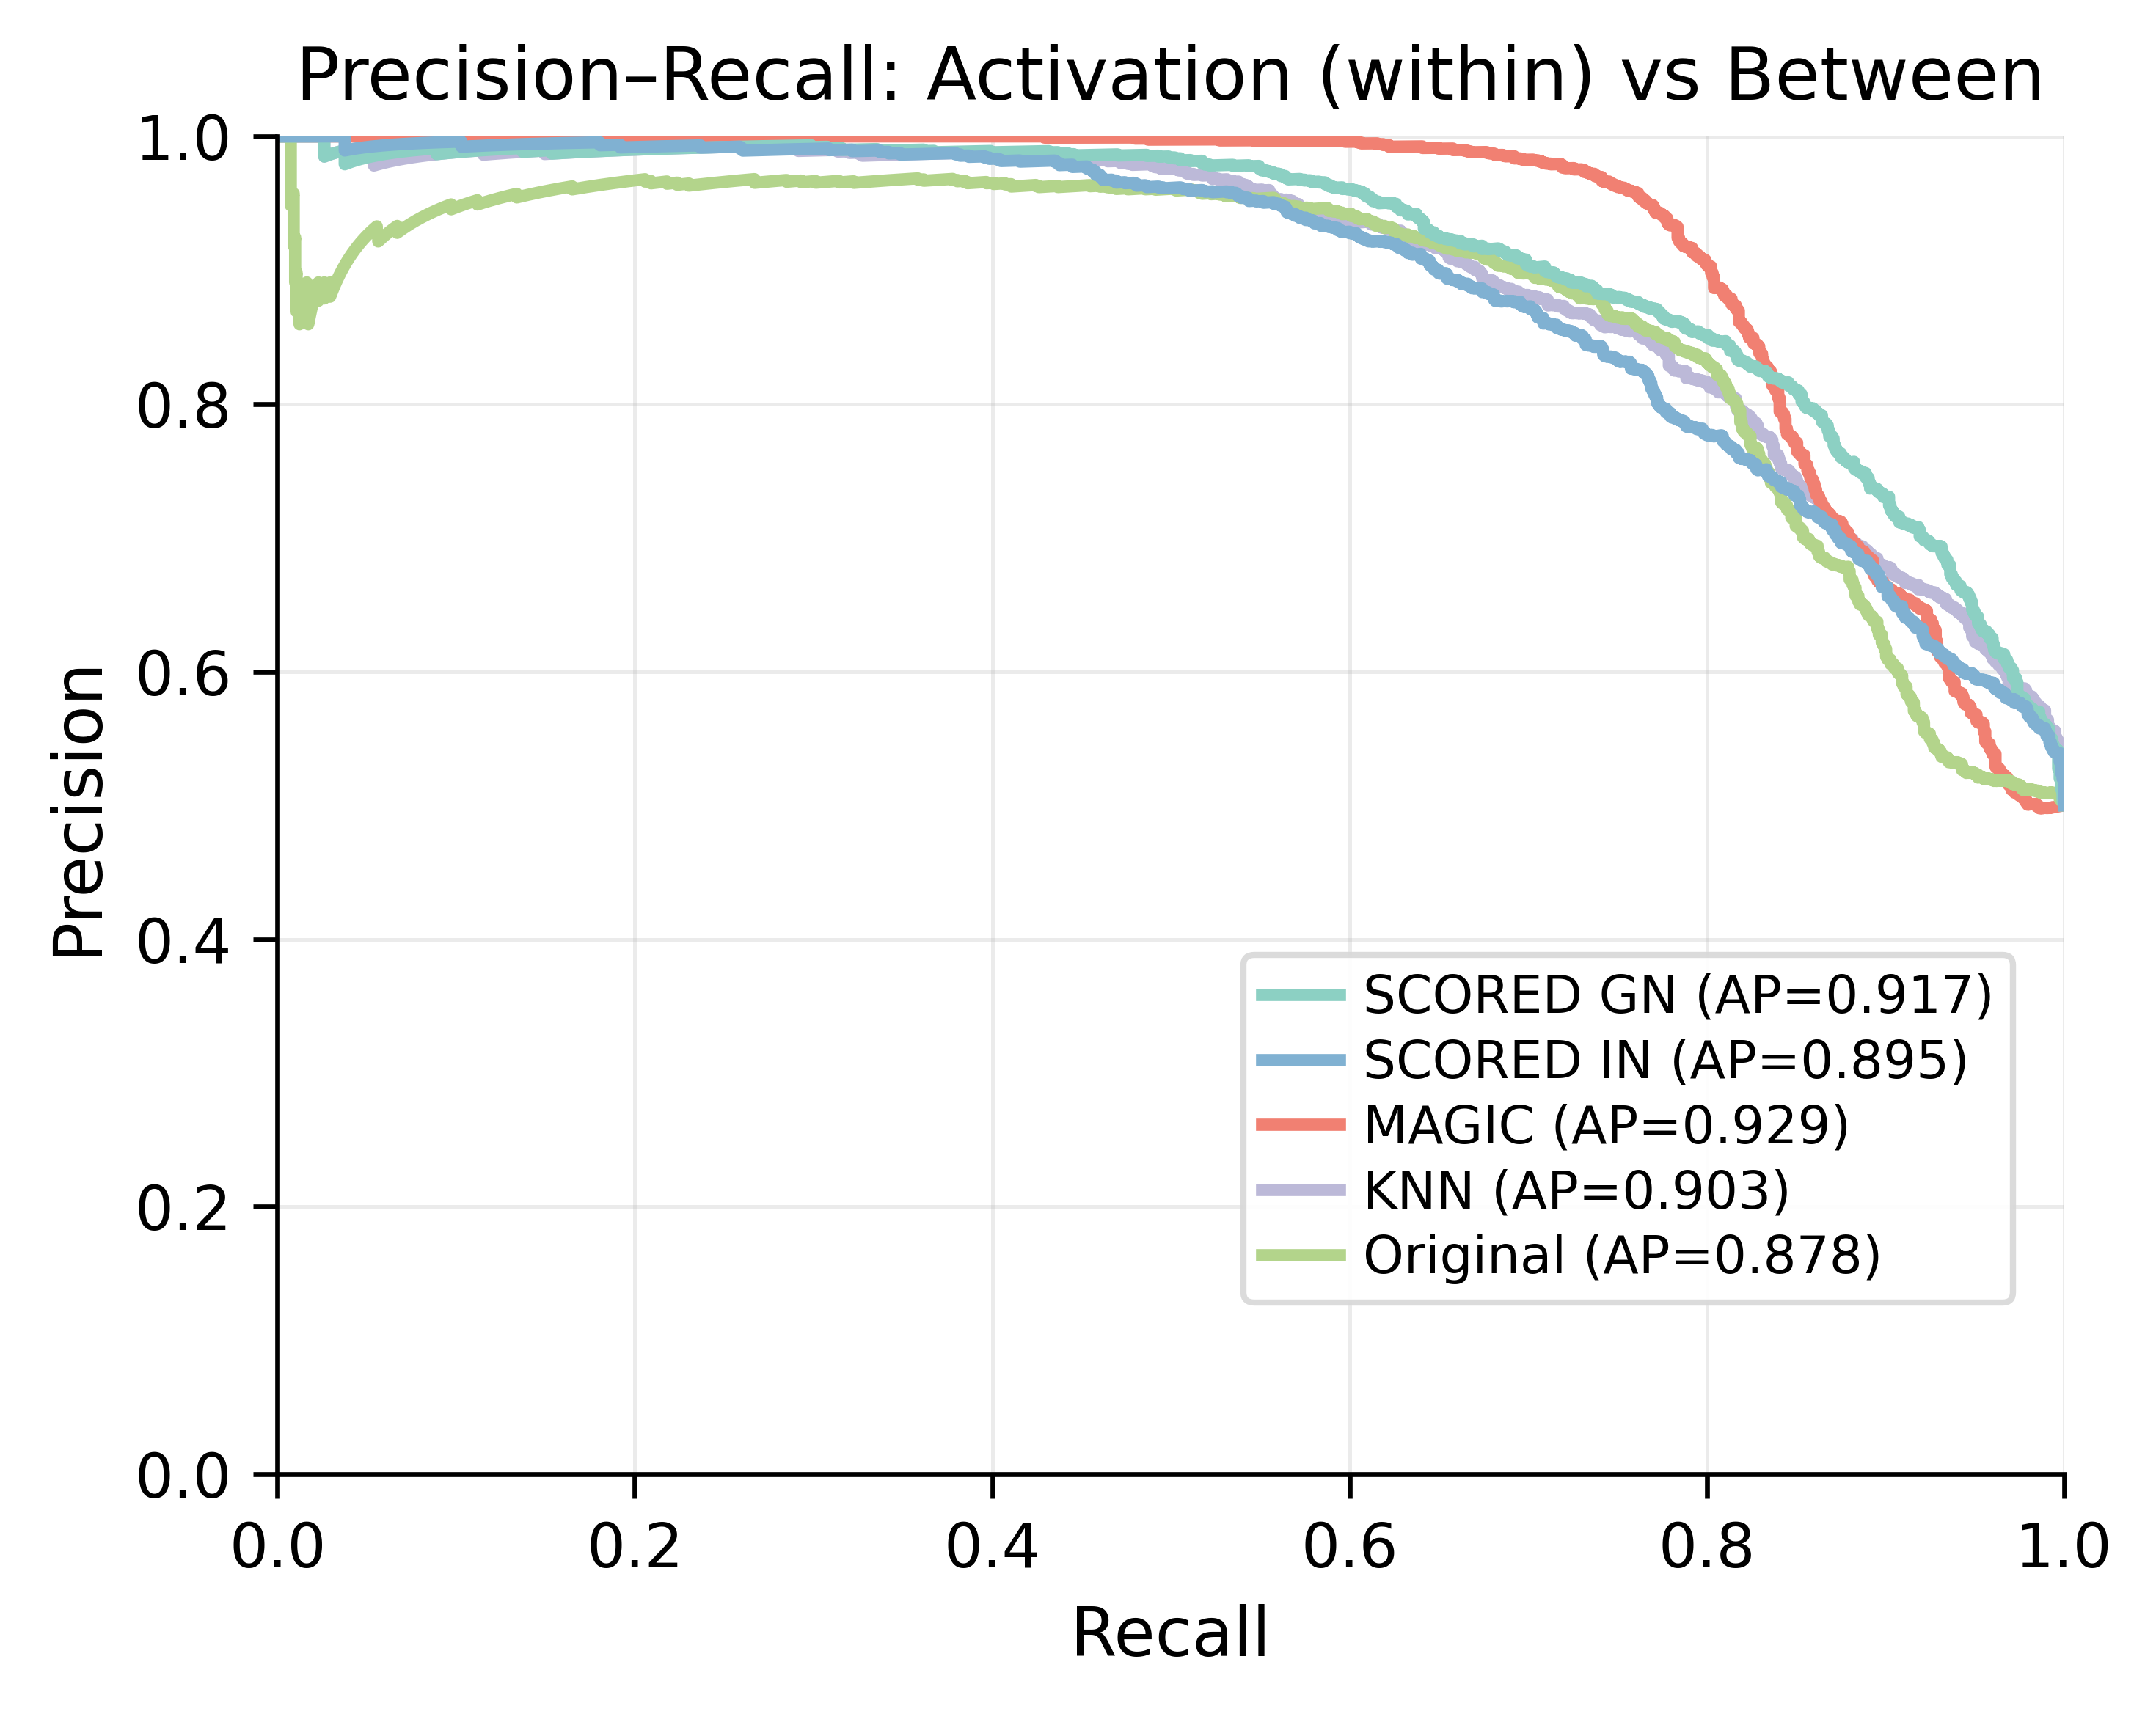

In [42]:
palette = {
    "SCORED GN": "#8CD0C3",
    "SCORED IN": "#80B1D2",
    "MAGIC":     "#F18072",
    "KNN":       "#BCB9D8",
    "Original":  "#B3D48B"
}
legend_order = ["SCORED GN", "SCORED IN", "MAGIC", "KNN", "Original"]

plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300,
    "font.size": 10, "axes.labelsize": 11, "axes.titlesize": 12,
    "legend.fontsize": 9, "axes.linewidth": 0.8,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 4, "ytick.major.size": 4,
})

def _beautify_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, which="major", alpha=0.25, linewidth=0.6)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig, ax = plt.subplots(figsize=(5, 4))
lines = {}
lines["KNN"],       = ax.plot(res7["fpr"],   res7["tpr"],   lw=2, color=palette["KNN"])
lines["MAGIC"],     = ax.plot(res5["fpr"],   res5["tpr"],   lw=2, color=palette["MAGIC"])
lines["Original"],  = ax.plot(res2["fpr"],   res2["tpr"],   lw=2, color=palette["Original"])
lines["SCORED GN"], = ax.plot(res1["fpr"],   res1["tpr"],   lw=2, color=palette["SCORED GN"])
lines["SCORED IN"], = ax.plot(res1_1["fpr"], res1_1["tpr"], lw=2, color=palette["SCORED IN"])

lines["KNN"].set_label(f"KNN (AUC={res7['roc_auc']:.3f})")
lines["MAGIC"].set_label(f"MAGIC (AUC={res5['roc_auc']:.3f})")
lines["Original"].set_label(f"Original (AUC={res2['roc_auc']:.3f})")
lines["SCORED GN"].set_label(f"SCORED GN (AUC={res1['roc_auc']:.3f})")
lines["SCORED IN"].set_label(f"SCORED IN (AUC={res1_1['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], "--", color="0.7", lw=1, zorder=0)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC: Activation (within) vs Between")
_beautify_axes(ax)

ANCHOR_Y_ROC = 0.42
handles = [lines[k] for k in legend_order]
labels  = [h.get_label() for h in handles]
ax.legend(
    handles, labels,
    loc="upper right", bbox_to_anchor=(0.98, ANCHOR_Y_ROC),
    frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.85",
    borderpad=0.35, labelspacing=0.28, handlelength=1.5, handletextpad=0.45,
    borderaxespad=0.3, prop={"size": 8.5}
)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
lines = {}
lines["KNN"],       = ax.plot(res7["pr_r"],   res7["pr_p"],   lw=2, color=palette["KNN"])
lines["MAGIC"],     = ax.plot(res5["pr_r"],   res5["pr_p"],   lw=2, color=palette["MAGIC"])
lines["Original"],  = ax.plot(res2["pr_r"],   res2["pr_p"],   lw=2, color=palette["Original"])
lines["SCORED GN"], = ax.plot(res1["pr_r"],   res1["pr_p"],   lw=2, color=palette["SCORED GN"])
lines["SCORED IN"], = ax.plot(res1_1["pr_r"], res1_1["pr_p"], lw=2, color=palette["SCORED IN"])

lines["KNN"].set_label(f"KNN (AP={res7['ap']:.3f})")
lines["MAGIC"].set_label(f"MAGIC (AP={res5['ap']:.3f})")
lines["Original"].set_label(f"Original (AP={res2['ap']:.3f})")
lines["SCORED GN"].set_label(f"SCORED GN (AP={res1['ap']:.3f})")
lines["SCORED IN"].set_label(f"SCORED IN (AP={res1_1['ap']:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall: Activation (within) vs Between")
ax.set_ylim(0, 1)
_beautify_axes(ax)

ANCHOR_Y_PR = 0.40
handles = [lines[k] for k in legend_order]
labels  = [h.get_label() for h in handles]
ax.legend(
    handles, labels,
    loc="upper right", bbox_to_anchor=(0.98, ANCHOR_Y_PR),
    frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.85",
    borderpad=0.35, labelspacing=0.28, handlelength=1.5, handletextpad=0.45,
    borderaxespad=0.3, prop={"size": 8.5}
)
fig.tight_layout()
plt.show()

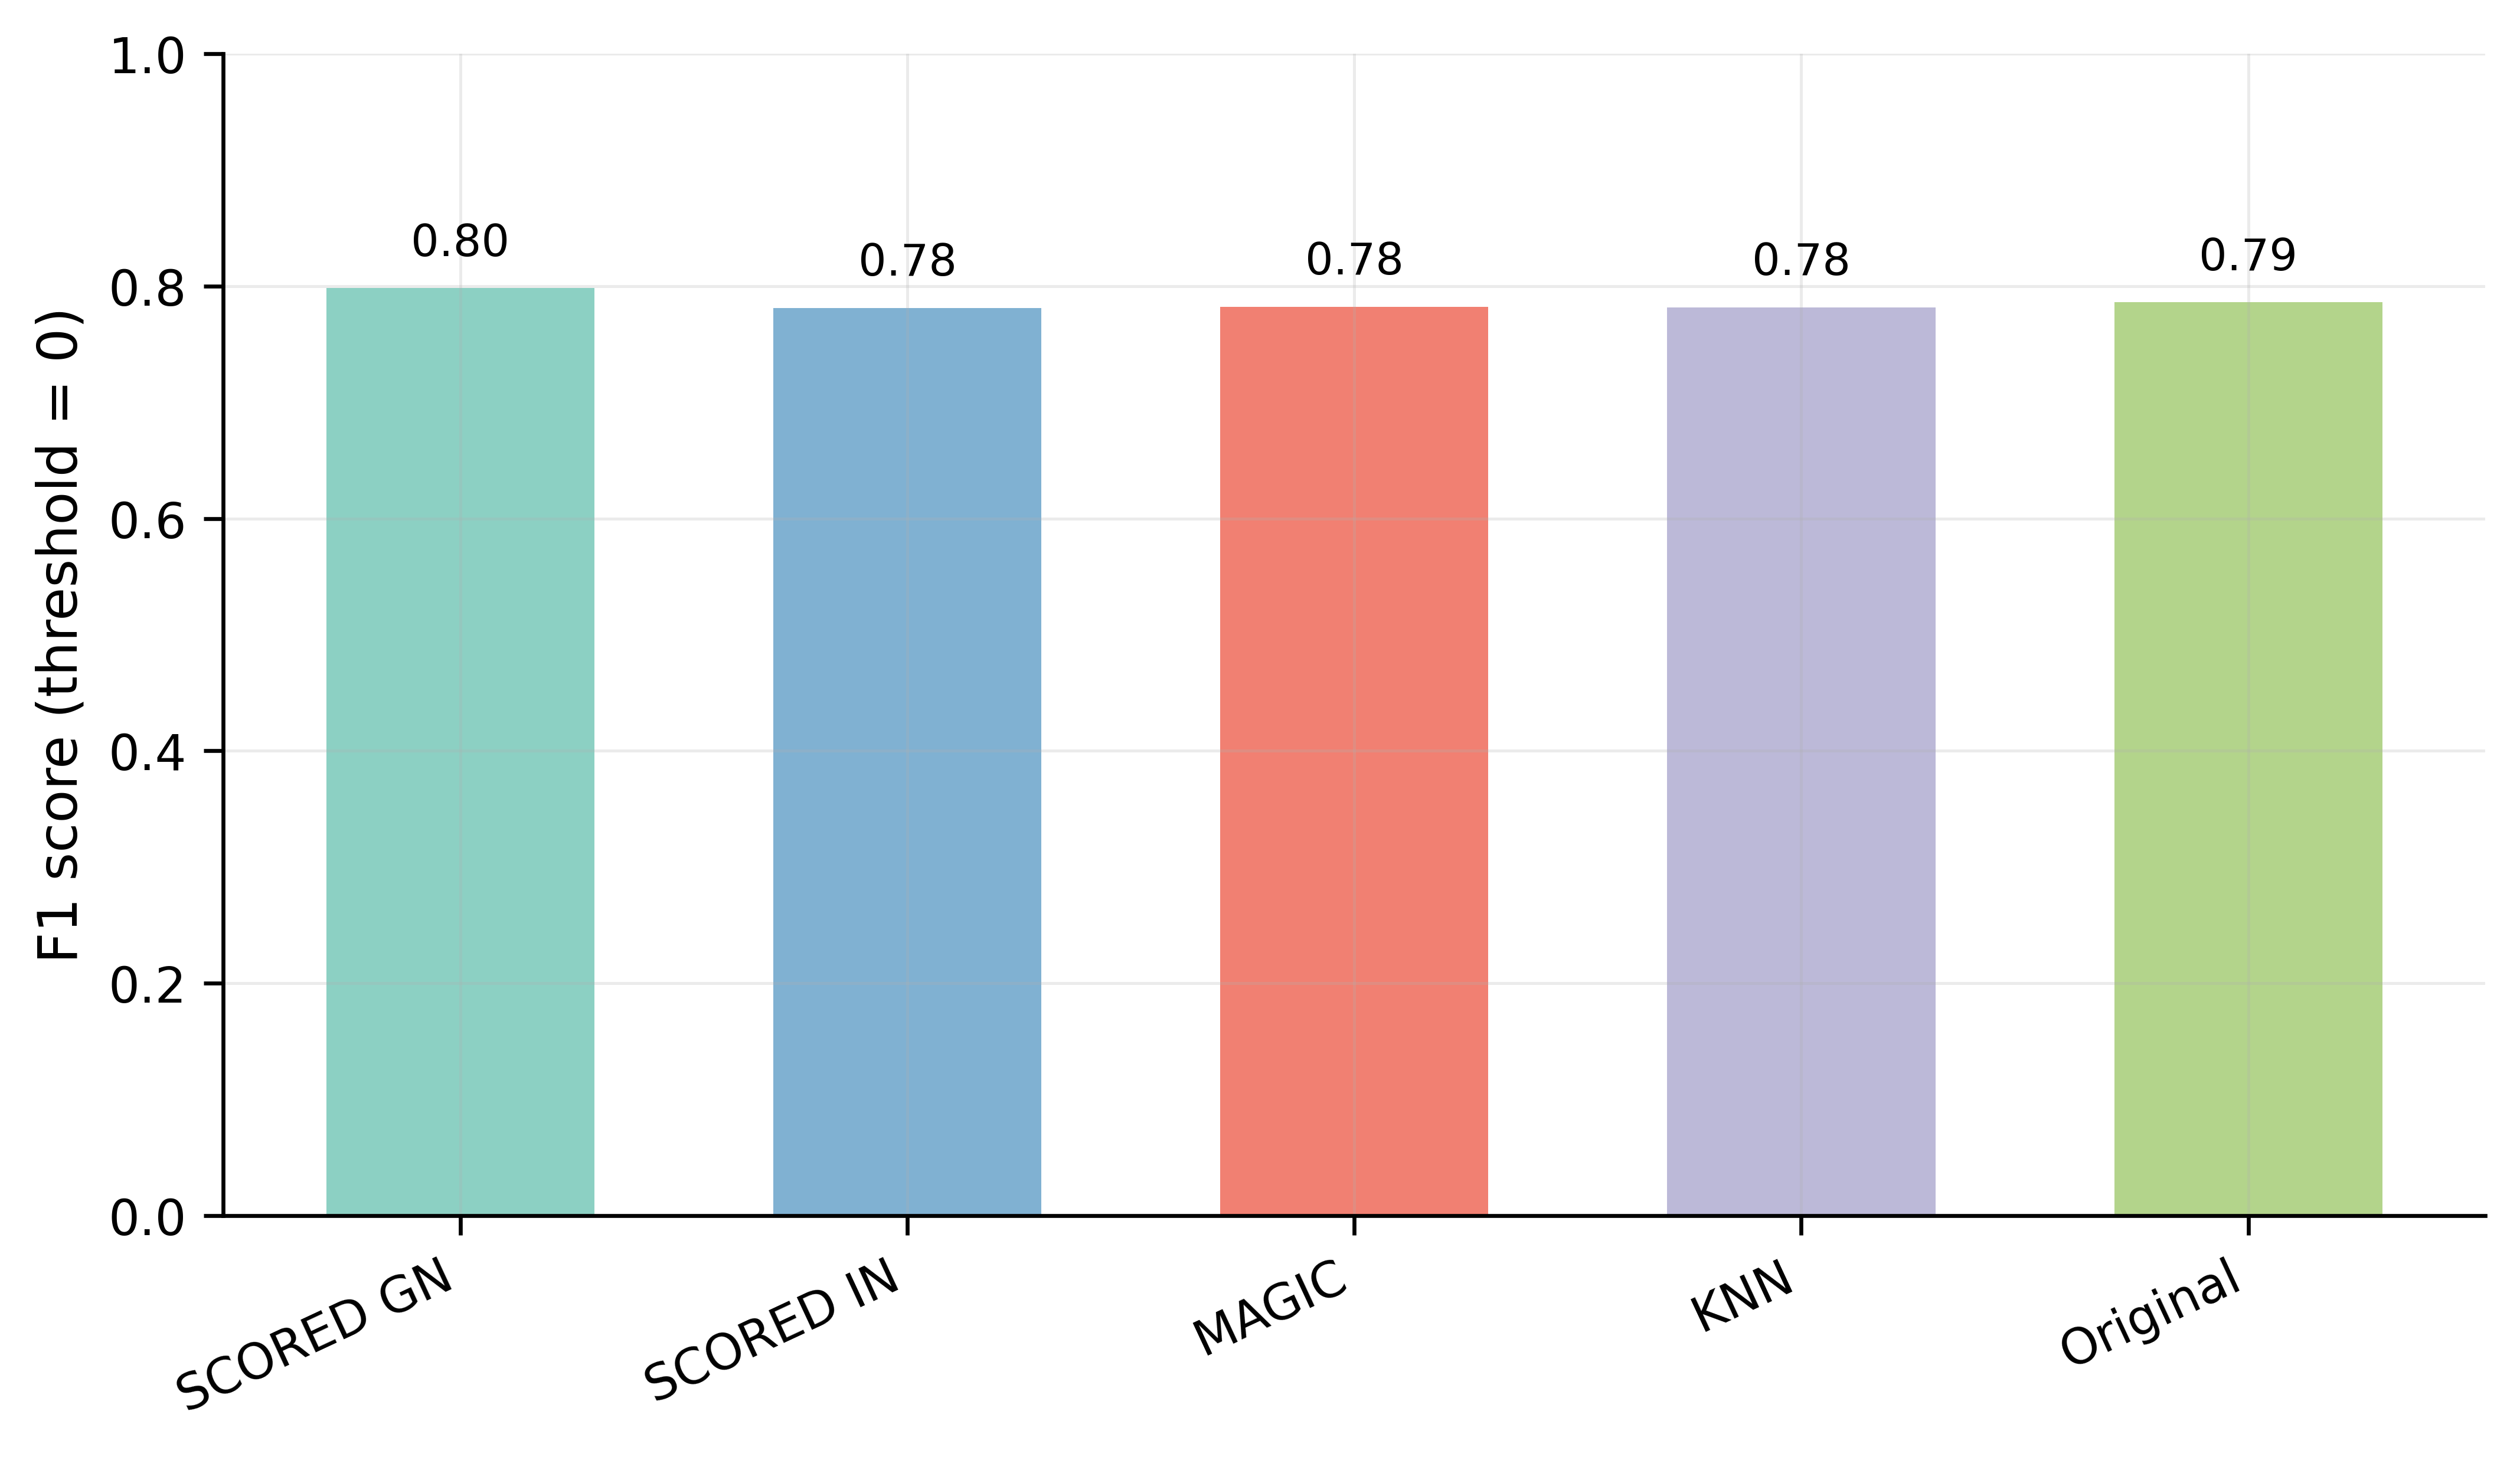

In [43]:
f_scores = {
    "SCORED GN": f1,
    "SCORED IN": f1_1,
    "MAGIC":     f5,
    "KNN":       f7,
    "Original":  f2,
}

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

x = np.arange(len(legend_order))
y = [f_scores[k] for k in legend_order]

bars = ax.bar(x, y, color=[palette[k] for k in legend_order], width=0.6)

ax.set_xticks(x)
ax.set_xticklabels(legend_order, rotation=25, ha="right")
ax.set_ylabel("F1 score (threshold = 0)")
ax.set_ylim(0, 1)
ax.grid(True, which="major", alpha=0.25, linewidth=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for rect, val in zip(bars, y):
    ax.text(rect.get_x() + rect.get_width()/2,
            rect.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9, clip_on=False)

plt.show()

In [44]:

# knn
y8, s8 = build_y_scores(within_corr1_resting, between_corr1)
w8 = balanced_weights(y8)
res8 = get_curves(y8, s8, w8)
f8 = f1_at_threshold(y8, s8, thr=0.0, w=w8)




print(f"KNN  — ROC-AUC: {res8['roc_auc']:.3f} | PR-AUC: {res8['ap']:.3f}")



KNN  — ROC-AUC: 0.805 | PR-AUC: 0.795


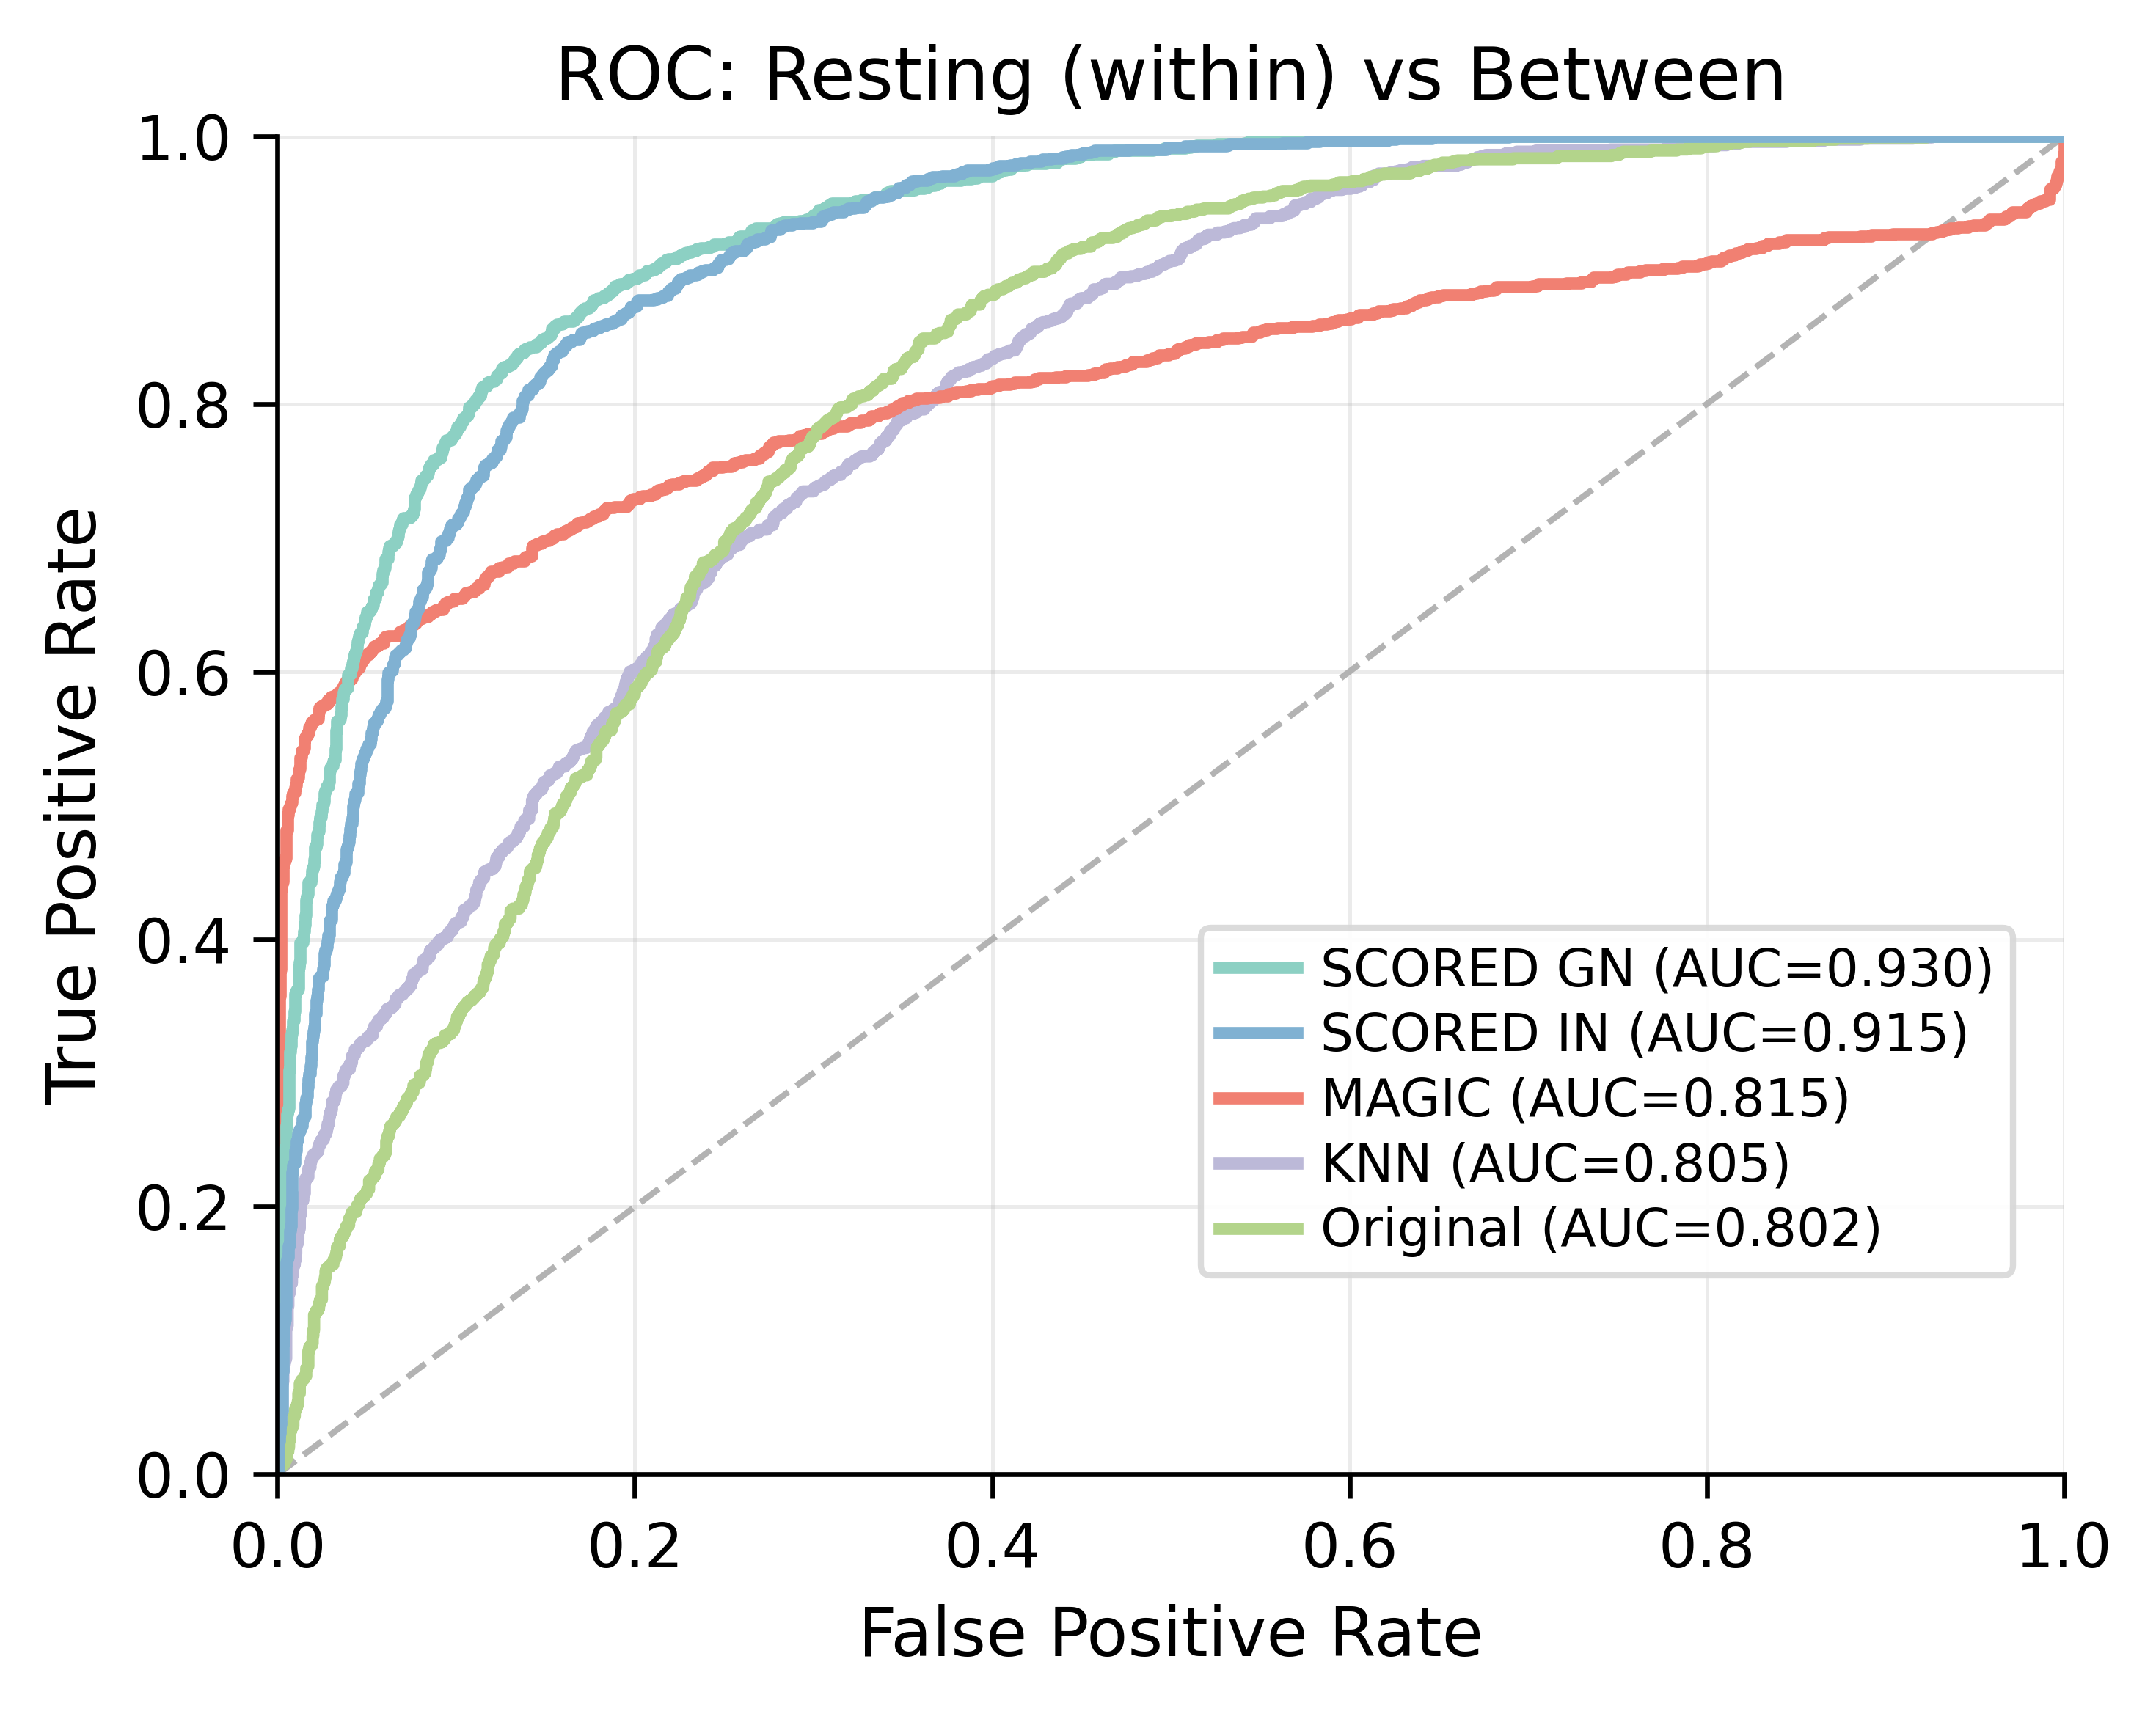

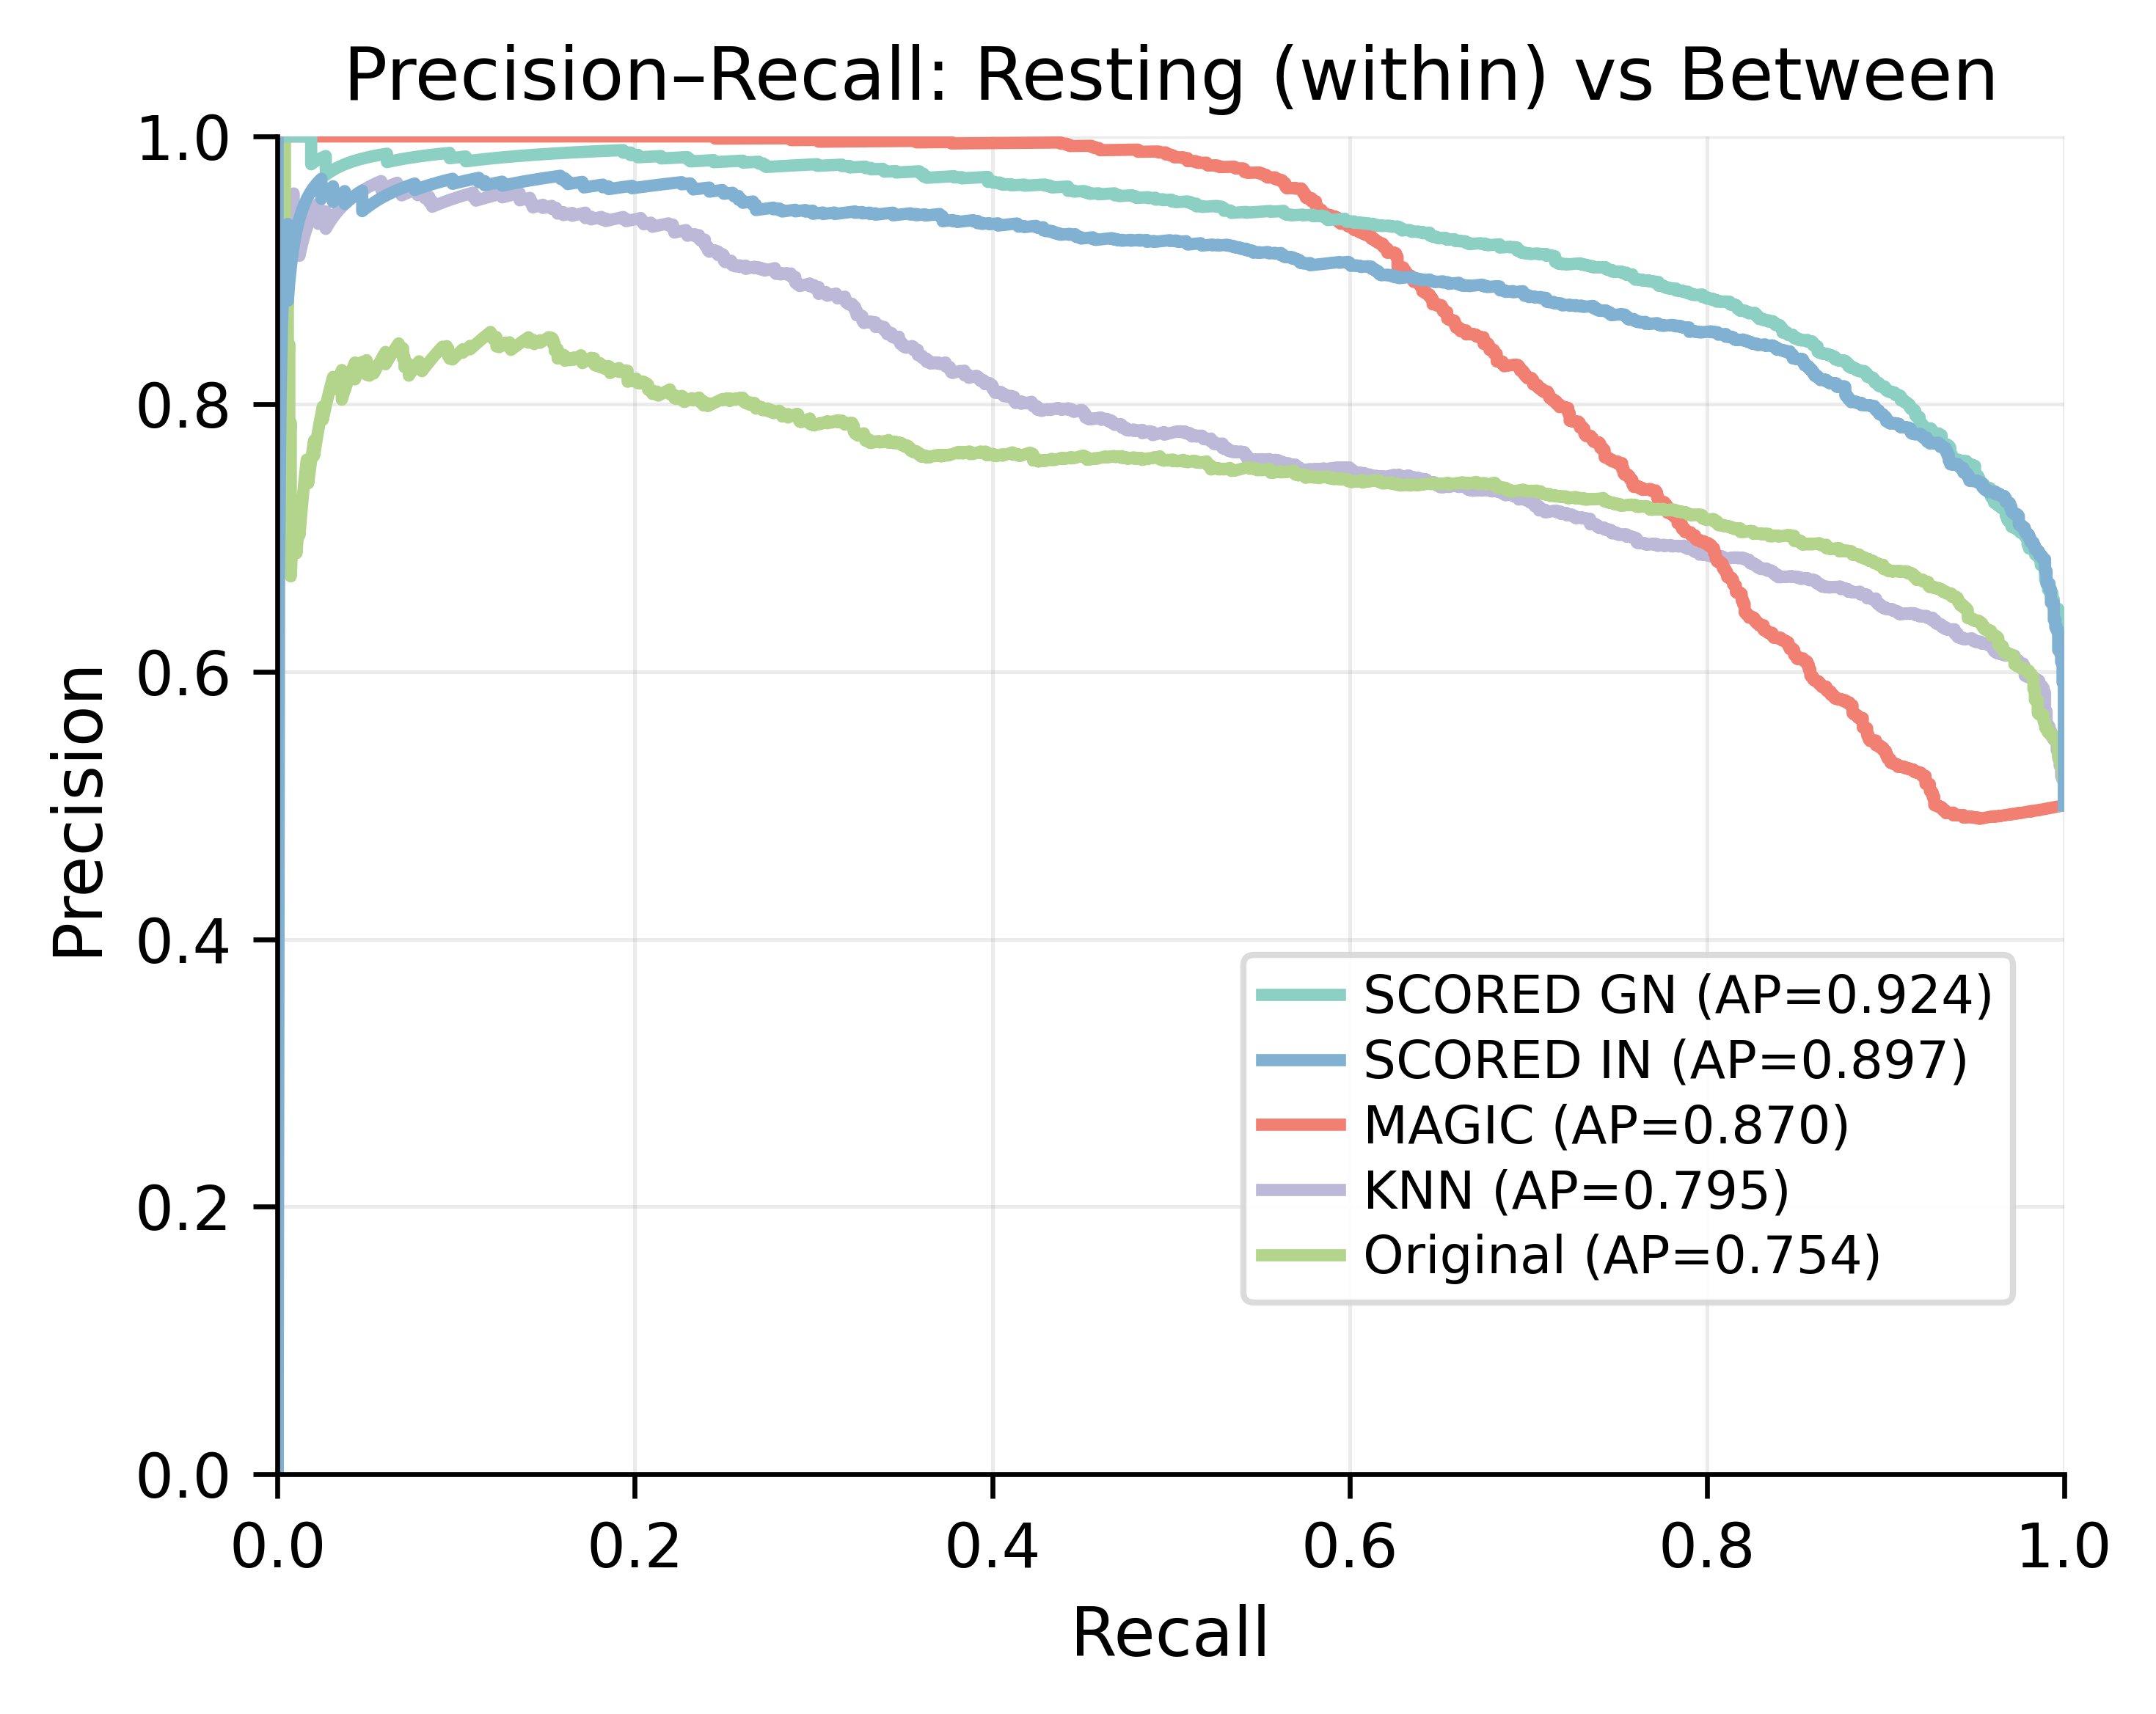

In [45]:
palette = {
    "SCORED GN": "#8CD0C3",
    "SCORED IN": "#80B1D2",
    "MAGIC":     "#F18072",
    "KNN":       "#BCB9D8",
    "Original":  "#B3D48B"
}
legend_order = ["SCORED GN", "SCORED IN", "MAGIC", "KNN", "Original"]

plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300,
    "font.size": 10, "axes.labelsize": 11, "axes.titlesize": 12,
    "legend.fontsize": 9, "axes.linewidth": 0.8,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 4, "ytick.major.size": 4,
})

def _beautify_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, which="major", alpha=0.25, linewidth=0.6)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig, ax = plt.subplots(figsize=(5, 4))
lines = {}
lines["KNN"],       = ax.plot(res8["fpr"],   res8["tpr"],   lw=2, color=palette["KNN"])
lines["MAGIC"],     = ax.plot(res6["fpr"],   res6["tpr"],   lw=2, color=palette["MAGIC"])
lines["Original"],  = ax.plot(res4["fpr"],   res4["tpr"],   lw=2, color=palette["Original"])
lines["SCORED GN"], = ax.plot(res3["fpr"],   res3["tpr"],   lw=2, color=palette["SCORED GN"])
lines["SCORED IN"], = ax.plot(res3_1["fpr"], res3_1["tpr"], lw=2, color=palette["SCORED IN"])

lines["KNN"].set_label(f"KNN (AUC={res8['roc_auc']:.3f})")
lines["MAGIC"].set_label(f"MAGIC (AUC={res6['roc_auc']:.3f})")
lines["Original"].set_label(f"Original (AUC={res4['roc_auc']:.3f})")
lines["SCORED GN"].set_label(f"SCORED GN (AUC={res3['roc_auc']:.3f})")
lines["SCORED IN"].set_label(f"SCORED IN (AUC={res3_1['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], "--", color="0.7", lw=1, zorder=0)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC: Resting (within) vs Between")
_beautify_axes(ax)

ANCHOR_Y_ROC = 0.42
handles = [lines[k] for k in legend_order]
labels  = [h.get_label() for h in handles]
ax.legend(
    handles, labels,
    loc="upper right", bbox_to_anchor=(0.98, ANCHOR_Y_ROC),
    frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.85",
    borderpad=0.35, labelspacing=0.28, handlelength=1.5, handletextpad=0.45,
    borderaxespad=0.3, prop={"size": 8.5}
)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
lines = {}
lines["KNN"],       = ax.plot(res8["pr_r"],   res8["pr_p"],   lw=2, color=palette["KNN"])
lines["MAGIC"],     = ax.plot(res6["pr_r"],   res6["pr_p"],   lw=2, color=palette["MAGIC"])
lines["Original"],  = ax.plot(res4["pr_r"],   res4["pr_p"],   lw=2, color=palette["Original"])
lines["SCORED GN"], = ax.plot(res3["pr_r"],   res3["pr_p"],   lw=2, color=palette["SCORED GN"])
lines["SCORED IN"], = ax.plot(res3_1["pr_r"], res3_1["pr_p"], lw=2, color=palette["SCORED IN"])

lines["KNN"].set_label(f"KNN (AP={res8['ap']:.3f})")
lines["MAGIC"].set_label(f"MAGIC (AP={res6['ap']:.3f})")
lines["Original"].set_label(f"Original (AP={res4['ap']:.3f})")
lines["SCORED GN"].set_label(f"SCORED GN (AP={res3['ap']:.3f})")
lines["SCORED IN"].set_label(f"SCORED IN (AP={res3_1['ap']:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall: Resting (within) vs Between")
ax.set_ylim(0, 1)
_beautify_axes(ax)

ANCHOR_Y_PR = 0.40
handles = [lines[k] for k in legend_order]
labels  = [h.get_label() for h in handles]
ax.legend(
    handles, labels,
    loc="upper right", bbox_to_anchor=(0.98, ANCHOR_Y_PR),
    frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.85",
    borderpad=0.35, labelspacing=0.28, handlelength=1.5, handletextpad=0.45,
    borderaxespad=0.3, prop={"size": 8.5}
)
fig.tight_layout()
plt.show()

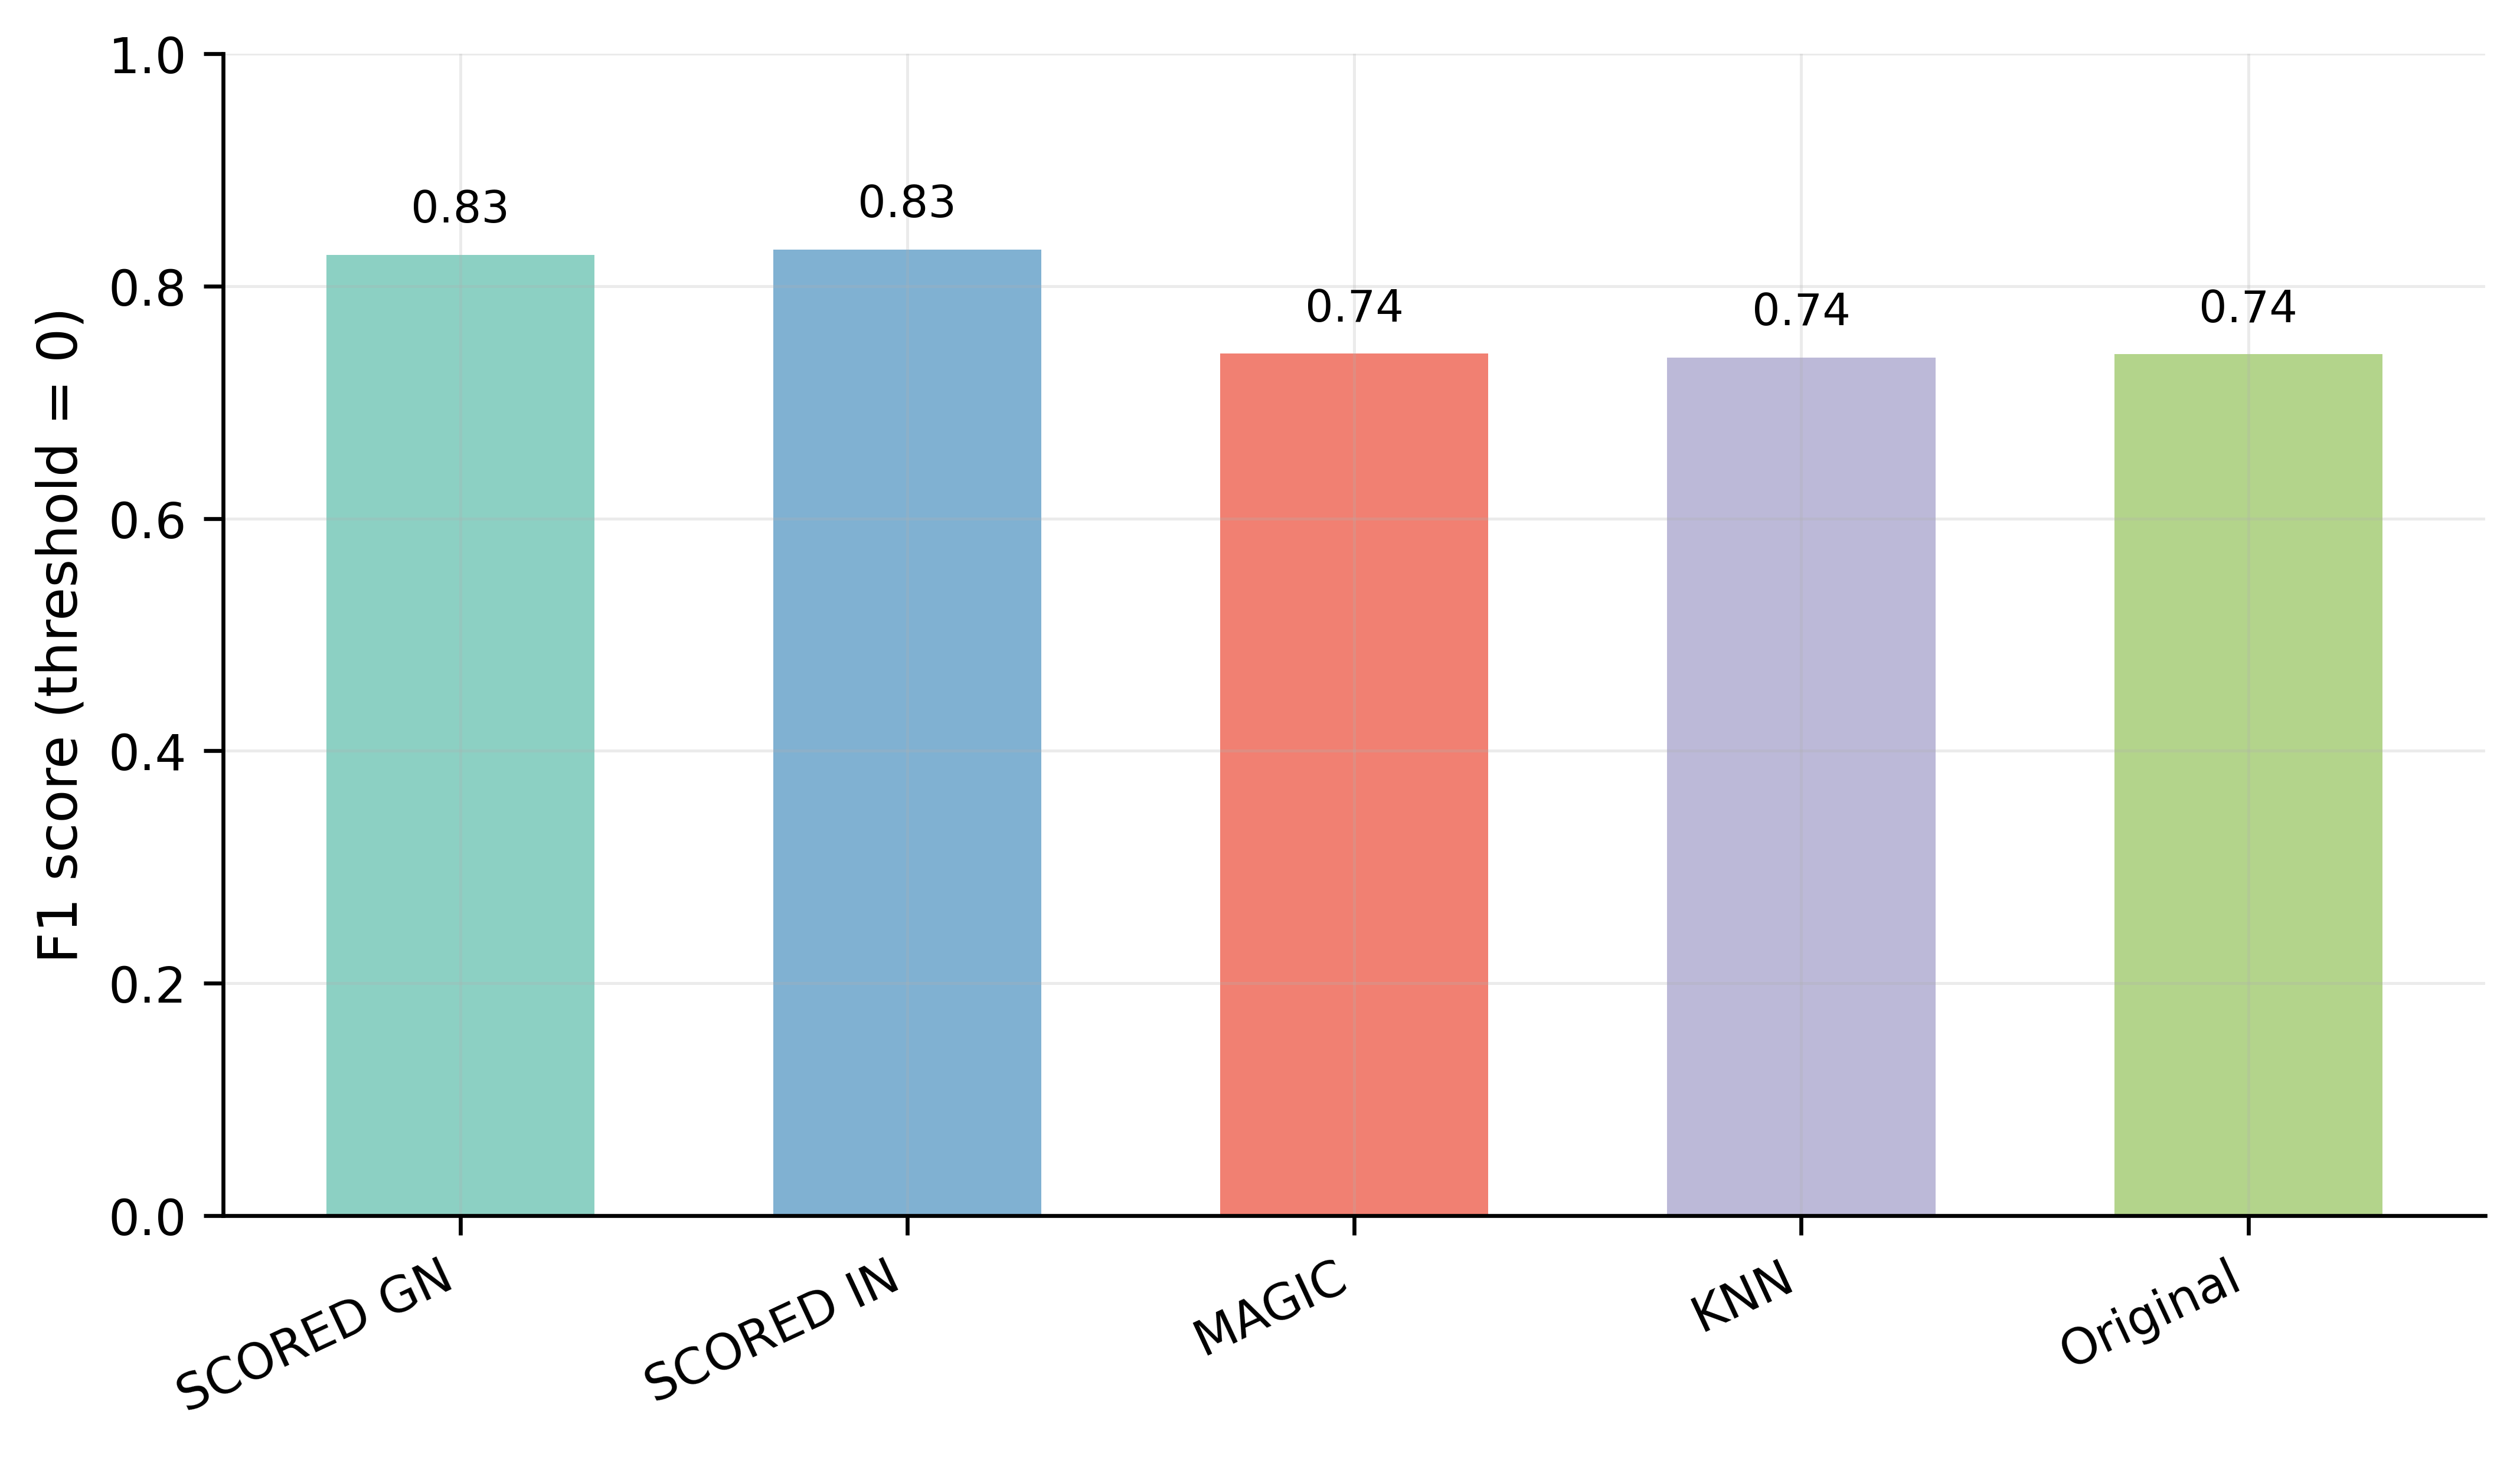

In [46]:
f_scores = {
    "SCORED GN": f3,
    "SCORED IN": f3_1,
    "MAGIC":     f6,
    "KNN":       f8,
    "Original":  f4,
}

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

x = np.arange(len(legend_order))
y = [f_scores[k] for k in legend_order]

bars = ax.bar(x, y, color=[palette[k] for k in legend_order], width=0.6)

ax.set_xticks(x)
ax.set_xticklabels(legend_order, rotation=25, ha="right")
ax.set_ylabel("F1 score (threshold = 0)")
ax.set_ylim(0, 1)
ax.grid(True, which="major", alpha=0.25, linewidth=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for rect, val in zip(bars, y):
    ax.text(rect.get_x() + rect.get_width()/2,
            rect.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9, clip_on=False)

plt.show()
